# rev_multiples_asig_rev_ia
Version reorganizada con helpers separados por naturaleza y bloque de ejecucion.


## Helpers y funciones necesarias
Estas celdas solo definen funciones/utilidades. No deben ejecutar rutinas ni mostrar graficos al correrlas.


### Configuracion e imports


In [13]:
import pandas as pd

import numpy as np

from pathlib import Path

import re

import time

from collections import defaultdict

import warnings

warnings.filterwarnings("ignore")

NOTEBOOK_FILENAME = "rev_multiples_asig_rev_ia.ipynb"
NOTEBOOK_DIR = Path(NOTEBOOK_FILENAME).resolve().parent if Path(NOTEBOOK_FILENAME).exists() else Path.cwd().resolve()
MODEL_VERSION = "v2_1"
MODELOS_DIRNAME = f"modelos_guardados_{MODEL_VERSION}"
MODELOS_BASE_DIR = NOTEBOOK_DIR / MODELOS_DIRNAME
LEGACY_MODELOS_BASE_DIR = NOTEBOOK_DIR / "modelos_guardados_v2"

historial = str(NOTEBOOK_DIR / "historia_todos.csv") #Este archvio es del 2019 al 2025-10

historial = str(NOTEBOOK_DIR / "historia_todos_2019_202610_2026-02-02181239.csv")

hitorial_parqet= str(NOTEBOOK_DIR / "historia_todos.parquet")

hitorial_parqet= str(NOTEBOOK_DIR / "historia_todos_2019_202610_dpto_asig_poblado.parquet")



### Funciones de limpieza y preprocesamiento


In [14]:
def eliminar_columnas_prof(df):
    """
    Elimina columnas específicas del dataframe.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame de entrada
        
    Retorna:
    --------
    pd.DataFrame
        DataFrame sin las columnas especificadas
    """
   
    columnas_a_eliminar = ['repitencia_prof_ref','profesor_codigo', 'num_semestres_profesor_asignatura']
  
    
    # Eliminar las columnas si existen en el dataframe
    cols_existentes = [col for col in columnas_a_eliminar if col in df.columns]
    df_resultado = df.drop(columns=cols_existentes, errors='ignore')
    
    print("[Resultados Funcion : INFO] ", f"[Eliminar Columnas Profesor] Eliminadas: {cols_existentes}")
    
    return df_resultado


def eliminar_columnas_prof_list(list):
    """
    Elimina columnas específicas del dataframe.
    
    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame de entrada
        
    Retorna:
    --------
    list
        Lista sin las columnas especificadas
    """
   
    columnas_a_eliminar = ['repitencia_prof_ref','profesor_codigo', 'num_semestres_profesor_asignatura']
  
    
    # Eliminar las columnas si existen en la lista
    cols_existentes = [col for col in columnas_a_eliminar if col in list]
    list_resultado = [col for col in list if col not in cols_existentes]
    
    print("[Resultados Funcion : INFO] ", f"[Eliminar Columnas Profesor] Eliminadas: {cols_existentes}")
    
    return list_resultado

def _reordenar_prereq_al_final(df):
    if not isinstance(df, pd.DataFrame):
        return df
    prereq_cols = [c for c in df.columns if isinstance(c, str) and c.lower().startswith('prereq_')]
    if not prereq_cols:
        return df
    other_cols = [c for c in df.columns if c not in prereq_cols]
    return df[other_cols + prereq_cols]

# Helper para preparar X numerico para modelos que no manejan categorias

def preparar_X_numerico(df, columnas_predictores):
    """
    Convierte columnas category/object a codigos numericos para modelos que no
    soportan categoricos nativamente (por ejemplo, RandomForest).
    """
    X = df[columnas_predictores].copy()
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    for c in cat_cols:
        X[c] = X[c].astype('category').cat.codes
    return X, cat_cols


def preparar_dataframe_para_modelado(df_asignatura, col_usar, var_objetivo, var_objetivo_clas):
    """
    Prepara el dataframe para modelado usando solo las columnas disponibles y
    garantizando la presencia de las variables objetivo cuando existan.
    """
    df_preparado = df_asignatura.copy()

    if var_objetivo_clas in df_preparado.columns:
        df_preparado[var_objetivo_clas] = df_preparado[var_objetivo_clas].astype(int)

    cols_present = [c for c in col_usar if c in df_preparado.columns]
    if var_objetivo in df_preparado.columns and var_objetivo not in cols_present:
        cols_present.append(var_objetivo)
    if var_objetivo_clas in df_preparado.columns and var_objetivo_clas not in cols_present:
        cols_present.append(var_objetivo_clas)

    faltantes = [c for c in col_usar if c not in df_preparado.columns]
    if faltantes:
        print("[Resultados Funcion : INFO] ", f'[Aviso] Algunas columnas de col_usar no existen y se omiten: {faltantes}')

    df_preparado = df_preparado[cols_present].copy()
    print("[Resultados Funcion : INFO] ", f'[Info] df_usar_filtrado reducido a {df_preparado.shape[1]} columnas y {len(df_preparado)} filas')

    col_usar_validas = [c for c in col_usar if c in df_preparado.columns]
    return df_preparado, col_usar_validas, faltantes

def anexar_columnas_por_indice(df_destino, df_fuente, columnas):
    columnas_presentes = [c for c in columnas if c in df_fuente.columns]
    for col in columnas_presentes:
        df_destino[col] = df_fuente[col].reindex(df_destino.index)
    return df_destino

def limitar_predicciones_nota(df, columnas_prediccion):
    for col in columnas_prediccion:
        if col in df.columns:
            df[col] = df[col].round(2)
            df[col] = df[col].apply(lambda x: -1 if pd.notna(x) and x < 0 else x)
            df[col] = df[col].apply(lambda x: 5 if pd.notna(x) and x > 5 else x)
    return df




## check asgianturas en carpeta

import os
import shutil

def check_asignaturas_en_carpeta(ruta_carpeta_procesados):
    """
    Devuelve los codigos de asignatura que tienen un archivo de modelo valido
    dentro de la carpeta indicada, ignorando artefactos auxiliares.
    """
    if not os.path.exists(ruta_carpeta_procesados):
        print("[Resultados Funcion : INFO] ", f"[Aviso] La carpeta '{ruta_carpeta_procesados}' no existe.")
        return []

    extensiones_validas = {'.json', '.joblib', '.cbm', '.model'}
    sufijos_auxiliares = ('_features', '_meta', '_metricas', '_salida')
    asignaturas = []

    for nombre in os.listdir(ruta_carpeta_procesados):
        ruta_archivo = os.path.join(ruta_carpeta_procesados, nombre)
        if not os.path.isfile(ruta_archivo):
            continue

        stem, ext = os.path.splitext(nombre)
        if ext.lower() not in extensiones_validas:
            continue
        if any(stem.endswith(sufijo) for sufijo in sufijos_auxiliares):
            continue

        asignaturas.append(stem)

    asignaturas = sorted(set(asignaturas))
    archivos_df = pd.DataFrame(asignaturas, columns=['asignatura'])
    print("[Resultados Funcion : INFO] ", f"[Info] Asignaturas detectadas en la carpeta de modelos: {ruta_carpeta_procesados}")
    if 'display' in globals():
        display(archivos_df)
    else:
        print(archivos_df)

    return asignaturas


def elegir_asignaturas(historial,cat_prereq , cant_asignaturas=5):
    
    df_historial = historial[ (historial["Observacion_Prerrequisito"] == cat_prereq)]

    df_filtrado = (
        df_historial
        .groupby("Cod materia curso")
        .size()
        .reset_index(name="num_registros")
        .sort_values("num_registros", ascending=False)
        .reset_index(drop=True)
    )

    lista_asignaturas=df_filtrado["Cod materia curso"].head(cant_asignaturas).tolist()    

    return lista_asignaturas

def elegir_asignaturas_rev_ya_creados(historial, cat_prereq, ruta_modelos, cant_asignaturas=5):

    if cat_prereq=="all":
        df_historial= historial[(historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (historial["Observacion_Prerrequisito"] == "No tiene pre requisito")]
    else:
        df_historial = historial[ (historial["Observacion_Prerrequisito"] == cat_prereq)]

    lista_mod_creados=check_asignaturas_en_carpeta(ruta_modelos)

    df_filtrado = (
        df_historial
        .groupby("Cod materia curso")
        .size()
        .reset_index(name="num_registros")
        .sort_values("num_registros", ascending=False)
        .reset_index(drop=True)
    )

    #print(lista_mod_creados)
    #lista_asignaturas=df_filtrado[df_filtrado["Cod materia curso"].isin(lista_mod_creados)].head(cant_asignaturas).tolist()    
    #lista_asignaturas=df_filtrado[df_filtrado["Cod materia curso"].isin(lista_mod_creados)]
    lista_asignaturas= df_filtrado[~(df_filtrado["Cod materia curso"].isin(lista_mod_creados))].head(cant_asignaturas)
    print("[Resultados Funcion : INFO] ", f"Lista de asignaturas seleccionadas: \n {lista_asignaturas}")
    lista_asignaturas = lista_asignaturas['Cod materia curso'].tolist() 

    return lista_asignaturas


def filtrar_asignaturas_por_matricula_minima(df_usar, asig_a_usar, matricula_minima=200):
    if matricula_minima is None:
        return df_usar, asig_a_usar

    conteo = (
        df_usar.groupby("Cod materia curso")
        .size()
        .reset_index(name="num_registros")
    )
    asignaturas_validas = conteo[conteo["num_registros"] >= matricula_minima]["Cod materia curso"].tolist()
    df_usar_filtrado = df_usar[df_usar["Cod materia curso"].isin(asignaturas_validas)].copy()
    lista_final = [a for a in asig_a_usar if a in set(asignaturas_validas)]

    print("[Resultados Funcion : INFO] ", f"[Asignaturas] Despues de filtro de matricula minima ({matricula_minima}), quedan {len(lista_final)} asignaturas.")
    return df_usar_filtrado, lista_final


## Crear DataFrame con los nombres de las asignaturas y sus códigos

def crear_df_asignaturas(df_historial: pd.DataFrame) -> pd.DataFrame:
    # Extraer las columnas relevantes
    df_asignaturas = df_historial[['Cod materia curso', 'Descripcion_Materia']].drop_duplicates()
    
    # Eliminar filas con valores nulos en 'Cod materia curso' o 'Descripcion_Materia'
    df_asignaturas = df_asignaturas.dropna(subset=['Cod materia curso', 'Descripcion_Materia'])
    
    # Eliminar espacios en blanco al inicio y al final de los nombres de las asignaturas
    df_asignaturas['Descripcion_Materia'] = df_asignaturas['Descripcion_Materia'].str.strip()
    
    # Eliminar duplicados basados en 'Cod materia curso', manteniendo la primera ocurrencia
    df_asignaturas = df_asignaturas.drop_duplicates(subset=['Cod materia curso'], keep='first')
    
    # Ordenar el DataFrame por 'Cod materia curso'
    df_asignaturas = df_asignaturas.sort_values(by='Cod materia curso').reset_index(drop=True)

    print("[Resultados Funcion : INFO] ", f" Creado DataFrame con las asignaturas unicas y sus nombres. Número de asignaturas únicas: {len(df_asignaturas)}")
    
    return df_asignaturas

## Calcular número de intentos por asignatura

def calcular_num_intentos(df: pd.DataFrame) -> pd.DataFrame:
    # Paso 1: quedarse con intentos únicos por periodo
    df_unique = df[['Pidm', 'Cod materia curso', 'Periodo']].drop_duplicates()

    # Paso 2: ordenar por periodo
    df_unique = df_unique.sort_values(['Pidm', 'Cod materia curso', 'Periodo'])

    # Paso 3: generar número de intento acumulado
    # rank(method='dense') da consecutivos (1,2,3..) por periodo distinto
    df_unique['num_intentos_asignatura'] = (
        df_unique.groupby(['Pidm', 'Cod materia curso']).cumcount() + 1
    )

    # Paso 4: hacer merge con el dataframe original
    df_result = df.merge(
        df_unique,
        on=['Pidm', 'Cod materia curso', 'Periodo'],
        how='left'
    )

    # --- Nuevo segmento: número de semestres que un profesor dictó la asignatura ---
    # Buscar el nombre de la columna de profesor disponible (compatibilidad)
    posibles_cols_prof = ['Prof_Codigo', '_ Matricula detalle para analisis.Prof_Codigo', 'profesor_codigo']
    profesor_col = next((c for c in posibles_cols_prof if c in df_result.columns), None)

    if profesor_col is not None:
        # Paso A: quedarse con combinaciones únicas profesor - asignatura - periodo
        df_prof_unique = df_result[[profesor_col, 'Cod materia curso', 'Periodo']].drop_duplicates()

        # Paso B: ordenar por profesor, asignatura y periodo
        df_prof_unique = df_prof_unique.sort_values([profesor_col, 'Cod materia curso', 'Periodo'])

        # Paso C: contar semestres únicos acumulados para cada profesor-asignatura
        df_prof_unique['num_semestres_profesor_asignatura'] = (
            df_prof_unique.groupby([profesor_col, 'Cod materia curso']).cumcount() + 1
        )

        # Paso D: merge con el dataframe resultante
        df_result = df_result.merge(
            df_prof_unique,
            on=[profesor_col, 'Cod materia curso', 'Periodo'],
            how='left'
        )
    else:
        # Si no existe columna de profesor, crear la columna con NaN y avisar (silencioso)
        df_result['num_semestres_profesor_asignatura'] = pd.NA

    return df_result

## Funciones de limpieza del DataFrame

def arreglar_comas_por_puntos(df: pd.DataFrame, cols_excluir: list) -> pd.DataFrame:
    """
    Reemplaza comas (,) por puntos (.) en todas las columnas tipo string,
    excepto en las columnas listadas en cols_excluir.
    Intenta convertir los valores resultantes a float.
    """
    for col in df.columns:
        if col not in cols_excluir and df[col].dtype == object:
            df[col] = df[col].str.replace(",", ".", regex=False)
            # Intentar conversión a float cuando sea posible
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass  # si no se puede convertir, se queda como string
            print("[Resultados Funcion : INFO] ", f"[Comas→Puntos] Procesada columna: {col}")
        elif col in cols_excluir:
            print("[Resultados Funcion : INFO] ", f"[Comas→Puntos] Columna excluida: {col}")
    return df


def imputar_valores(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores en columnas específicas."""
    # Columna repitencia → vacíos a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        despues = df[col_repitencia].isna().sum()
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_repitencia}': {antes} vacíos reemplazados por 0.0")

        
    # Columna repitencia profesor 1 año → vacíos a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia 1ano"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        despues = df[col_repitencia].isna().sum()
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_repitencia}': {antes} vacíos reemplazados por 0.0")

    # Columna Procedencia Categoria → reemplazar "6 No registra" por NaN
    col_procedencia = "_ Matricula detalle para analisis.Procedencia Categoria"
    if col_procedencia in df.columns:
        conteo = (df[col_procedencia] == "6 No registra").sum()
        df[col_procedencia] = df[col_procedencia].replace("6 No registra", np.nan)
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_procedencia}': {conteo} valores '6 No registra' reemplazados por NaN")

    # Columna Sexo → reemplazar -99 por NaN
    col_sexo = "_ Matricula detalle para analisis.Sexo"
    if col_sexo in df.columns:
        conteo = (df[col_sexo] == -99).sum()
        df[col_sexo] = df[col_sexo].replace(-99, np.nan)
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_sexo}': {conteo} valores '-99' reemplazados por NaN")

    # Columna Asistencia CREE t_1 → vacíos a 0.0
    col_asistencia_cree = "_ Matricula detalle para analisis.Asistencia CREE t_1"
    if col_asistencia_cree in df.columns:
        conteo = df[col_asistencia_cree].isna().sum()
        df[col_asistencia_cree] = df[col_asistencia_cree].fillna(0).astype(float)
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_asistencia_cree}': {conteo} vacíos reemplazados por 0.0")

    # Columna Calificacion_Final → vacíos a -1
    col_nota_final = "Calificacion_Final"
    if col_nota_final in df.columns:
        conteo = df[col_nota_final].isna().sum()
        df[col_nota_final] = df[col_nota_final].fillna(-1).astype(float)
        df[col_nota_final] = df[col_nota_final].apply(lambda x : -1 if x <0 else x )
        print("[Resultados Funcion : INFO] ", f"[Imputación] Columna '{col_nota_final}': {conteo} vacíos reemplazados por -1")

    print("[Resultados Funcion : INFO] ", "[Creacion] de columna categorica para retiros")
    col_nota_final_rubiel="_ Matricula detalle para analisis.Calif Final _ Retiros"
    col_retiro_cat="Retiro_Asignatura_Cat"
    #df[col_retiro_cat]= df[col_nota_final].apply(lambda x: 1 if x <0 else 0)
    df[col_retiro_cat]= df[col_nota_final_rubiel].apply(lambda x: 1 if x <0 else 0)

    # Añadir columna de numero de intentos asignatura
    df = calcular_num_intentos(df)
    print("[Resultados Funcion : INFO] ", f"[Imputación] Columna num_intentos_asignatura': usando funcion calcular_num_intentos")
    print("[Resultados Funcion : INFO] ", f"[Imputación] Columna num_semestres_profesor_asignatura': usando funcion calcular_num_intentos")

    return df


def eliminar_columnas_vacias(df: pd.DataFrame, columnas_eliminadas: list) -> pd.DataFrame:
    """Elimina columnas 100% vacías."""
    cols_vacias = df.columns[df.isna().all()].tolist()
    if cols_vacias:
        df = df.drop(columns=cols_vacias)
        columnas_eliminadas.extend(cols_vacias)
        print("[Resultados Funcion : INFO] ", f"[Columnas] Eliminadas columnas vacías: {cols_vacias}")
    else:
        print("[Resultados Funcion : INFO] ", "[Columnas] No se encontraron columnas totalmente vacías")
    return df


def eliminar_filas_por_columna(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Elimina filas con nulos en columnas con <20% vacíos."""
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print("[Resultados Funcion : INFO] ", f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print("[Resultados Funcion : INFO] ", f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print("[Resultados Funcion : INFO] ", f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total

def eliminar_filas_por_columna_ignorando_col_prereq(df: pd.DataFrame, col_add_ignorar=False) -> tuple[pd.DataFrame, int]:
    """
    Elimina filas con nulos en columnas con <20% vacíos,
    ignorando las columnas que siguen el patrón Prereq_i_[Atributo].
    """
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)
    cols_to_ignore = [
      "_ Matricula detalle para analisis.Puntaje_icfes_recalificado",
        "_ Matricula detalle para analisis.Dif anios icfes clase",
        "_ Matricula detalle para analisis.PCN_Puntaje_Ciencias_Naturales",
        "_ Matricula detalle para analisis.PIN_Puntaje_en_Ingles",
        "_ Matricula detalle para analisis.PLC_Puntaje_para_Lectura_Critica",
        "_ Matricula detalle para analisis.PMA_Puntaje_para_Matematicas",
        "_ Matricula detalle para analisis.PSC_Puntaje_Sociales_y_Ciudadanas",
        "_ Matricula detalle para analisis.Tipo_Colegio",
        "_ Matricula detalle para analisis.Tipo_Calendario",
        "_ Matricula detalle para analisis.pga inicial",
        "_ Matricula detalle para analisis.prom semestral t_1",
        "_ Matricula detalle para analisis.Asistencia CREE t_1"
    ]

    for col in df.columns:
        # Ignorar columnas de prerequisitos
        if col.startswith("Prereq_"):
            print("[Resultados Funcion : INFO] ", f"[Ignorado] Columna '{col}' pertenece a prerequisitos, no se revisa.")
            continue

        if col in cols_to_ignore and col_add_ignorar:
            print("[Resultados Funcion : INFO] ", f"[Ignorado] Columna '{col}' pertenece a columnas a ignorar, no se revisa.")
            continue

        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print("[Resultados Funcion : INFO] ", f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print("[Resultados Funcion : INFO] ", f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print("[Resultados Funcion : INFO] ", f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total



def limpiar_dataframe(df: pd.DataFrame, ignorar_col_adicionales = False, eliminar_filas_durante_limpieza = True) -> pd.DataFrame:
    """Función principal que limpia el dataframe según reglas definidas."""
    print("[Resultados Funcion : INFO] ", "=== Iniciando limpieza del DataFrame ===")

    # Imputación de valores
    df = imputar_valores(df)

    # Eliminar columnas vacías
    columnas_eliminadas = []
    df = eliminar_columnas_vacias(df, columnas_eliminadas)

    # Eliminar filas según condición por columnas
    # Esta limpieza global puede sesgar el resumen cuando se mezclan muchas asignaturas,
    # porque la regla de porcentaje de nulos se evalúa sobre todo el df agregado.
    # Por eso se permite desactivarla y dejar la eliminación por asignatura dentro del pipeline.
    if eliminar_filas_durante_limpieza:
        df, filas_eliminadas = eliminar_filas_por_columna_ignorando_col_prereq(df,ignorar_col_adicionales)
    else:
        filas_eliminadas = 0
        print("[Resultados Funcion : INFO] ", "[Filas] Limpieza global sin eliminación de filas. La depuración se hará por asignatura en el pipeline.")
    
    # Resumen final
    print("[Resultados Funcion : INFO] ", "\n=== Resumen limpieza ===")
    print("[Resultados Funcion : INFO] ", f"Filas eliminadas: {filas_eliminadas}")
    print("[Resultados Funcion : INFO] ", f"Columnas eliminadas: {columnas_eliminadas}")

    return df

def diagnosticar_registros_asignaturas(df_historial: pd.DataFrame, asig_a_usar: list, cols_to_excl: list, periodo_hasta=None):
    """Diagnóstico paso a paso para revisar pérdida de registros por asignatura."""
    pasos = []

    def _resumen(df_temp, paso):
        resumen = (
            df_temp.groupby(['Cod materia curso', 'Observacion_Prerrequisito'], dropna=False)
            .size()
            .reset_index(name='num_registros')
        )
        resumen['paso'] = paso
        return resumen

    df_base = df_historial[df_historial['Cod materia curso'].isin(asig_a_usar)].copy()
    pasos.append(_resumen(df_base, 'base_asig_a_usar'))

    df_prereq = df_base[
        (df_base['Observacion_Prerrequisito'] == 'Prerrequisito cumplido') |
        (df_base['Observacion_Prerrequisito'] == 'No tiene pre requisito')
    ].copy()
    pasos.append(_resumen(df_prereq, 'filtro_observacion_prerequisito'))

    df_comas = arreglar_comas_por_puntos(df_prereq.copy(), cols_to_excl)
    pasos.append(_resumen(df_comas, 'arreglar_comas_por_puntos'))

    df_limpio = limpiar_dataframe(df_comas.copy(), True, eliminar_filas_durante_limpieza=False)
    pasos.append(_resumen(df_limpio, 'limpiar_dataframe_sin_eliminar_filas'))

    if periodo_hasta is not None and 'Periodo' in df_limpio.columns:
        df_periodo = df_limpio[df_limpio['Periodo'] <= periodo_hasta].copy()
    else:
        df_periodo = df_limpio.copy()
    pasos.append(_resumen(df_periodo, 'filtro_periodo'))

    df_diag = pd.concat(pasos, axis=0, ignore_index=True)
    print("[Resultados Funcion : INFO] ", "[Diagnostico] Resumen de registros por asignatura generado.")
    return df_diag


#Renombrar Columnas

def renombrar_columnas(df: pd.DataFrame, tiene_prereq=True):
    """
    Renombra columnas largas por versiones cortas en snake_case.
    Devuelve:
      - DataFrame con columnas renombradas
      - Lista con columnas finales de análisis (col_usar renombradas)
      - String con el nombre de la variable objetivo renombrada
    """

    # Mapeo de nombres originales a nuevos
    mapping = {
        "_ Matricula detalle para analisis.repitencia profesor referencia 1ano": "repitencia_prof_ref",
        "Nombre_Programa": "programa",
        "_ Matricula detalle para analisis.Prof_Codigo": "profesor_codigo",
        "_ Matricula detalle para analisis.pga inicial": "pga_inicial",
        "_ Matricula detalle para analisis.prom semestral t_1": "promedio_sem_t1",
        "_ Matricula detalle para analisis.Sexo": "sexo",
        "_ Matricula detalle para analisis.Asistencia CREE t_1": "asistencia_cree_t1",
        "_ Matricula detalle para analisis.Procedencia Categoria": "procedencia_categoria",
        "_ Matricula detalle para analisis.Edad cursan asignatura": "edad_curso",
        "_ Matricula detalle para analisis.Calif Final _ Retiros": "resultado_final",
        "_ Matricula detalle para analisis.Puntaje estrato" : "estrato",
        "_ Matricula detalle para analisis.Puntaje_icfes_recalificado" : "puntaje_saber11",
        "_ Matricula detalle para analisis.Dif anios icfes clase" : "años_saber11_vs_clase",
        "_ Matricula detalle para analisis.PCN_Puntaje_Ciencias_Naturales" : "saber11_Ciencias_Naturales",
        "_ Matricula detalle para analisis.PIN_Puntaje_en_Ingles": "saber11_ingles",
        "_ Matricula detalle para analisis.PLC_Puntaje_para_Lectura_Critica": "saber11_lectura_critica",
        "_ Matricula detalle para analisis.PMA_Puntaje_para_Matematicas": "saber11_matematicas",
        "_ Matricula detalle para analisis.PSC_Puntaje_Sociales_y_Ciudadanas": "saber11_sociales",
        "_ Matricula detalle para analisis.Tipo_Colegio": "Tipo_colegio",
        "_ Matricula detalle para analisis.Tipo_Calendario": "Tipo_calendario"
    }

      # Renombrar columnas
    df = df.rename(columns=mapping)

    if tiene_prereq:
    # Construir lista final de columnas de análisis
        col_usar = [
            "repitencia_prof_ref",
            "programa",
            "profesor_codigo",
            "pga_inicial",
            "promedio_sem_t1",
            "sexo",
            "asistencia_cree_t1",
            "procedencia_categoria",
            "edad_curso",
            "num_intentos_asignatura",
            "num_semestres_profesor_asignatura",
            "estrato"
            #,"Tipo_colegio","Tipo_calendario"
        ]
    else:
        df,col_usar=check_columnas_no_prereq_pga(df)


    # Variable objetivo
    var_objetivo = "resultado_final"

    return df, col_usar, var_objetivo

def check_columnas_no_prereq_pga(df: pd.DataFrame):
    """
    Verifica si el DataFrame contiene columnas de prerequisitos.
    Retorna True si existen columnas que comienzan con 'Prereq_', False en caso contrario.
    """
    cols_usar=["repitencia_prof_ref",
            "programa",
            "profesor_codigo",
            "sexo",
            "asistencia_cree_t1",
            "procedencia_categoria",
            "edad_curso",
            "num_intentos_asignatura",
            "num_semestres_profesor_asignatura",
            "estrato", "Tipo_colegio", "Tipo_calendario"]
    
    cols_pga_solo=["pga_inicial"]
    
    cols_pga=["pga_inicial", "promedio_sem_t1"]

    cols_icfes_total = ["puntaje_saber11",
        "años_saber11_vs_clase",
        "saber11_Ciencias_Naturales",
        "saber11_ingles",
        "saber11_lectura_critica",
        "saber11_matematicas",
        "saber11_sociales",
    ]

    cols_icfes_sin_pj_general = [ "años_saber11_vs_clase",
        "saber11_Ciencias_Naturales",
        "saber11_ingles",
        "saber11_lectura_critica",
        "saber11_matematicas",
        "saber11_sociales"
    ]
    col_puntje_icfes ="puntaje_saber11"
    
    # Verificar existencia y completitud de la columna pga_inicial
    if "pga_inicial" not in df.columns:
        print("[Resultados Funcion : INFO] ", "No se encontró la columna 'pga_inicial'")
        return df, cols_usar

    total = len(df)
    if total == 0:
        print("[Resultados Funcion : INFO] ", "DataFrame vacío")
        return df, cols_usar

    nulos = df["pga_inicial"].isna().sum()
    porcentaje_nulos = nulos / total

    # Evaluar según umbrales
    if porcentaje_nulos > 0.80:
        cols_usar= cols_usar+cols_icfes_total
        print("[Resultados Funcion : INFO] ", "[❗] Mas del 80% de los datos no tiene PGA usando las variables del icfes y colegio")
    elif abs(porcentaje_nulos > 0.30) :  
        print("[Resultados Funcion : INFO] ", "[❗] Usar imputacion de ICFES imputar")
        # Intentar imputar pga_inicial usando '_ Matricula detalle para analisis.Puntaje_icfes_recalificado'
        if col_puntje_icfes not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Imputación] No se encuentra la columna '{col_puntje_icfes}', se usarán variables del ICFES por defecto")
            cols_usar = cols_usar + cols_icfes_total
        else:
            # convertir a numérico y trabajar sólo con los valores válidos para min-max
            icfes_ser = pd.to_numeric(df[col_puntje_icfes], errors='coerce')
            icfes_valid = icfes_ser.dropna()

            if icfes_valid.empty or icfes_valid.max() == icfes_valid.min():
                print("[Resultados Funcion : INFO] ", f"[Imputación] Imposible normalizar '{col_puntje_icfes}' (valores insuficientes o constantes). Se usan variables ICFES")
                cols_usar = cols_usar + cols_icfes_total
            else:
                min_v = icfes_valid.min()
                max_v = icfes_valid.max()
                # normalizar a [0,1] y escalar a [0,5]
                icfes_scaled = (icfes_ser - min_v) / (max_v - min_v) * 5

                # rellenar sólo donde pga_inicial es nulo
                n_nulos_before = df["pga_inicial"].isna().sum()
                mask_fill = df["pga_inicial"].isna() & icfes_scaled.notna()
                df.loc[mask_fill, "pga_inicial"] = icfes_scaled.loc[mask_fill].astype(float)
                df["pga_inicial"] = df["pga_inicial"].astype(float)

                n_filled = mask_fill.sum()
                print("[Resultados Funcion : INFO] ", f"[Imputación] Columna 'pga_inicial': {n_filled} valores imputados usando '{col_puntje_icfes}' (min={min_v}, max={max_v})")

                # Imputar 'promedio_sem_t1' de la misma forma usando icfes_scaled (si existe)
                if "promedio_sem_t1" in df.columns:
                    mask_fill_prom = df["promedio_sem_t1"].isna() & icfes_scaled.notna()
                    df.loc[mask_fill_prom, "promedio_sem_t1"] = icfes_scaled.loc[mask_fill_prom].astype(float)
                    # Asegurar tipo float
                    df["promedio_sem_t1"] = df["promedio_sem_t1"].astype(float)
                    n_filled_prom = mask_fill_prom.sum()
                    print("[Resultados Funcion : INFO] ", f"[Imputación] Columna 'promedio_sem_t1': {n_filled_prom} valores imputados usando '{col_puntje_icfes}' (mismo escalado)")
                else:
                    print("[Resultados Funcion : INFO] ", "[Imputación] Columna 'promedio_sem_t1' no encontrada, no se imputó")

                # ahora podemos usar las columnas pga
                cols_usar = cols_usar + cols_pga_solo + cols_icfes_sin_pj_general
    else:
        cols_usar = cols_usar + cols_pga
        print("[Resultados Funcion : INFO] ", "[❗] Usar PGA")
      

    return df, cols_usar


## Indentificar columnas de prerequisitos válidas

def columnas_prereq_validas(df: pd.DataFrame, umbral: float = 0.8) -> list:
    """
    Identifica las columnas de prerequisitos (Nota e Intentos) que cumplen con tener
    al menos un 80% de valores no nulos en la columna Nota.
    
    Parámetros:
        df: DataFrame de entrada
        umbral: proporción mínima de valores no nulos (default=0.8)
    
    Retorna:
        lista con las columnas Prereq_i_Nota y Prereq_i_Intentos que cumplen el criterio.
    """
    columnas_seleccionadas = []
    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")

        if col_intentos not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            columnas_seleccionadas.extend([col_nota, col_intentos])
            print("[Resultados Funcion : INFO] ", f"[Incluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos")
        else:
            print("[Resultados Funcion : INFO] ", f"[Excluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos (<{umbral:.0%})")

    print("[Resultados Funcion : INFO] ", "\nResumen final:")
    print("[Resultados Funcion : INFO] ", f"Columnas seleccionadas: {columnas_seleccionadas}")

    return columnas_seleccionadas

## Identificar columnas de prerequisitos válidas (versión 2) Con cambio de nombre!

import unicodedata

VALIDACION_IGNORE_TOKENS_DEFAULT = ('periodo', 'codigo', 'código', 'pidm', 'nrc', 'prereq')

def normalizar_texto_comparacion(valor):
    if pd.isna(valor):
        return None
    texto = str(valor).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    texto = re.sub(r'\s+', ' ', texto)
    return texto

def validar_columnas_dataframe(df, ignore_tokens=VALIDACION_IGNORE_TOKENS_DEFAULT, mostrar_detalle=True):
    from IPython.display import display

    def _ignorar_columna_validacion(nombre_columna):
        nombre_normalizado = str(nombre_columna).lower()
        return any(token in nombre_normalizado for token in ignore_tokens)

    columnas_validacion = [
        col for col in df.columns
        if not _ignorar_columna_validacion(col)
    ]

    columnas_numericas_validacion = [
        col for col in columnas_validacion
        if pd.api.types.is_numeric_dtype(df[col])
    ]

    columnas_no_numericas_validacion = [
        col for col in columnas_validacion
        if not pd.api.types.is_numeric_dtype(df[col])
    ]

    resumen = {
        'columnas_consideradas': columnas_validacion,
        'columnas_numericas': columnas_numericas_validacion,
        'columnas_no_numericas': columnas_no_numericas_validacion,
        'total_consideradas': len(columnas_validacion),
        'total_numericas': len(columnas_numericas_validacion),
        'total_no_numericas': len(columnas_no_numericas_validacion),
    }

    print(f"[Validacion] Columnas consideradas: {resumen['total_consideradas']}")
    print(f"[Validacion] Columnas numericas: {resumen['total_numericas']}")
    print(f"[Validacion] Columnas no numericas: {resumen['total_no_numericas']}")

    if not mostrar_detalle:
        return resumen

    for col in columnas_no_numericas_validacion:
        print("\n" + "=" * 120)
        print(f"[Validacion][No numerica] {col}")
        display(df[col].value_counts(dropna=False).rename('count').to_frame())

    for col in columnas_numericas_validacion:
        print("\n" + "=" * 120)
        print(f"[Validacion][Numerica] {col}")
        display(df[col].describe().to_frame(name=col))

    return resumen

def limpiar_datos_iniciales(df):
    df_limpio = df.copy()
    resumen = {}

    def _registrar(nombre, valor):
        resumen[nombre] = valor
        print("[Resultados Funcion : INFO] ", f"[Limpieza Inicial] {nombre}: {valor}")

    if 'Nombre_Division' in df_limpio.columns:
        col = 'Nombre_Division'
        mask = df_limpio[col].map(normalizar_texto_comparacion) == normalizar_texto_comparacion('Dirección de Docencia')
        cambios = int(mask.sum())
        if cambios:
            df_limpio.loc[mask, col] = 'IESE-Inst.de Estudios en Educ.'
        _registrar('Nombre_Division ajustado', cambios)

    if 'Descripcion_Materia' in df_limpio.columns:
        col = 'Descripcion_Materia'
        texto_norm = df_limpio[col].map(normalizar_texto_comparacion).fillna('')
        mask = texto_norm.str.contains(r'examen|practic|intercambi|seminario|ex\.?|turno|turnos|internado|refuerzo', regex=True)
        eliminados = int(mask.sum())
        if eliminados:
            df_limpio = df_limpio.loc[~mask].copy()
        _registrar('Registros eliminados por Descripcion_Materia', eliminados)

    if '_ Matricula detalle para analisis.DPTO Asignatura' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.DPTO Asignatura'
        departamentos_excluir = {
            'Esp. Der. de Sociedades',
            'Esp. Gcia. Finan. Serv. Salud',
            'Esp. Gcia. Proy. Ingeniería',
            'Esp. Neg. y Manejo. de Confli.',
            'Maestría en Matemáticas',
            'Esp. en Finanzas',
            'Centro para Excelencia Docente',
            'Esp.Gcia.Empresas Comerc.',
            'Dirección de Biblioteca',
            'Enf. Cuidado Crít Adulto',
            'Esp. En Responsab y Seguro',
            'Esp. Derecho Comercial',
            'Maestría en Epidemiología',
            'Maestría en Salud Pública',
            'Esp. en Derecho Penal',
            'Movilidad Nacional',
            'Sostenibilidad Ambiental',
            'Centro Recur Exito Estudiantil',
            'Semillero Investigadores-CIUN',
            'Intercambios Estudiantil',
            'Actividades Culturales',
            'Calidad y Proyectos Académicos',
            'Deportes',
            'Centro de Acompañamiento Estud',
            'Bienestar Universitario',
        }
        departamentos_excluir_norm = {normalizar_texto_comparacion(v) for v in departamentos_excluir}
        valores_norm = df_limpio[col].map(normalizar_texto_comparacion)
        mask = valores_norm.isna() | valores_norm.isin(departamentos_excluir_norm)
        eliminados = int(mask.sum())
        if eliminados:
            df_limpio = df_limpio.loc[~mask].copy()
        _registrar('Registros eliminados por DPTO Asignatura', eliminados)

    if 'Nombre_Programa' in df_limpio.columns:
        col = 'Nombre_Programa'
        valores_norm = df_limpio[col].map(normalizar_texto_comparacion)
        mask_lenguas = valores_norm.fillna('').str.contains('lenguas modernas y cultura') & valores_norm.fillna('').str.contains('barranquilla')
        cambios_lenguas = int(mask_lenguas.sum())
        if cambios_lenguas:
            df_limpio.loc[mask_lenguas, col] = 'Lenguas Modernas y Cultura - BARRANQUILLA'
        mask_lic = valores_norm == normalizar_texto_comparacion('Licenciatura en Educación Infantil - BARRANQUILLA')
        cambios_lic = int(mask_lic.sum())
        if cambios_lic:
            df_limpio.loc[mask_lic, col] = 'Licenciat. pedagogía infantil'
        _registrar('Nombre_Programa unificado Lenguas', cambios_lenguas)
        _registrar('Nombre_Programa ajustado Licenciatura', cambios_lic)

    if '_ Matricula detalle para analisis.Sexo' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.Sexo'
        mask = df_limpio[col].astype(str).str.strip().isin(['-99', 'N'])
        cambios = int(mask.sum())
        if cambios:
            df_limpio.loc[mask, col] = '-99'
        _registrar('Sexo homologado a -99', cambios)

    if '_ Matricula detalle para analisis.Tipo_Colegio' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.Tipo_Colegio'
        mask = df_limpio[col].astype(str).str.strip().eq('I')
        cambios = int(mask.sum())
        if cambios:
            df_limpio.loc[mask, col] = 'Institución Privada'
        _registrar('Tipo_Colegio ajustado', cambios)

    if '_ Matricula detalle para analisis.Tipo_Calendario' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.Tipo_Calendario'
        mask = df_limpio[col].astype(str).str.strip().eq('I')
        cambios = int(mask.sum())
        if cambios:
            df_limpio.loc[mask, col] = 'Calendario B'
        _registrar('Tipo_Calendario ajustado', cambios)

    if '_ Matricula detalle para analisis.Asistencia CREE t_1' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.Asistencia CREE t_1'
        cambios = int(df_limpio[col].isna().sum())
        if cambios:
            df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce').fillna(0)
        _registrar('Asistencia CREE t_1 nulos rellenados con 0', cambios)

    if 'cohorte' in df_limpio.columns:
        col = 'cohorte'
        cohorte_num = pd.to_numeric(df_limpio[col], errors='coerce')
        mask_cohorte_menos99 = cohorte_num.eq(-99) | df_limpio[col].astype(str).str.strip().eq('-99')
        ultimo_periodo = None
        if 'Periodo' in df_limpio.columns:
            periodo_num = pd.to_numeric(df_limpio['Periodo'], errors='coerce')
            if periodo_num.notna().any():
                ultimo_periodo = int(periodo_num.max())

        rellenados = 0
        if ultimo_periodo is not None and 'Pidm' in df_limpio.columns and mask_cohorte_menos99.any():
            periodo_orden = pd.to_numeric(df_limpio['Periodo'], errors='coerce')
            primer_periodo_por_pidm = periodo_orden.groupby(df_limpio['Pidm']).min()
            mask_primer_periodo_pidm = df_limpio['Pidm'].map(primer_periodo_por_pidm).eq(ultimo_periodo)
            mask_periodo_maximo = periodo_orden.eq(ultimo_periodo)
            mask_rellenar = mask_cohorte_menos99 & mask_primer_periodo_pidm & mask_periodo_maximo
            rellenados = int(mask_rellenar.sum())
            if rellenados:
                df_limpio.loc[mask_rellenar, col] = ultimo_periodo
                cohorte_num = pd.to_numeric(df_limpio[col], errors='coerce')
                mask_cohorte_menos99 = cohorte_num.eq(-99) | df_limpio[col].astype(str).str.strip().eq('-99')

        eliminados = int(mask_cohorte_menos99.sum())
        if eliminados:
            df_limpio = df_limpio.loc[~mask_cohorte_menos99].copy()
        _registrar('Ultimo periodo usado para cohorte', ultimo_periodo)
        _registrar('Registros cohorte -99 rellenados con ultimo periodo', rellenados)
        _registrar('Registros eliminados por cohorte -99', eliminados)

    if '_ Matricula detalle para analisis.Dif anios icfes clase' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.Dif anios icfes clase'
        serie_num = pd.to_numeric(df_limpio[col], errors='coerce')
        mask = serie_num < 0
        cambios = int(mask.sum())
        if cambios:
            df_limpio.loc[mask, col] = 0
        _registrar('Dif anios icfes clase negativos ajustados a 0', cambios)

    if '_ Matricula detalle para analisis.PLC_Puntaje_para_Lectura_Critica' in df_limpio.columns:
        col = '_ Matricula detalle para analisis.PLC_Puntaje_para_Lectura_Critica'
        serie_num = pd.to_numeric(df_limpio[col], errors='coerce')
        mask = serie_num > 100
        eliminados = int(mask.sum())
        if eliminados:
            df_limpio = df_limpio.loc[~mask].copy()
        _registrar('Registros eliminados por PLC > 100', eliminados)

    _registrar('Filas finales despues de limpieza', len(df_limpio))
    return df_limpio, resumen


def normalizar_nombre(nombre: str) -> str:
    """
    Convierte un nombre en snake_case sin acentos, dejando los números intactos.
    """
    # Eliminar acentos
    nombre = ''.join(
        c for c in unicodedata.normalize('NFD', nombre)
        if unicodedata.category(c) != 'Mn'
    )
    # Reemplazar espacios y caracteres raros por "_", pero dejar letras y números
    nombre = re.sub(r'[^a-zA-Z0-9]+', '_', nombre)
    # Pasar a minúsculas
    nombre = nombre.strip("_").lower()
    return nombre

def columnas_prereq_validas_ext(df: pd.DataFrame, nombres_asignaturas: pd.DataFrame, umbral: float = 0.8):
    """
    Identifica columnas de prerequisitos que cumplen con el umbral de no-nulos
    y crea nuevas columnas con el nombre de la asignatura.

    Parámetros:
        df: DataFrame de entrada (con columnas Prereq_i_Nota y Prereq_i_Codigo)
        nombres_asignaturas: DataFrame con columnas ["Cod materia curso", "Descripcion_Materia"]
        umbral: proporción mínima de valores no nulos en la columna Nota (default=0.8)

    Retorna:
        columnas_nuevas (list): Lista con los nombres de las nuevas columnas creadas
        df_modificado (pd.DataFrame): DataFrame con las columnas nuevas añadidas
    """
    columnas_nuevas = []
    df_modificado = df.copy()

    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")
        col_codigo = col_nota.replace("_Nota", "_Codigo")

        if col_intentos not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el par.")
            continue
        if col_codigo not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Aviso] No se encontró la columna de código para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            # Procesar cada fila: buscar nombre de la materia
            nuevas_columnas_temp = []
            for idx, codigo in df.loc[df[col_codigo].notna(), col_codigo].items():
                # Buscar en nombres_asignaturas
                nombre_match = nombres_asignaturas.loc[
                    nombres_asignaturas["Cod materia curso"] == codigo, 
                    "Descripcion_Materia"
                ]
                if not nombre_match.empty:
                    nombre_materia = nombre_match.values[0]
                else:
                    nombre_materia = codigo  # fallback

                # Normalizar nombre
                nombre_materia_norm = normalizar_nombre(str(nombre_materia))
                nueva_columna = f"Prereq_{nombre_materia_norm}_Nota"

                # Crear la columna si no existe
                if nueva_columna not in df_modificado.columns:
                    df_modificado[nueva_columna] = pd.NA

                # Asignar el valor de la nota, asegurando tipo float
                valor_nota = df.loc[idx, col_nota]
                try:
                    valor_nota_float = float(valor_nota)
                except (ValueError, TypeError):
                    valor_nota_float = pd.NA
                df_modificado.at[idx, nueva_columna] = valor_nota_float

                # Forzar tipo float en la columna creada (puede tener <NA>)
                df_modificado[nueva_columna] = pd.to_numeric(df_modificado[nueva_columna], errors='coerce')

                nuevas_columnas_temp.append(nueva_columna)

                # Añadir columna de numero de intentos asociados
                nueva_columna_intentos = f"Prereq_{nombre_materia_norm}_Intentos"
                if nueva_columna_intentos not in df_modificado.columns:
                    df_modificado[nueva_columna_intentos] = pd.NA

                valor_intentos = df.loc[idx, col_intentos]
                try:
                    valor_intentos_float = float(valor_intentos)
                except (ValueError, TypeError):
                    valor_intentos_float = pd.NA
                df_modificado.at[idx, nueva_columna_intentos] = valor_intentos_float

                # Forzar tipo int en la columna de intentos (puede tener <NA>)
                df_modificado[nueva_columna_intentos] = pd.to_numeric(df_modificado[nueva_columna_intentos], errors='coerce')
                
                nuevas_columnas_temp.append(nueva_columna_intentos)

            # Agregar solo las columnas únicas de esta ronda
            columnas_nuevas.extend(list(set(nuevas_columnas_temp)))

            print("[Resultados Funcion : INFO] ", f"[Incluido] {col_nota} y {col_intentos} → {proporcion:.2%} válidos → nuevas columnas creadas.")
        else:
            print("[Resultados Funcion : INFO] ", f"[Excluido] {col_nota} y {col_intentos} → {proporcion:.2%} válidos (<{umbral:.0%})")

    print("[Resultados Funcion : INFO] ", "\nResumen final:")
    print("[Resultados Funcion : INFO] ", f"Columnas nuevas seleccionadas: {columnas_nuevas}")

    return columnas_nuevas, df_modificado



##La diferencia entre esta funcion y la atenrior es que esta tiene en cuenta que pueden venir diferentes asiganturas en las opciones de prerwequisito
import pandas as pd

def columnas_prereq_validas_ext_dif_prereq(
    df: pd.DataFrame,
    nombres_asignaturas: pd.DataFrame,
    umbral: float = 0.8,            # umbral sobre Prereq_i_Nota (columna fuente)
    umbral_pareja: float = 0.90     # umbral por par de columnas creadas (nota+intentos)
):
    """
    Identifica columnas de prerequisitos que cumplen con el umbral de no-nulos
    y crea nuevas columnas por cada CÓDIGO distinto, con el nombre de la asignatura
    (o el código si no hay match). Cada código genera un par:
        Prereq_<nombre_norm>_Nota
        Prereq_<nombre_norm>_Intentos

    Reglas adicionales:
      - Si para un código hay múltiples descripciones en 'nombres_asignaturas', se toma la primera.
      - Tras crear el par, si su completitud relativa es < umbral_pareja, se eliminan ambas columnas
        y no se reportan en la salida.

    Parámetros:
        df: DataFrame de entrada con columnas Prereq_i_Nota, Prereq_i_Codigo, Prereq_i_Intentos
        nombres_asignaturas: DataFrame con ["Cod materia curso", "Descripcion_Materia"]
        umbral: proporción mínima de valores no nulos en la columna fuente Prereq_i_Nota (default=0.8)
        umbral_pareja: proporción mínima (>=0.90) del par nuevo respecto a no-nulos de Prereq_i_Nota

    Retorna:
        columnas_nuevas (list): nombres de columnas finalmente creadas (y que superaron el umbral_pareja)
        df_modificado (pd.DataFrame): DataFrame con las columnas nuevas añadidas
    """
    columnas_nuevas = []
    df_modificado = df.copy()

    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")
        col_codigo = col_nota.replace("_Nota", "_Codigo")

        if col_intentos not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el trío.")
            continue
        if col_codigo not in df.columns:
            print("[Resultados Funcion : INFO] ", f"[Aviso] No se encontró la columna de código para {col_nota}, se omite el trío.")
            continue

        total = len(df_modificado)
        no_nulos_fuente = df_modificado[col_nota].notna().sum()
        proporcion_fuente = (no_nulos_fuente / total) if total > 0 else 0.0

        if proporcion_fuente < umbral:
            print("[Resultados Funcion : INFO] ", f"[Excluido] {col_nota} (y su par {col_intentos}) → {proporcion_fuente:.2%} válidos (<{umbral:.0%})")
            continue

        # --- Paso 1: identificar códigos distintos en este prereq_i ---
        codigos_validos = df_modificado.loc[df_modificado[col_codigo].notna(), col_codigo].unique().tolist()

        # Guardar columnas creadas en esta ronda para posible limpieza por umbral_pareja
        columnas_creadas_ronda = []  # lista de pares (nota_col, intentos_col)

        # --- Paso 2: crear/llenar columnas por CÓDIGO ---
        for codigo in codigos_validos:
            # Buscar nombre (tomar primera coincidencia) o usar el propio código
            match = nombres_asignaturas.loc[
                nombres_asignaturas["Cod materia curso"] == codigo,
                "Descripcion_Materia"
            ]
            if not match.empty:
                nombre_materia = match.values[0]
            else:
                nombre_materia = codigo  # fallback

            # Normalizar nombre
            nombre_materia_norm = normalizar_nombre(str(nombre_materia))

            nueva_col_nota = f"Prereq_{nombre_materia_norm}_Nota"
            nueva_col_int = f"Prereq_{nombre_materia_norm}_Intentos"

            # Crear columnas si no existen
            if nueva_col_nota not in df_modificado.columns:
                df_modificado[nueva_col_nota] = pd.NA
            if nueva_col_int not in df_modificado.columns:
                df_modificado[nueva_col_int] = pd.NA

            # Filas donde este código aplica en este prereq
            mask_codigo = df_modificado[col_codigo] == codigo

            # Asignar valores sólo en las filas donde corresponde el código
            # Nota
            valores_nota = pd.to_numeric(df_modificado.loc[mask_codigo, col_nota], errors="coerce")
            df_modificado.loc[mask_codigo, nueva_col_nota] = valores_nota

            # Intentos
            valores_intentos = pd.to_numeric(df_modificado.loc[mask_codigo, col_intentos], errors="coerce")
            df_modificado.loc[mask_codigo, nueva_col_int] = valores_intentos

            # Forzar tipo numérico (permitiendo NaN)
            df_modificado[nueva_col_nota] = pd.to_numeric(df_modificado[nueva_col_nota], errors="coerce")
            df_modificado[nueva_col_int] = pd.to_numeric(df_modificado[nueva_col_int], errors="coerce")

            columnas_creadas_ronda.append((nueva_col_nota, nueva_col_int))

        # --- Paso 3: filtrar por completitud relativa (umbral_pareja) y limpiar pares que no cumplan ---
        # Denominador: no_nulos_fuente (Prerreq_i_Nota) – filas donde hubo dato en la fuente de este prereq
        if no_nulos_fuente == 0:
            # Nada que evaluar en esta ronda, pasar
            continue

        for nueva_col_nota, nueva_col_int in columnas_creadas_ronda:
            n_no_nulos_par = df_modificado[nueva_col_nota].notna().sum()
            completitud_relativa = n_no_nulos_par / no_nulos_fuente

            if completitud_relativa >= umbral_pareja:
                # Mantener y reportar
                columnas_nuevas.extend([nueva_col_nota, nueva_col_int])
                print("[Resultados Funcion : INFO] ", f"[Incluido] {nueva_col_nota} / {nueva_col_int} → "
                      f"{completitud_relativa:.2%} de {col_nota} (>= {umbral_pareja:.0%})")
            else:
                # Eliminar ambas columnas (par) y NO reportarlas
                df_modificado.drop(columns=[nueva_col_nota, nueva_col_int], inplace=True, errors="ignore")
                print("[Resultados Funcion : INFO] ", f"[Excluido] {nueva_col_nota} / {nueva_col_int} → "
                      f"{completitud_relativa:.2%} de {col_nota} (< {umbral_pareja:.0%})")

    # Dejar únicas y mantener orden de aparición
    seen = set()
    columnas_nuevas = [c for c in columnas_nuevas if not (c in seen or seen.add(c))]

    print("[Resultados Funcion : INFO] ", "\nResumen final:")
    print("[Resultados Funcion : INFO] ", f"Columnas nuevas seleccionadas ({len(columnas_nuevas)}): {columnas_nuevas}")

    return columnas_nuevas, df_modificado




#Cambiar a category

def cambiar_a_category(df, cols):
    # Convierte columnas a category si existen

    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
        else:
            print("[Resultados Funcion : INFO] ", f"Columna no encontrada: {c}")

    # Verificar tipos resultantes
    print("[Resultados Funcion : INFO] ", df[ [c for c in cols if c in df.columns] ].dtypes)  

    return df



### Funciones de modelado XGBoost y evaluacion


In [15]:
from sklearn.metrics import make_scorer

import numpy as np

from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

def tuning_hiperparametros_grid(model,x_train, y_train, cv=5):

    param_grid = {
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.05, 0.1, 0.2],
        "n_estimators": [ 500, 800],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [ 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "reg_alpha": [ 0.1, 1],
        "reg_lambda": [ 2, 3]
    }

    # Crear scorer compatible con sklearn
    recall_scorer = make_scorer(recall_margen, greater_is_better=True)

    # Configurar búsqueda con validación cruzada de 5 folds
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        #scoring="neg_root_mean_squared_error", # queremos optimizar RMSE
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        n_jobs=-1
    )

    # Ejecutar búsqueda
    grid_search.fit(x_train, y_train)

     # Resultados
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = -grid_search.best_score_  # volver a RMSE positivo

    print("[Resultados Funcion : INFO] ", "Mejores parámetros encontrados:", grid_search.best_params_)
    print("[Resultados Funcion : INFO] ", "Mejor score (RMSE):", -grid_search.best_score_)

    return best_model, best_params, best_score

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import make_scorer, mean_squared_error 

def optimizar_xgboost_random(modelo, X_train, y_train, n_iter=50, cv=5, random_state=42):
    """
    Optimiza un modelo XGBoost con RandomizedSearchCV para minimizar RMSE.

    Parámetros:
        modelo: instancia de XGBRegressor (sin entrenar).
        X_train (pd.DataFrame o np.array): variables de entrenamiento.
        y_train (pd.Series o np.array): variable objetivo.
        n_iter (int): número de combinaciones aleatorias a probar.
        cv (int): número de folds para validación cruzada.
        random_state (int): semilla de aleatoriedad.

    Retorna:
        best_model: modelo entrenado con los mejores hiperparámetros.
        best_params: diccionario con mejores parámetros.
        best_score: mejor score en validación cruzada (RMSE).
    """

    # Definir espacio de búsqueda
    param_dist = {
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.05, 0.1, 0.2],
        "n_estimators": [ 500, 800],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [ 3, 5, 7],
        "gamma": [0, 0.1, 0.3, 0.5],
        "reg_alpha": [ 0.1, 1],
        "reg_lambda": [ 2, 3]
    }

    # Definir scorer para RMSE (negativo porque sklearn maximiza por defecto)
    rmse_scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)))

    # Crear scorer compatible con sklearn
    recall_scorer = make_scorer(recall_margen, greater_is_better=True)


    # Configurar búsqueda
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        #scoring=rmse_scorer,
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # Ejecutar búsqueda
    random_search.fit(X_train, y_train)

    # Resultados
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = -random_search.best_score_  # volver a RMSE positivo

    print("[Resultados Funcion : INFO] ", "Mejores parámetros encontrados:", best_params)
    print("[Resultados Funcion : INFO] ", "Mejor score (RMSE):", best_score)

    return best_model, best_params, best_score

import numpy as np

import pandas as pd

from sklearn.model_selection import KFold, GroupKFold, cross_val_score, cross_val_predict

from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, f1_score, recall_score, precision_score

from catboost import CatBoostRegressor, CatBoostClassifier

def recall_margen(y_true, y_pred, margen=0.3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    aciertos = np.abs(y_true - y_pred) <= margen
    TP = aciertos.sum()
    FN = (~aciertos).sum()
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def make_recall_margen_scorer(margen=0.3):
    # greater_is_better=True porque queremos MAXIMIZAR la proporción de aciertos
    return make_scorer(lambda yt, yp: recall_margen(yt, yp, margen=margen), greater_is_better=True)

from sklearn.base import clone as clone_estimator

def _take(X, idx):
    # Funciona con DataFrame/Series/ndarray
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]


def evaluar_con_cv(modelo, X, y, n_splits=5, random_state=42, margen=0.3, groups=None, shuffle=True):
    """
    Ejecuta validación cruzada sobre un modelo ya configurado (hiperparámetros fijos)
    y devuelve métricas promedio + predicciones OOF.

    Parámetros:
        modelo: estimador sklearn ya configurado (ej. XGBRegressor con tus mejores params)
        X (pd.DataFrame o np.ndarray)
        y (pd.Series o np.ndarray)
        n_splits (int): número de folds
        random_state (int): semilla para reproducibilidad (si shuffle=True)
        margen (float): margen para recall_margen
        groups (array-like | None): grupos para GroupKFold (ej. Pidm o NRC si quieres evitar fuga)
        shuffle (bool): mezclar antes de partir (solo KFold)

    Retorna:
        resultados (dict) con medias y std de RMSE, MAE, R2, recall_margen
        y_oof (np.ndarray) predicciones out-of-fold
    """
    # Definir CV
    if groups is not None:
        cv = GroupKFold(n_splits=n_splits)
    else:
        cv = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    # Scorers sklearn (nota: RMSE/MAE vienen como negativos y luego los invertimos)
    rmse_scores = cross_val_score(
        modelo, X, y, cv=cv if groups is None else cv.split(X, y, groups),
        scoring="neg_root_mean_squared_error"
    )
    mae_scores = cross_val_score(
        modelo, X, y, cv=cv if groups is None else cv.split(X, y, groups),
        scoring="neg_mean_absolute_error"
    )
    r2_scores = cross_val_score(
        modelo, X, y, cv=cv if groups is None else cv.split(X, y, groups),
        scoring="r2"
    )
    recall_scores = cross_val_score(
        modelo, X, y, cv=cv if groups is None else cv.split(X, y, groups),
        scoring=make_recall_margen_scorer(margen=margen)
    )

    # Predicciones OOF para análisis adicional
    if groups is not None:
        # cross_val_predict no acepta directamente GroupKFold con groups; hacemos manual
        y_oof = np.empty_like(np.asarray(y), dtype=float)
        for tr_idx, te_idx in cv.split(X, y, groups):
            m = clone_estimator(modelo)
            m.fit(_take(X, tr_idx), _take(y, tr_idx))
            y_oof[te_idx] = m.predict(_take(X, te_idx))
    else:
        y_oof = cross_val_predict(modelo, X, y, cv=cv, method="predict")

    # Métricas sobre OOF (útil para tener una sola “foto” global)
    rmse_oof = np.sqrt(mean_squared_error(y, y_oof))
    mae_oof = mean_absolute_error(y, y_oof)
    r2_oof = r2_score(y, y_oof)
    recall_oof = recall_margen(y, y_oof, margen=margen)

    resultados = {
        "RMSE_mean": -rmse_scores.mean(),  # invertimos signo
        "RMSE_std":  rmse_scores.std(),
        "MAE_mean":  -mae_scores.mean(),
        "MAE_std":   mae_scores.std(),
        "R^2_mean":   r2_scores.mean(),
        "R^2_std":    r2_scores.std(),
        f"Recall±{margen}_mean": recall_scores.mean(),
        f"Recall±{margen}_std":  recall_scores.std(),
        "RMSE_OOF":  rmse_oof,
        "MAE_OOF":   mae_oof,
        "R^2_OOF":    r2_oof,
        f"Recall±{margen}_OOF": recall_oof
    }

    # Print compacto
    tabla = pd.DataFrame({
        "mean": [resultados["RMSE_mean"], resultados["MAE_mean"], resultados["R^2_mean"], resultados[f"Recall±{margen}_mean"]],
        "std":  [resultados["RMSE_std"],  resultados["MAE_std"],  resultados["R^2_std"],  resultados[f"Recall±{margen}_std"]]
    }, index=["RMSE (CV)", "MAE (CV)", "R^2 (CV)", f"Recall±{margen} (CV)"])
   
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Validación Cruzada (promedio ± std):\n")
    print("[Resultados Funcion : INFO] ", tabla)
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Métricas sobre predicciones OOF:\n")
    print("[Resultados Funcion : INFO] ", pd.Series({
        "RMSE_OOF": resultados["RMSE_OOF"],
        "MAE_OOF": resultados["MAE_OOF"],
        "R^2_OOF": resultados["R^2_OOF"],
        f"Recall±{margen}_OOF": resultados[f"Recall±{margen}_OOF"]
    }))

    tabla['metric'] = tabla.index
    
    return resultados, y_oof, tabla

def evaluar_con_cv_regresion_fast(modelo, X, y, n_splits=5, random_state=42, margen=0.3, groups=None, shuffle=True):
    """
    Validacion cruzada en una sola pasada. Calcula todas las metricas (RMSE, MAE, R2,
    recall_margen) en cada fold, reduciendo de ~25 a 5 entrenamientos por modelo.

    Parametros y retorno identicos a evaluar_con_cv.
    """
    if groups is not None:
        cv = GroupKFold(n_splits=n_splits)
        cv_iter = cv.split(X, y, groups)
    else:
        cv = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        cv_iter = cv.split(X, y)

    rmse_folds, mae_folds, r2_folds, recall_folds = [], [], [], []
    y_oof = np.empty(len(y), dtype=float)

    for tr_idx, te_idx in cv_iter:
        m = clone_estimator(modelo)
        m.fit(_take(X, tr_idx), _take(y, tr_idx))
        y_pred = m.predict(_take(X, te_idx))
        y_true = _take(y, te_idx)

        rmse_folds.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae_folds.append(mean_absolute_error(y_true, y_pred))
        r2_folds.append(r2_score(y_true, y_pred))
        recall_folds.append(recall_margen(y_true, y_pred, margen=margen))

        y_oof[te_idx] = y_pred

    rmse_folds = np.array(rmse_folds)
    mae_folds = np.array(mae_folds)
    r2_folds = np.array(r2_folds)
    recall_folds = np.array(recall_folds)

    rmse_oof = np.sqrt(mean_squared_error(y, y_oof))
    mae_oof = mean_absolute_error(y, y_oof)
    r2_oof = r2_score(y, y_oof)
    recall_oof = recall_margen(y, y_oof, margen=margen)

    resultados = {
        "RMSE_mean": float(rmse_folds.mean()),
        "RMSE_std":  float(rmse_folds.std()),
        "MAE_mean":  float(mae_folds.mean()),
        "MAE_std":   float(mae_folds.std()),
        "R^2_mean":  float(r2_folds.mean()),
        "R^2_std":   float(r2_folds.std()),
        f"Recall±{margen}_mean": float(recall_folds.mean()),
        f"Recall±{margen}_std":  float(recall_folds.std()),
        "RMSE_OOF":  rmse_oof,
        "MAE_OOF":   mae_oof,
        "R^2_OOF":   r2_oof,
        f"Recall±{margen}_OOF": recall_oof
    }

    tabla = pd.DataFrame({
        "mean": [resultados["RMSE_mean"], resultados["MAE_mean"], resultados["R^2_mean"], resultados[f"Recall±{margen}_mean"]],
        "std":  [resultados["RMSE_std"],  resultados["MAE_std"],  resultados["R^2_std"],  resultados[f"Recall±{margen}_std"]]
    }, index=["RMSE (CV)", "MAE (CV)", "R^2 (CV)", f"Recall±{margen} (CV)"])

    print("[Resultados Funcion : INFO] ", "\n[Resumen] Validacion Cruzada Fast (promedio ± std):\n")
    print("[Resultados Funcion : INFO] ", tabla)
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Metricas sobre predicciones OOF:\n")
    print("[Resultados Funcion : INFO] ", pd.Series({
        "RMSE_OOF": resultados["RMSE_OOF"],
        "MAE_OOF": resultados["MAE_OOF"],
        "R^2_OOF": resultados["R^2_OOF"],
        f"Recall±{margen}_OOF": resultados[f"Recall±{margen}_OOF"]
    }))

    tabla['metric'] = tabla.index

    return resultados, y_oof, tabla


def evaluar_con_cv_clasificacion(modelo, X, y, n_splits=5, random_state=42, margen=0.3, groups=None, shuffle=True):
    """
    Ejecuta validación cruzada sobre un modelo de CLASIFICACIÓN ya configurado
    (hiperparámetros fijos) y devuelve métricas promedio + predicciones OOF.

    IMPORTANTE:
        - y debe ser binaria (0 / 1).
        - El modelo debe implementar predict_proba (para ROC AUC).

    Parámetros:
        modelo: estimador sklearn ya configurado (ej. XGBClassifier con tus mejores params)
        X (pd.DataFrame o np.ndarray)
        y (pd.Series o np.ndarray)
        n_splits (int): número de folds
        random_state (int): semilla para reproducibilidad (si shuffle=True)
        margen (float): UMBRAL de probabilidad para decidir clase positiva (default 0.0).
                        p >= margen -> 1 (retiro), p < margen -> 0 (no retiro)
        groups (array-like | None): grupos para GroupKFold (ej. Pidm o NRC si quieres evitar fuga)
        shuffle (bool): mezclar antes de partir (solo KFold)

    Retorna:
        resultados (dict) con medias y std de ROC_AUC, Accuracy, F1, Recall, Precision
        y_oof (np.ndarray) predicciones OOF de probabilidad para la clase positiva
        tabla (pd.DataFrame) resumen de métricas (mean/std)
    """
    # Definir CV
    if groups is not None:
        cv = GroupKFold(n_splits=n_splits)
        cv_iter = cv.split(X, y, groups)
    else:
        cv = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        cv_iter = cv

    # === MÉTRICAS EN CV ===
    # AUC usa probabilidades; F1/Recall/Precision usan labels por defecto
    roc_auc_scores = cross_val_score(
        modelo, X, y,
        cv=cv_iter,
        scoring="roc_auc"
    )
    accuracy_scores = cross_val_score(
        modelo, X, y,
        cv=cv_iter,
        scoring="accuracy"
    )
    f1_scores = cross_val_score(
        modelo, X, y,
        cv=cv_iter,
        scoring="f1"
    )
    recall_scores = cross_val_score(
        modelo, X, y,
        cv=cv_iter,
        scoring="recall"
    )
    precision_scores = cross_val_score(
        modelo, X, y,
        cv=cv_iter,
        scoring="precision"
    )

    # === PREDICCIONES OOF ===
    # Para poder calcular métricas globales (AUC, F1, etc.)
    if groups is not None:
        # cross_val_predict no maneja bien GroupKFold + groups, lo hacemos manual
        y_oof_proba = np.empty(len(y), dtype=float)
        for tr_idx, te_idx in cv.split(X, y, groups):
            m = clone_estimator(modelo)  # asumiendo que tienes esta función definida igual que antes
            m.fit(_take(X, tr_idx), _take(y, tr_idx))
            proba = m.predict_proba(_take(X, te_idx))[:, 1]
            y_oof_proba[te_idx] = proba
    else:
        # cross_val_predict con probabilidades
        proba_oof = cross_val_predict(
            modelo, X, y,
            cv=cv,
            method="predict_proba"
        )
        y_oof_proba = proba_oof[:, 1]

    # Labels OOF usando el umbral (= margen)
    y_oof_labels = (y_oof_proba >= margen).astype(int)

    # === MÉTRICAS SOBRE OOF ===
    roc_auc_oof = roc_auc_score(y, y_oof_proba)
    accuracy_oof = (np.asarray(y) == y_oof_labels).mean()
    f1_oof = f1_score(y, y_oof_labels)
    recall_oof = recall_score(y, y_oof_labels)
    precision_oof = precision_score(y, y_oof_labels)

    resultados = {
        "ROC_AUC_mean": roc_auc_scores.mean(),
        "ROC_AUC_std":  roc_auc_scores.std(),
        "Accuracy_mean": accuracy_scores.mean(),
        "Accuracy_std":  accuracy_scores.std(),
        "F1_mean":      f1_scores.mean(),
        "F1_std":       f1_scores.std(),
        "Recall_mean":  recall_scores.mean(),
        "Recall_std":   recall_scores.std(),
        "Precision_mean": precision_scores.mean(),
        "Precision_std":  precision_scores.std(),
        "ROC_AUC_OOF":  roc_auc_oof,
        "Accuracy_OOF": accuracy_oof,
        "F1_OOF":       f1_oof,
        "Recall_OOF":   recall_oof,
        "Precision_OOF": precision_oof,
        "umbral_prob":  margen
    }

    # Tabla resumen CV
    tabla = pd.DataFrame({
        "mean": [
            resultados["ROC_AUC_mean"],
            resultados["Accuracy_mean"],
            resultados["F1_mean"],
            resultados["Recall_mean"],
            resultados["Precision_mean"],
        ],
        "std": [
            resultados["ROC_AUC_std"],
            resultados["Accuracy_std"],
            resultados["F1_std"],
            resultados["Recall_std"],
            resultados["Precision_std"],
        ]
    }, index=["ROC_AUC (CV)", "Accuracy (CV)", "F1 (CV)", "Recall (CV)", "Precision (CV)"])

    print("[Resultados Funcion : INFO] ", "\n[Resumen] Validación Cruzada (promedio ± std):\n")
    print("[Resultados Funcion : INFO] ", tabla)
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Métricas sobre predicciones OOF (umbral = {:.2f}):\n".format(margen))
    print("[Resultados Funcion : INFO] ", pd.Series({
        "ROC_AUC_OOF": resultados["ROC_AUC_OOF"],
        "Accuracy_OOF": resultados["Accuracy_OOF"],
        "F1_OOF": resultados["F1_OOF"],
        "Recall_OOF": resultados["Recall_OOF"],
        "Precision_OOF": resultados["Precision_OOF"],
        "Umbral_prob": resultados["umbral_prob"]
    }))

    tabla["metric"] = tabla.index

    # y_oof de salida = probabilidades de clase positiva
    return resultados, y_oof_proba, tabla

def evaluar_con_cv_clasificacion_fast(modelo, X, y, n_splits=5, random_state=42, margen=0.3, groups=None, shuffle=True):
    """
    Validacion cruzada en una sola pasada para clasificacion. Calcula todas las metricas
    (ROC_AUC, Accuracy, F1, Recall, Precision) en cada fold, reduciendo de ~30 a 5
    entrenamientos por modelo.

    Parametros y retorno identicos a evaluar_con_cv_clasificacion.
    """
    if groups is not None:
        cv = GroupKFold(n_splits=n_splits)
        cv_iter = cv.split(X, y, groups)
    else:
        cv = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        cv_iter = cv.split(X, y)

    roc_auc_folds, accuracy_folds, f1_folds, recall_folds, precision_folds = [], [], [], [], []
    y_oof_proba = np.empty(len(y), dtype=float)

    for tr_idx, te_idx in cv_iter:
        m = clone_estimator(modelo)
        m.fit(_take(X, tr_idx), _take(y, tr_idx))
        y_proba = m.predict_proba(_take(X, te_idx))[:, 1]
        y_labels = (y_proba >= margen).astype(int)
        y_true = _take(y, te_idx)

        roc_auc_folds.append(roc_auc_score(y_true, y_proba))
        accuracy_folds.append((np.asarray(y_true) == y_labels).mean())
        f1_folds.append(f1_score(y_true, y_labels, zero_division=0))
        recall_folds.append(recall_score(y_true, y_labels, zero_division=0))
        precision_folds.append(precision_score(y_true, y_labels, zero_division=0))

        y_oof_proba[te_idx] = y_proba

    roc_auc_folds = np.array(roc_auc_folds)
    accuracy_folds = np.array(accuracy_folds)
    f1_folds = np.array(f1_folds)
    recall_folds = np.array(recall_folds)
    precision_folds = np.array(precision_folds)

    y_oof_labels = (y_oof_proba >= margen).astype(int)

    roc_auc_oof = roc_auc_score(y, y_oof_proba)
    accuracy_oof = (np.asarray(y) == y_oof_labels).mean()
    f1_oof = f1_score(y, y_oof_labels, zero_division=0)
    recall_oof = recall_score(y, y_oof_labels, zero_division=0)
    precision_oof = precision_score(y, y_oof_labels, zero_division=0)

    resultados = {
        "ROC_AUC_mean": float(roc_auc_folds.mean()),
        "ROC_AUC_std":  float(roc_auc_folds.std()),
        "Accuracy_mean": float(accuracy_folds.mean()),
        "Accuracy_std":  float(accuracy_folds.std()),
        "F1_mean":      float(f1_folds.mean()),
        "F1_std":       float(f1_folds.std()),
        "Recall_mean":  float(recall_folds.mean()),
        "Recall_std":   float(recall_folds.std()),
        "Precision_mean": float(precision_folds.mean()),
        "Precision_std":  float(precision_folds.std()),
        "ROC_AUC_OOF":  roc_auc_oof,
        "Accuracy_OOF": accuracy_oof,
        "F1_OOF":       f1_oof,
        "Recall_OOF":   recall_oof,
        "Precision_OOF": precision_oof,
        "umbral_prob":  margen
    }

    tabla = pd.DataFrame({
        "mean": [
            resultados["ROC_AUC_mean"],
            resultados["Accuracy_mean"],
            resultados["F1_mean"],
            resultados["Recall_mean"],
            resultados["Precision_mean"],
        ],
        "std": [
            resultados["ROC_AUC_std"],
            resultados["Accuracy_std"],
            resultados["F1_std"],
            resultados["Recall_std"],
            resultados["Precision_std"],
        ]
    }, index=["ROC_AUC (CV)", "Accuracy (CV)", "F1 (CV)", "Recall (CV)", "Precision (CV)"])

    print("[Resultados Funcion : INFO] ", "\n[Resumen] Validacion Cruzada Fast (promedio ± std):\n")
    print("[Resultados Funcion : INFO] ", tabla)
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Metricas sobre predicciones OOF (umbral = {:.2f}):\n".format(margen))
    print("[Resultados Funcion : INFO] ", pd.Series({
        "ROC_AUC_OOF": resultados["ROC_AUC_OOF"],
        "Accuracy_OOF": resultados["Accuracy_OOF"],
        "F1_OOF": resultados["F1_OOF"],
        "Recall_OOF": resultados["Recall_OOF"],
        "Precision_OOF": resultados["Precision_OOF"],
        "Umbral_prob": resultados["umbral_prob"]
    }))

    tabla["metric"] = tabla.index

    return resultados, y_oof_proba, tabla


from catboost import Pool

def evaluar_catboost_cv_regresion(modelo, X, y, cat_features, n_splits=5, random_state=42, shuffle=True):
    """
    CV manual para CatBoost con cat_features. Retorna dict y tabla de mtricas.
    """
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np
    import pandas as pd

    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
    rmses, maes, r2s = [], [], []

    for tr_idx, te_idx in kf.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        params = modelo.get_params()
        params['random_seed'] = params.get('random_seed', random_state)
        params['allow_writing_files'] = False
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr, cat_features=cat_features)
        y_pred = m.predict(X_te)

        rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
        maes.append(mean_absolute_error(y_te, y_pred))
        r2s.append(r2_score(y_te, y_pred))

    resultados = {
        "RMSE_mean": float(np.mean(rmses)),
        "RMSE_std": float(np.std(rmses)),
        "MAE_mean": float(np.mean(maes)),
        "MAE_std": float(np.std(maes)),
        "R^2_mean": float(np.mean(r2s)),
        "R^2_std": float(np.std(r2s)),
    }

    tabla = pd.DataFrame({
        "mean": [resultados["RMSE_mean"], resultados["MAE_mean"], resultados["R^2_mean"]],
        "std":  [resultados["RMSE_std"],  resultados["MAE_std"],  resultados["R^2_std"]],
    }, index=["RMSE (CV)", "MAE (CV)", "R^2 (CV)"])

    print("[Resultados Funcion : INFO] ", " Validacin Cruzada CatBoost (promedio  std):")
    print("[Resultados Funcion : INFO] ", tabla)

    tabla["metric"] = tabla.index
    return resultados, tabla

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
import shap 

def interpretar_xgboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables más importantes

    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): número de variables más importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)
    
    df_shap = pd.DataFrame(
    shap_values.values, 
    columns=X.columns
    )

    #print(df_shap.head())

    importancia_media = df_shap.abs().mean().sort_values(ascending=False)
    #print(importancia_media)

    # --- 1. Summary plot ---
    print("[Resultados Funcion : INFO] ", "[Grafica] Generando summary plot global...")
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores)

    # --- 2. Dependence plots ---
    print("[Resultados Funcion : INFO] ", f"\n[Grafica] Generando dependence plots para las {top_n} variables más importantes...\n")
    
    # Obtener importancia (gain) desde XGBoost
    importancia_gain = modelo.get_booster().get_score(importance_type="gain")
    importancia_df = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    importancia_df = importancia_df.sort_values("Gain", ascending=False).head(top_n)

    for feature in importancia_df.index:
        print("[Resultados Funcion : INFO] ", f"[Grafica] Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check  # índice del estudiante en X_test
    print("[Resultados Funcion : INFO] ", f"[Grafica] Explicación de la predicción para el estudiante {i}")
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False) 
    plt.show()

def interpretar_xgboost_shap_doc(modelo, X, columnas_predictores,doc, top_n=5, id_check=0, ):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables más importantes

    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): número de variables más importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)
    
    df_shap = pd.DataFrame(
    shap_values.values, 
    columns=X.columns
    )

    #print(df_shap.head())

    importancia_media = df_shap.abs().mean().sort_values(ascending=False)
    #print(importancia_media)

    # --- 1. Summary plot ---
    print("[Resultados Funcion : INFO] ", "[Grafica] Generando summary plot global...")
    plt.figure()
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores, show=False)
    doc.flush_consola()
    doc.insertar_figura_actual()

    
    i = id_check  # índice del estudiante en X_test
    print("[Resultados Funcion : INFO] ", f"[Grafica] Explicación de la predicción para el estudiante {i}")
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False)
    plt.show()
    doc.flush_consola()
    doc.insertar_figura_actual()

def imprimir_valores_shap(modelo, X, columnas_predictores,id_check=0,print_estud=True):
    """
    Imprime los valores SHAP para una instancia específica.
    
    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        id_check (int): índice de la instancia a revisar
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    df_shap = pd.DataFrame(
    shap_values.values, 
    columns=X.columns
    )

    importancia_media = df_shap.abs().mean().sort_values(ascending=False)
    print("[Resultados Funcion : INFO] ", importancia_media)

    if print_estud:
        i = id_check  # índice del estudiante en X_test
        print("[Resultados Funcion : INFO] ", f"[Detalle] Valores SHAP para el estudiante {i}:\n")
        for feature, value in zip(X.columns, shap_values.values[i]):
            print("[Resultados Funcion : INFO] ", f"{feature}: {value:.4f}")
            
    return df_shap

def gen_xboost_waterfall_plot(modelo, X, id_check=0):
    
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    i = id_check  # índice del estudiante en X_test
    print("[Resultados Funcion : INFO] ", f"[Grafica] Explicación de la predicción para el estudiante {i}")
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False)
    plt.show()

def escribir_interpretaciones_shap(modelo,X,df,top_n=10,col_general="interpretacion_general",col_registro="interpretacion_registro"):
    """
    Parámetros
    - modelo: modelo árbol (p.ej. XGBRegressor) ya entrenado.
    - X: pd.DataFrame de predictores que se explican (mismas filas que df, idealmente mismo índice).
    - df: pd.DataFrame donde se escribirán las interpretaciones (se modificará in-place).
    - top_n: cuántas variables listar en cada interpretación.
    - col_general: nombre de la columna de interpretación general.
    - col_registro: nombre de la columna de interpretación por registro.

    Retorna
    - df: el mismo DataFrame de entrada, con columnas añadidas.
    - importancia_media: pd.Series con importancia promedio (|SHAP|) por variable, ordenada desc.
    """

    import numpy as np
    import pandas as pd
    import shap

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # 1) Calcular SHAP
    explainer = shap.TreeExplainer(modelo)
    shap_exp = explainer(X)  # shap.Explanation
    vals = shap_exp.values   # (n_muestras, n_features) para regresión

    # 2) Importancia media (|SHAP|)
    importancia_media = pd.Series(np.abs(vals).mean(axis=0), index=X.columns).sort_values(ascending=False)
    #importancia_media = pd.Series(vals.mean(axis=0), index=X.columns).sort_values(ascending=False)

    # 3) Interpretación general (idéntica para todas las filas)
    top_imp = importancia_media.head(top_n)
    interp_general = "Variables con mayor impacto promedio (|SHAP|): " + ", ".join(
        f"{feat} ({imp:.3f})" for feat, imp in top_imp.items()
    )
    general_series = pd.Series(interp_general, index=X.index)
    print("[Resultados Funcion : INFO] ", "[Interpretacion] Interpretación general generada.")
    print("[Resultados Funcion : INFO] ", interp_general)

    # 4) Interpretación por registro
    def resumen_por_fila(row_vals):
        contrib = pd.Series(row_vals, index=X.columns)
        pos = contrib[contrib > 0].abs().sort_values(ascending=False).head(top_n)
        neg = contrib[contrib < 0].abs().sort_values(ascending=False).head(top_n)
        pos_str = ", ".join(f"{f} (+{contrib[f]:.3f})" for f in pos.index) if len(pos) else "—"
        neg_str = ", ".join(f"{f} ({contrib[f]:.3f})" for f in neg.index) if len(neg) else "—"
        return f"A favor: {pos_str} | En contra: {neg_str}"

    print("[Resultados Funcion : INFO] ", "[Interpretacion] Generando resumen por fila...")
    interp_registro_series = pd.Series(
        (resumen_por_fila(vals[i, :]) for i in range(vals.shape[0])),
        index=X.index
    )
    print("[Resultados Funcion : INFO] ", "[Interpretacion] Resumen por fila finalizado.")

    # 5) Escribir en df (alineando por índice cuando sea posible)
    if len(df) == len(X) and df.index.equals(X.index):
        df[col_general] = general_series
        df[col_registro] = interp_registro_series
    else:
        # Intento por índice
        try:
            df.loc[X.index, col_general] = general_series
            df.loc[X.index, col_registro] = interp_registro_series
        except Exception:
            # Fallback si solo coinciden longitudes
            if len(df) == len(X):
                df[col_general] = general_series.values
                df[col_registro] = interp_registro_series.values
            else:
                raise ValueError("No coinciden longitudes/índices de df y X; no se pueden escribir interpretaciones de forma segura.")

    return df, importancia_media

def escribir_interpretaciones_shap_xgb(modelo, X, df, top_n=10, col_general="interpretacion_general", col_registro="interpretacion_registro"):
    return escribir_interpretaciones_shap(modelo, X, df, top_n=top_n, col_general=col_general, col_registro=col_registro)


def entrenar_xgboost_regresion(df, columna_objetivo, columnas_predictores, tuning=True, cols_to_category=None, generar_interpretacion=True, top_n_interpretacion=10):
    """
    Entrena un modelo XGBoost de regresión sobre un dataframe y (opcionalmente) 
    ajusta hiperparámetros con RandomizedSearchCV.

    Parámetros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada
        tuning (bool): Si True, aplica optimización con RandomizedSearchCV

    Retorna:
        modelo (XGBRegressor): Modelo entrenado (mejorado si tuning=True)
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
        X_train, X_test, y_train, y_test
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Definir modelo base
    #modelo = XGBRegressor(
    #    objective="reg:squarederror",
    #    #objective="reg:absoluteerror",
    #    enable_categorical=True,
    #    random_state=42
    #)

    # Definir modelo con hiperparámetros iniciales
    modelo = XGBRegressor(
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42,
    subsample=0.8,
    reg_lambda=3,
    reg_alpha=0.01,
    n_estimators=800,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.8
    )


    # --- Ajuste de hiperparámetros ---
    if tuning:
        print("[Resultados Funcion : INFO] ", "\n[Busqueda] Iniciando optimización de hiperparámetros con RandomSearchCV...\n")
        modelo, best_params, best_score = optimizar_xgboost_random(
            modelo, X_train, y_train, n_iter=300, cv=5)
        #modelo, best_params, best_score = tuning_hiperparametros_grid(
        #    modelo, X_train, y_train, cv=5)
        print("[Resultados Funcion : INFO] ", "\n[OK] Optimización finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parámetros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validación cruzada (RMSE):", best_score)

    # Entrenar con mejores parámetros
    modelo.fit(X_train, y_train)

    # Predicciones en test
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R^2": r2}

    # Mostrar métricas como tabla
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Métricas de evaluación del modelo en test:\n")
    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Valores"]).T)


    # Mostrar métricas como tabla usando cv
    resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_regresion_fast(modelo, X, y, n_splits=5, margen=0.3)

    # Agregar columna de predicciones al df completo
    df_resultados = df.copy()
    df_resultados["Prediccion_XGB"] = modelo.predict(X)

    if generar_interpretacion:
        cols_interpret_xgb = ["interpretacion_general_xgb", "interpretacion_registro_xgb"]
        df_resultados = cambiar_a_category(df_resultados, list(cols_to_category or []) + cols_interpret_xgb)
        print("[Resultados Funcion : INFO] ", "[Aviso] Insertando interpretaciones SHAP (XGB) en el dataframe de predicciones:")
        df_resultados, importancia_media_xgb = escribir_interpretaciones_shap_xgb(
            modelo,
            df_resultados[columnas_predictores],
            df_resultados,
            top_n=top_n_interpretacion,
            col_general=cols_interpret_xgb[0],
            col_registro=cols_interpret_xgb[1],
        )
        interpretar_xgboost_shap(modelo, X_test, columnas_predictores, top_n=1, id_check=0)


    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

from xgboost import plot_tree

import matplotlib.pyplot as plt

from xgboost import plot_importance

def mostrar_arbol(modelo, num_tree=0, ancho=40, alto=20, orientacion="LR"):
    """
    Muestra el árbol de decisión generado por XGBoost.

    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        num_tree (int): Índice del árbol a graficar
        ancho (int): Ancho de la figura
        alto (int): Alto de la figura
        orientacion (str): Dirección del árbol ("LR"=izq-der, "TB"=arriba-abajo)
    """
    plt.figure(figsize=(ancho, alto))
    plot_tree(modelo, num_trees=num_tree, rankdir=orientacion)
    plt.show()

def mostrar_importancia_gain(modelo, top_n=20):
    """
    Muestra la importancia de las variables en el modelo.
    
    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        top_n (int): Número de variables a mostrar
    """
    plt.figure(figsize=(10,6))
    plot_importance(modelo, importance_type="gain", max_num_features=top_n, height=0.5)
    plt.title("Importancia de variables (gain)")
    plt.show()

def reporte_importancia(modelo):
    """
    Genera un reporte tabulado de importancia de variables
    con métricas: gain, weight y cover.
    """
    booster = modelo.get_booster()

    # Obtener cada métrica como diccionario
    importancia_gain = booster.get_score(importance_type="gain")
    importancia_weight = booster.get_score(importance_type="weight")
    importancia_cover = booster.get_score(importance_type="cover")

    # Convertir a DataFrame
    df_gain = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    df_weight = pd.DataFrame.from_dict(importancia_weight, orient="index", columns=["Weight"])
    df_cover = pd.DataFrame.from_dict(importancia_cover, orient="index", columns=["Cover"])

    # Unir todo
    df_importancia = df_gain.join(df_weight).join(df_cover)

    # Ordenar por Gain
    df_importancia = df_importancia.sort_values("Gain", ascending=False)

    print("[Resultados Funcion : INFO] ", "\n[Resumen] Reporte de Importancia de Variables (XGBoost)\n")
    print("[Resultados Funcion : INFO] ", df_importancia)

    return df_importancia

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import matplotlib.pyplot as plt

def matriz_confusion_personalizada(df, columna_objetivo, columna_prediccion, margen_error=0.2, graficar=True):
    """
    Construye una matriz de confusión personalizada basada en un margen de error.

    Parámetros:
        df (pd.DataFrame): DataFrame con columna real y predicción
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicción correcta
        graficar (bool): Si True, muestra la matriz de confusión en gráfico

    Retorna:
        matriz (np.ndarray): Matriz de confusión
        df_resultados (pd.DataFrame): DataFrame con columna de éxito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

    # Redondear predicciones a 2 decimales
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].round(2)

    # Convertir cualquier valor < 0 en -1
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].apply(lambda x: -1 if x < 0 else x)

    # Crear etiqueta de éxito: 1 si la diferencia es <= margen_error
    df_resultados["Exito"] = np.where(
        abs(df_resultados[columna_objetivo] - df_resultados[columna_prediccion]) <= margen_error, 
        1, 
        0
    )

    # Etiqueta real: siempre 1 (correcto) porque evaluamos predicciones
    # Aquí podemos definir "ground truth" como si el valor real fuera siempre válido
    # entonces comparamos con éxito/fallo de predicción
    y_true = np.ones(len(df_resultados))   # todos deberían ser "correctos"
    y_pred = df_resultados["Exito"]

    # Calcular matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print("[Resultados Funcion : INFO] ", classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Éxito", "Fallo"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de Confusión Personalizada")
        plt.show()

    return matriz, df_resultados

def matriz_confusion_normal(df, columna_objetivo, columna_prediccion,  graficar=True):
    """
    Construye una matriz de confusión personalizada basada en un margen de error.

    Parámetros:
        df (pd.DataFrame): DataFrame con columna real y predicción
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicción correcta
        graficar (bool): Si True, muestra la matriz de confusión en gráfico

    Retorna:
        matriz (np.ndarray): Matriz de confusión
        df_resultados (pd.DataFrame): DataFrame con columna de éxito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

  

    # entonces comparamos con éxito/fallo de predicción
    y_true = df_resultados[columna_objetivo] 
    y_pred = df_resultados[columna_prediccion]

    # Calcular matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print("[Resultados Funcion : INFO] ", classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Retiro", "No Retiro"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de Confusión")
        plt.show()

    return matriz, df_resultados

import numpy as np

from sklearn.metrics import recall_score, precision_score

def buscar_mejor_threshold(modelo, X_val, y_val, min_precision=None):
    """
    Busca el threshold que maximiza el recall de la clase 1.
    Si min_precision no es None, solo considera thresholds que 
    tengan al menos esa precisión.
    """
    y_proba = modelo.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.01, 0.99, 99)
    
    mejor_th = 0.5
    mejor_recall = -1
    mejor_prec = None

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rec = recall_score(y_val, y_pred, pos_label=1)
        prec = precision_score(y_val, y_pred, pos_label=1, zero_division=0)

        if min_precision is not None and prec < min_precision:
            continue

        if rec > mejor_recall:
            mejor_recall = rec
            mejor_th = th
            mejor_prec = prec

    return mejor_th, mejor_recall, mejor_prec

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from scipy.stats import uniform, randint

from sklearn.metrics import make_scorer, recall_score

import numpy as np

def optimizar_xgboost_clasif_random(
    modelo,
    X_train,
    y_train,
    n_iter=300,
    cv=5
):
    """
    Realiza una búsqueda aleatoria (RandomizedSearchCV) de hiperparámetros
    para un modelo XGBClassifier de clasificación binaria.

    Parámetros
    ----------
    modelo : XGBClassifier
        Modelo base ya configurado (por ejemplo con objective, scale_pos_weight, etc.).
    X_train : pd.DataFrame o np.ndarray
        Matriz de características de entrenamiento.
    y_train : pd.Series o np.ndarray
        Vector objetivo de entrenamiento.
    n_iter : int, opcional (default=300)
        Número de combinaciones aleatorias a evaluar.
    cv : int, opcional (default=5)
        Número de folds para la validación cruzada (StratifiedKFold).

    Returns
    -------
    best_model : XGBClassifier
        Modelo XGBoost ya entrenado con los mejores hiperparámetros (refit sobre todo X_train).
    best_params : dict
        Diccionario con los mejores hiperparámetros encontrados.
    best_score : float
        Mejor puntuación media de validación (por defecto, ROC-AUC).
    """

    # Calcular desbalance entre las clases para incuir en la busqueda de parametros
    ratio_neg_to_pos = (y_train == 0).sum() / (y_train == 1).sum()

    # Definir el espacio de búsqueda de hiperparámetros
    # (puedes ajustar estos rangos según tu problema / tiempos de cómputo)
    param_distributions = {
        "n_estimators": randint(100, 900),          # número de árboles
        "learning_rate": uniform(0.01, 0.29),       # ~[0.01, 0.30]
        "max_depth": randint(3, 10),                # profundidad de los árboles
        "min_child_weight": randint(1, 8),
        "subsample": uniform(0.5, 0.5),             # ~[0.5, 1.0]
        "colsample_bytree": uniform(0.5, 0.5),      # ~[0.5, 1.0]
        "gamma": uniform(0.0, 5.0),
        "reg_lambda": uniform(0.0, 5.0),            # L2
        "reg_alpha": uniform(0.0, 5.0),              # L1
        "scale_pos_weight": [                     # probar varias intensidades para controlar el desbalanace
        ratio_neg_to_pos * 0.5,
        ratio_neg_to_pos * 1.0,
        ratio_neg_to_pos * 2.0,
        ratio_neg_to_pos * 3.0
        ]
    }

    # Defnir scoring para la busqueda de hiperparámetros
    scorer_recall_pos = make_scorer(
    recall_score,
    pos_label=1,        # MUY importante! Para definir que la clase de interes es la 1
    average='binary'
    )

    # Definir el esquema de validación cruzada estratificada
    cv_strategy = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=42
    )

    # Configurar la búsqueda aleatoria
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_distributions,
        n_iter=n_iter,
        #scoring="roc_auc",           # métrica objetivo: ROC-AUC (puedes cambiarla si quieres)
        #scoring="recall", 
        scoring=scorer_recall_pos,
        n_jobs=-1,                   # usar todos los núcleos disponibles
        cv=cv_strategy,
        verbose=1,
        refit=True,                  # reentrena el mejor modelo con todos los datos
        random_state=42
    )

    # Ejecutar la búsqueda
    random_search.fit(X_train, y_train)

    # Extraer resultados
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = random_search.best_score_

    return best_model, best_params, best_score

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

from pprint import pprint

def entrenar_xgboost_classif(df, columna_objetivo, columnas_predictores, tuning=False, cambiar_threshold=False):
    """
    Entrena un modelo XGBoost de clasificacion sobre un dataframe y (opcionalmente) 
    ajusta hiperparámetros con RandomizedSearchCV.

    Parámetros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada
        tuning (bool): Si True, aplica optimización con RandomizedSearchCV

    Retorna:
        modelo (XGBClassifier): Modelo entrenado (mejorado si tuning=True)
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
        X_train, X_test, y_train, y_test
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )


    # Definir modelo con hiperparámetros iniciales
    ratio_neg_to_pos = (y==0).sum()/(y==1).sum() 

    print("[Resultados Funcion : INFO] ", f"El ratio de negativos / positivos es {ratio_neg_to_pos} ")

    modelo = XGBClassifier(
    objective='binary:logistic',
    enable_categorical=True,
    eval_metric='logloss',
    random_state=42
    ,scale_pos_weight=ratio_neg_to_pos # si hay desbalance
)
    
        # --- Ajuste de hiperparámetros ---
    if tuning:
        print("[Resultados Funcion : INFO] ", "\n[Busqueda] Iniciando optimización de hiperparámetros con RandomSearchCV...\n")
        modelo, best_params, best_score = optimizar_xgboost_random(
            modelo, X_train, y_train,# n_iter=300, cv=5)
            n_iter=800, cv=7) 
        print("[Resultados Funcion : INFO] ", "\n[OK] Optimización finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parámetros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validación cruzada: ", best_score)


    # Entrenar con mejores parámetros
    modelo.fit(X_train, y_train)

    if cambiar_threshold:
        ##Encontrar theshold optimo para el modelo
        th_opt, rec_opt, prec_opt = buscar_mejor_threshold(
        modelo, X_train, y_train,
        min_precision=0.2  # opcional, por ejemplo no bajar de 0.2 de precisión
        )
        print("[Resultados Funcion : INFO] ", "\n[OK] Mejor threshold encontrado en:")
        print("[Resultados Funcion : INFO] ", th_opt, rec_opt, prec_opt)
        # Predicciones en test
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= th_opt).astype(int)
    else:     
        # Predicciones en test
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    # Calcular métricas
    print("[Resultados Funcion : INFO] ", "\n[Resumen] Métricas de evaluación del modelo en test:\n")
    class_report=classification_report(y_test, y_pred, output_dict=True)
    assert isinstance(class_report, dict)
    pprint(class_report)
    print("[Resultados Funcion : INFO] ", "AUC:", roc_auc_score(y_test, y_prob))
    c_matrix= confusion_matrix(y_test, y_pred)


    disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["No Retiro", "Retiro"])
    disp.plot(cmap="Blues")
    plt.title("Matriz de Confusión")
    plt.show()
   
    #rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    #mae = mean_absolute_error(y_test, y_pred)
    #r2 = r2_score(y_test, y_pred)

    metricas = {"Accuracy": class_report['accuracy'], "Precision": class_report['macro avg']['precision'], "Recall": class_report['macro avg']['recall'], "F1-score": class_report['macro avg']['f1-score'], "ROC_AUC": roc_auc_score(y_test, y_prob)}

    # Mostrar métricas como tabla
    
    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Metricas_Generales"]).T)


    # Mostrar métricas como tabla usando cv
    resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_clasificacion_fast(modelo, X, y, n_splits=5, margen=0.3)

    # Agregar columna de predicciones al df completo
    df_resultados = df.copy()
    df_resultados["Clasificacion_XGB"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df



### Funciones de interpretacion SHAP


In [16]:
import matplotlib.pyplot as plt

import shap 

def escribir_interpretaciones_shap_rf(modelo, X, df, top_n=10, col_general="interpretacion_general", col_registro="interpretacion_registro", max_rows=2000):
    """
    Wrapper RF: convierte categoricas a codigos antes de SHAP para evitar errores
    de conversion (p.ej. 'programa' a float). Si hay muchas filas, usa muestreo
    para acelerar el calculo de SHAP por registro.
    """
    import numpy as np
    import pandas as pd
    import shap

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    X_num, _ = preparar_X_numerico(X, X.columns.tolist())

    if max_rows is not None and len(X_num) > max_rows:
        X_calc = X_num.sample(n=max_rows, random_state=42)
        print("[Resultados Funcion : INFO] ", f"[Aviso] RF SHAP usando muestreo: {len(X_calc)}/{len(X_num)} filas.")
    else:
        X_calc = X_num

    explainer = shap.TreeExplainer(modelo)
    shap_exp = explainer(X_calc)
    vals = shap_exp.values

    importancia_media = pd.Series(np.abs(vals).mean(axis=0), index=X_calc.columns).sort_values(ascending=False)

    top_imp = importancia_media.head(top_n)
    interp_general = "Variables con mayor impacto promedio (|SHAP|): " + ", ".join(
        f"{feat} ({imp:.3f})" for feat, imp in top_imp.items()
    )
    general_series = pd.Series(interp_general, index=X.index)
    print("[Resultados Funcion : INFO] ", "[] Interpretacin general generada.")
    print("[Resultados Funcion : INFO] ", interp_general)

    def resumen_por_fila(row_vals, columnas):
        contrib = pd.Series(row_vals, index=columnas)
        pos = contrib[contrib > 0].abs().sort_values(ascending=False).head(top_n)
        neg = contrib[contrib < 0].abs().sort_values(ascending=False).head(top_n)
        pos_str = ", ".join(f"{f} (+{contrib[f]:.3f})" for f in pos.index) if len(pos) else ""
        neg_str = ", ".join(f"{f} ({contrib[f]:.3f})" for f in neg.index) if len(neg) else ""
        return f"A favor: {pos_str} | En contra: {neg_str}"

    print("[Resultados Funcion : INFO] ", "[] ... Generando resumen por fila ...")
    interp_registro_series = pd.Series(
        (resumen_por_fila(vals[i, :], X_calc.columns) for i in range(vals.shape[0])),
        index=X_calc.index,
    )
    print("[Resultados Funcion : INFO] ", "[]  Resumen por fila finalizado.")

    if len(df) == len(X) and df.index.equals(X.index):
        df[col_general] = general_series
        df.loc[X_calc.index, col_registro] = interp_registro_series
        if len(X_calc) < len(X):
            df.loc[X.index.difference(X_calc.index), col_registro] = "No calculado por muestreo"
    else:
        try:
            df.loc[X.index, col_general] = general_series
            df.loc[X_calc.index, col_registro] = interp_registro_series
            if len(X_calc) < len(X):
                df.loc[X.index.difference(X_calc.index), col_registro] = "No calculado por muestreo"
        except Exception:
            if len(df) == len(X):
                df[col_general] = general_series.values
                df.loc[X_calc.index, col_registro] = interp_registro_series.values
                if len(X_calc) < len(X):
                    df.loc[X.index.difference(X_calc.index), col_registro] = "No calculado por muestreo"
            else:
                raise ValueError("No coinciden longitudes/ndices de df y X; no se pueden escribir interpretaciones de forma segura.")

    return df, importancia_media

def escribir_interpretaciones_shap_catboost(modelo, X, df, top_n=10, col_general="interpretacion_general", col_registro="interpretacion_registro"):
    """
    Wrapper CatBoost: usa cat_features del modelo cuando existan. Solo convierte
    categricas a cdigos si el modelo no tiene cat_features.
    """
    import numpy as np
    import pandas as pd
    import shap
    from catboost import Pool

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    try:
        cat_idx = list(modelo.get_cat_feature_indices())
    except Exception:
        cat_idx = []

    if cat_idx:
        # Mantener categricas tal cual; usar Pool con cat_features del modelo
        pool = Pool(X, cat_features=cat_idx)
        explainer = shap.TreeExplainer(modelo)
        shap_exp = explainer(pool)
        vals = shap_exp.values
    else:
        # El modelo no espera categricas: convertir solo si existen categoras
        cat_cols = [c for c in X.columns if pd.api.types.is_categorical_dtype(X[c]) or X[c].dtype == 'object']
        if cat_cols:
            X_num, _ = preparar_X_numerico(X, X.columns.tolist())
        else:
            X_num = X
        explainer = shap.TreeExplainer(modelo)
        shap_exp = explainer(X_num)
        vals = shap_exp.values

    importancia_media = pd.Series(np.abs(vals).mean(axis=0), index=X.columns).sort_values(ascending=False)

    top_imp = importancia_media.head(top_n)
    interp_general = "Variables con mayor impacto promedio (|SHAP|): " + ", ".join(
        f"{feat} ({imp:.3f})" for feat, imp in top_imp.items()
    )
    general_series = pd.Series(interp_general, index=X.index)
    print("[Resultados Funcion : INFO] ", "[] Interpretacin general generada.")
    print("[Resultados Funcion : INFO] ", interp_general)

    def resumen_por_fila(row_vals):
        contrib = pd.Series(row_vals, index=X.columns)
        pos = contrib[contrib > 0].abs().sort_values(ascending=False).head(top_n)
        neg = contrib[contrib < 0].abs().sort_values(ascending=False).head(top_n)
        pos_str = ", ".join(f"{f} (+{contrib[f]:.3f})" for f in pos.index) if len(pos) else ""
        neg_str = ", ".join(f"{f} ({contrib[f]:.3f})" for f in neg.index) if len(neg) else ""
        return f"A favor: {pos_str} | En contra: {neg_str}"

    print("[Resultados Funcion : INFO] ", "[] ... Generando resumen por fila ...")
    interp_registro_series = pd.Series(
        (resumen_por_fila(vals[i, :]) for i in range(vals.shape[0])),
        index=X.index,
    )
    print("[Resultados Funcion : INFO] ", "[]  Resumen por fila finalizado.")

    if len(df) == len(X) and df.index.equals(X.index):
        df[col_general] = general_series
        df[col_registro] = interp_registro_series
    else:
        try:
            df.loc[X.index, col_general] = general_series
            df.loc[X.index, col_registro] = interp_registro_series
        except Exception:
            if len(df) == len(X):
                df[col_general] = general_series.values
                df[col_registro] = interp_registro_series.values
            else:
                raise ValueError("No coinciden longitudes/ndices de df y X; no se pueden escribir interpretaciones de forma segura.")

    return df, importancia_media



### Funciones de guardado/carga de modelos y resultados


In [17]:
import os
import shutil
import io
import json
import re
import time
from pathlib import Path
from contextlib import redirect_stdout

import pandas as pd
import matplotlib.pyplot as plt

def guardar_resultados(df,carpeta,nombre):
        """Guarda los resultados en un archivo Excel"""
        if df is None:
            print("[Resultados Funcion : INFO] ", "No hay resultados para guardar")
            return
        

        # Crear carpeta si no existe
        os.makedirs(carpeta, exist_ok=True)

        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d%H%M%S")
        #nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".xlsx"
        nombre_archivo = carpeta+nombre+timestamp+".csv"

        try:
            # Limpiar columnas completamente vacías
            df = df.dropna(axis=1, how='all')
            print("[Resultados Funcion : INFO] ", f"[Guardado] Guardando resultados en: {nombre_archivo} ...")
            #df.to_excel(nombre_archivo, index=False)
            df.to_csv(nombre_archivo, index=False, sep=';', float_format='%.3f', decimal=',', encoding='utf-8-sig')
            print("[Resultados Funcion : INFO] ", f"[Guardado] Resultados guardados en: {nombre_archivo}")
            print("[Resultados Funcion : INFO] ", f"Columnas en el archivo: {len(df.columns)}")
        except Exception as e:
            print("[Resultados Funcion : INFO] ", f"Error al guardar resultados: {e}")

def clear_gen_models(model_version=None, base_dir=None):
        """Limpia el contenido de la carpeta de modelos generados para una version dada.
        Si encuentra archivos/carpetas bloqueados, los reporta y continua.
        """
        version_objetivo = model_version or MODEL_VERSION
        carpeta_modelos = Path(base_dir) if base_dir is not None else (NOTEBOOK_DIR / f'modelos_guardados_{version_objetivo}')

        if not carpeta_modelos.exists():
            print("[Resultados Funcion : INFO] ", f"[Info] No existe carpeta de modelos para limpiar: {carpeta_modelos}")
            return carpeta_modelos

        total_eliminados = 0
        total_omitidos = 0

        def _forzar_borrado(func, path, exc):
            exc_obj = exc[1]
            try:
                os.chmod(path, 0o777)
                func(path)
            except Exception as e:
                raise e from exc_obj

        for archivo in sorted(carpeta_modelos.rglob('*'), key=lambda p: (p.is_file(), len(p.parts)), reverse=True):
            try:
                if archivo.is_file() or archivo.is_symlink():
                    os.chmod(archivo, 0o777)
                    archivo.unlink()
                    total_eliminados += 1
            except Exception as e:
                total_omitidos += 1
                print("[Resultados Funcion : INFO] ", f"[Aviso] No se pudo borrar archivo: {archivo} -> {e}")

        for carpeta in sorted([p for p in carpeta_modelos.rglob('*') if p.is_dir()], key=lambda p: len(p.parts), reverse=True):
            try:
                shutil.rmtree(carpeta, onerror=_forzar_borrado)
                total_eliminados += 1
            except FileNotFoundError:
                continue
            except Exception as e:
                total_omitidos += 1
                print("[Resultados Funcion : INFO] ", f"[Aviso] No se pudo borrar carpeta: {carpeta} -> {e}")

        print("[Resultados Funcion : INFO] ", f"[Limpieza] Proceso de limpieza ejecutado en: {carpeta_modelos}")
        print("[Resultados Funcion : INFO] ", f"[Limpieza] Elementos eliminados: {total_eliminados}")
        print("[Resultados Funcion : INFO] ", f"[Limpieza] Elementos omitidos por bloqueo/permisos: {total_omitidos}")
        return carpeta_modelos

import os

import xgboost as xgb

def guardar_modelo_xg(modelo: xgb, ruta_carpeta: str, nombre_archivo: str):
    """
    Guarda un modelo XGBoost en el disco local.

    Parámetros:
    -----------
    modelo : xgb
        Modelo entrenado de XGBoost a guardar.
    ruta_carpeta : str
        Ruta de la carpeta donde se desea guardar el modelo.
    nombre_archivo : str
        Nombre del archivo (sin extensión). La función añadirá '.json' automáticamente.

    Retorna:
    --------
    str
        Ruta completa del archivo guardado.
    """
    # Crear carpeta si no existe
    os.makedirs(ruta_carpeta, exist_ok=True)

    # Asegurar extensión .json
    if not nombre_archivo.endswith(".json"):
        nombre_archivo += ".json"

    # Ruta completa
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

    # Guardar modelo
    modelo.save_model(ruta_completa)

    print("[Resultados Funcion : INFO] ", f"[OK] Modelo guardado correctamente en: {ruta_completa}")
    return ruta_completa

import os

import json

import pandas as pd

import xgboost as xgb

from typing import List, Optional, Dict

def leer_features_modelo(path_modelo: str) -> List[str]:
    """
    Devuelve la lista de features que el modelo XGBoost espera.
    Intenta primero vía Booster.feature_names y, si no está,
    lee directamente del JSON.
    """
    # 1) Intento estándar con Booster
    booster = xgb.Booster()
    booster.load_model(path_modelo)
    if getattr(booster, "feature_names", None):
        return list(booster.feature_names)

    # 2) Fallback: leer el JSON directamente
    with open(path_modelo, "r", encoding="utf-8") as f:
        data = json.load(f)

    # En JSON nuevos suele venir en "learner" -> "feature_names" o en "feature_names"
    # Probamos ambas rutas.
    cand_keys = [
        ["learner", "feature_names"],
        ["feature_names"],
        ["Learner", "feature_names"],  # por si cambia capitalización en alguna versión
    ]
    for path in cand_keys:
        node = data
        ok = True
        for k in path:
            if isinstance(node, dict) and k in node:
                node = node[k]
            else:
                ok = False
                break
        if ok and isinstance(node, list):
            return node

    # Último recurso: puede que el modelo haya sido entrenado sin nombres y use f0..fN-1
    # En ese caso, reconstruimos con prefijo 'f'
    # Número de features puede obtenerse de attrs si existen; si no, inferimos por los splits.
    try:
        n_feat = int(data.get("learner", {}).get("gradient_booster", {})
                     .get("model", {}).get("num_feature", None))
    except Exception:
        n_feat = None

    if n_feat is not None:
        return [f"f{i}" for i in range(n_feat)]

    # Si no se logró, levantamos un error explícito.
    raise ValueError("No se pudieron recuperar los nombres de features del modelo.")

import os

import io

import json

import time

from contextlib import redirect_stdout

VALID_MODELOS = {'catboost', 'xgboost', 'rf'}

VALID_VARIANTS = {'main', 'fallback'}

VALID_TASKS = {'prediccion_retiro', 'prediccion_nota'}

MODEL_FOLDER_NAMES = {
    'xgboost': 'xgboost',
    'rf': 'rf',
    'catboost': 'catboost',
}

def get_model_dir(modelo, variant, task):
    if modelo not in VALID_MODELOS:
        raise ValueError(f'Modelo invalido: {modelo}')
    if variant not in VALID_VARIANTS:
        raise ValueError(f'Variant invalido: {variant}')
    if task not in VALID_TASKS:
        raise ValueError(f'Task invalido: {task}')
    return os.path.join(str(MODELOS_BASE_DIR), MODEL_FOLDER_NAMES[modelo], variant, task)

def ensure_model_dir(modelo, variant, task):
    model_dir = get_model_dir(modelo, variant, task)
    os.makedirs(model_dir, exist_ok=True)
    return model_dir

def get_model_paths(asignatura, modelo, variant, task):
    base_dir = get_model_dir(modelo, variant, task)
    ext_map = {
        'xgboost': '.json',
        'rf': '.joblib',
        'catboost': '.cbm',
    }
    ext = ext_map.get(modelo, '')
    nombre = str(asignatura)
    model_path = os.path.join(base_dir, f'{nombre}{ext}')
    features_path = os.path.join(base_dir, f'{nombre}_features.json')
    meta_path = os.path.join(base_dir, f'{nombre}_meta.json')
    return {'model': model_path, 'features': features_path, 'meta': meta_path}

def _legacy_model_dir(modelo, task):
    if modelo == 'xgboost':
        return os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_nota') if task == 'prediccion_nota' else os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_retiro')
    if modelo == 'rf':
        return os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_nota_rf') if task == 'prediccion_nota' else os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_retiro_rf')
    if modelo == 'catboost':
        return os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_nota_cat') if task == 'prediccion_nota' else os.path.join(str(LEGACY_MODELOS_BASE_DIR), 'prediccion_retiro_cat')
    return None

def _find_legacy_model_file(asignatura, modelo, task):
    legacy_dir = _legacy_model_dir(modelo, task)
    if legacy_dir is None or not os.path.isdir(legacy_dir):
        return None
    if modelo == 'xgboost':
        exts = ('.json', '.model')
    elif modelo == 'rf':
        exts = ('.joblib',)
    else:
        exts = ('.cbm',)
    files = [
        f for f in os.listdir(legacy_dir)
        if str(asignatura) in f and f.endswith(exts)
    ]
    if not files:
        return None
    return os.path.join(legacy_dir, files[0])


def _tiene_modelo_guardado_por_task(asignatura, modelo, task, variant='main'):
    try:
        paths = get_model_paths(asignatura, modelo, variant, task)
        if os.path.isfile(paths['model']):
            return True
    except Exception:
        pass
    return _find_legacy_model_file(asignatura, modelo, task) is not None

def _tiene_par_modelos_guardados(asignatura, modelo, variant='main'):
    return (
        _tiene_modelo_guardado_por_task(asignatura, modelo, 'prediccion_retiro', variant=variant)
        and _tiene_modelo_guardado_por_task(asignatura, modelo, 'prediccion_nota', variant=variant)
    )

def elegir_asignaturas_desde_csv_o_historial(historial, cat_prereq=None, cant_asignaturas=5, csv_path=None, matricula_minima=200, omitir_si_modelos_existentes=True):
    # Obtiene asignaturas desde un CSV local si ya existe; si no, lo genera
    # a partir del historial con la misma logica base de conteo por asignatura.
    if csv_path is None:
        csv_path = NOTEBOOK_DIR / 'asignaturas_all.csv'
    else:
        csv_path = Path(csv_path)

    if cat_prereq is None or cat_prereq == 'all':
        df_historial = historial.copy()
    else:
        df_historial = historial[historial["Observacion_Prerrequisito"] == cat_prereq].copy()

    if csv_path.exists():
        print("[Resultados Funcion : INFO] ", f"[Asignaturas] Cargando asignaturas desde CSV existente: {csv_path}")
        df_filtrado = pd.read_csv(csv_path, sep=';', encoding='utf-8-sig')
    else:
        df_filtrado = (
            df_historial
            .groupby("Cod materia curso")
            .size()
            .reset_index(name="num_registros")
            .sort_values("num_registros", ascending=False)
            .reset_index(drop=True)
        )
        if matricula_minima is not None:
            df_filtrado = df_filtrado[df_filtrado["num_registros"] >= matricula_minima].reset_index(drop=True)

        df_filtrado.to_csv(csv_path, index=False, sep=';', encoding='utf-8-sig')
        print("[Resultados Funcion : INFO] ", f"[Asignaturas] CSV generado en: {csv_path}")

    if "num_registros" in df_filtrado.columns and matricula_minima is not None:
        df_filtrado = df_filtrado[df_filtrado["num_registros"] >= matricula_minima].reset_index(drop=True)

    lista_asignaturas_base = df_filtrado["Cod materia curso"].tolist()
    vista = lista_asignaturas_base[:10]
    sufijo = '...' if len(lista_asignaturas_base) > 10 else ''
    print("[Resultados Funcion : INFO] ", f"[Asignaturas] Lista base cargada ({len(lista_asignaturas_base)}): {vista}{sufijo}")

    if omitir_si_modelos_existentes:
        lista_asignaturas = []
        for asig in lista_asignaturas_base:
            modelos_completos = [
                modelo_nombre
                for modelo_nombre in ['xgboost', 'rf', 'catboost']
                if _tiene_par_modelos_guardados(asig, modelo_nombre, variant='main')
            ]
            if modelos_completos:
                print("[Resultados Funcion : INFO] ", f"[Asignaturas] Se omite {asig} porque ya tiene modelos completos: {modelos_completos}")
                continue
            lista_asignaturas.append(asig)
    else:
        print("[Resultados Funcion : INFO] ", "[Asignaturas] Validacion de modelos existentes desactivada por flag.")
        lista_asignaturas = lista_asignaturas_base

    lista_asignaturas = lista_asignaturas[:cant_asignaturas]
    print("[Resultados Funcion : INFO] ", f"[Asignaturas] Lista seleccionada ({len(lista_asignaturas)}): {lista_asignaturas}")
    return lista_asignaturas

def _infer_features_from_model(modelo, modelo_nombre):
    if modelo is None:
        return None
    if modelo_nombre == 'xgboost':
        try:
            booster = modelo.get_booster()
            feats = getattr(booster, 'feature_names', None)
            if feats:
                return list(feats)
        except Exception:
            return None
    if modelo_nombre == 'rf':
        feats = getattr(modelo, 'feature_names_in_', None)
        if feats is not None:
            return list(feats)
    if modelo_nombre == 'catboost':
        try:
            feats = getattr(modelo, 'feature_names_', None)
            if feats:
                return list(feats)
        except Exception:
            return None
    return None

def guardar_features_meta(paths, features=None, meta=None):
    os.makedirs(os.path.dirname(paths['model']), exist_ok=True)
    if features:
        with open(paths['features'], 'w', encoding='utf-8') as f:
            json.dump(list(features), f, ensure_ascii=False)
    if meta:
        with open(paths['meta'], 'w', encoding='utf-8') as f:
            json.dump(meta, f, ensure_ascii=False)

def ejecutar_y_capturar_artefactos(func, *args, **kwargs):
    plt.close('all')
    buffer = io.StringIO()
    figuras_capturadas = []
    figs_vistas = set()
    show_original = plt.show

    def _capturar_figuras_actuales():
        for num in plt.get_fignums():
            fig = plt.figure(num)
            if id(fig) not in figs_vistas:
                figuras_capturadas.append(fig)
                figs_vistas.add(id(fig))

    def _show_y_capturar(*show_args, **show_kwargs):
        _capturar_figuras_actuales()
        return show_original(*show_args, **show_kwargs)

    plt.show = _show_y_capturar
    try:
        with redirect_stdout(buffer):
            resultado = func(*args, **kwargs)
        _capturar_figuras_actuales()
    finally:
        plt.show = show_original

    texto = buffer.getvalue()
    if texto:
        print(texto, end='')
    return resultado, texto, figuras_capturadas

def _normalizar_nombre_artefacto(nombre):
    nombre = str(nombre)
    nombre = re.sub(r'[^A-Za-z0-9._-]+', '_', nombre)
    return nombre.strip('_') or 'artefacto'

def guardar_artefactos_modelo(paths, cod_asig=None, texto=None, tablas=None, metricas=None, figuras=None):
    base_dir = os.path.dirname(paths['model'])
    dir_texto = os.path.join(base_dir, 'texto')
    dir_imagenes = os.path.join(base_dir, 'imagenes')
    os.makedirs(dir_texto, exist_ok=True)
    os.makedirs(dir_imagenes, exist_ok=True)

    prefijo = _normalizar_nombre_artefacto(cod_asig or Path(paths['model']).stem)

    if texto:
        ruta_texto = os.path.join(dir_texto, f'{prefijo}_salida.txt')
        with open(ruta_texto, 'w', encoding='utf-8') as f:
            f.write(texto)

    if metricas is not None:
        ruta_metricas = os.path.join(dir_texto, f'{prefijo}_metricas.json')
        with open(ruta_metricas, 'w', encoding='utf-8') as f:
            json.dump(metricas, f, ensure_ascii=False, indent=2, default=str)

    tablas = tablas or {}
    for nombre, valor in tablas.items():
        nombre_norm = _normalizar_nombre_artefacto(nombre)
        ruta_base = os.path.join(dir_texto, f'{prefijo}_{nombre_norm}')
        if isinstance(valor, pd.DataFrame):
            valor.to_csv(ruta_base + '.csv', index=True, sep=';', decimal=',', float_format='%.3f', encoding='utf-8-sig')
        elif isinstance(valor, pd.Series):
            valor.to_frame(name='valor').to_csv(ruta_base + '.csv', index=True, sep=';', decimal=',', float_format='%.3f', encoding='utf-8-sig')
        elif isinstance(valor, dict):
            with open(ruta_base + '.json', 'w', encoding='utf-8') as f:
                json.dump(valor, f, ensure_ascii=False, indent=2, default=str)
        else:
            with open(ruta_base + '.txt', 'w', encoding='utf-8') as f:
                f.write(str(valor))

    figuras = figuras or []
    for idx, figura in enumerate(figuras, start=1):
        ruta_figura = os.path.join(dir_imagenes, f'{prefijo}_figura_{idx:02d}.png')
        figura.savefig(ruta_figura, bbox_inches='tight', dpi=200)
        plt.close(figura)

def cargar_features_modelo(asignatura, modelo, variant, task, modelo_cargado=None):
    paths = get_model_paths(asignatura, modelo, variant, task)
    if os.path.isfile(paths['features']):
        with open(paths['features'], 'r', encoding='utf-8') as f:
            return json.load(f)

    # fallback: leer del modelo guardado legacy o del modelo en memoria
    if modelo == 'xgboost':
        legacy_model_path = _find_legacy_model_file(asignatura, modelo, task)
        if legacy_model_path is not None:
            return leer_features_modelo(legacy_model_path)

    inferred = _infer_features_from_model(modelo_cargado, modelo)
    return inferred

import os

import time

import joblib

from sklearn.metrics import classification_report

def guardar_xgboost_modelo(modelo, ruta_modelos_regresion=None, ruta_modelos_clasificacion=None, cod_asig=None, variant='main', artefactos=None):
    task = 'prediccion_nota' if ruta_modelos_regresion is not None else 'prediccion_retiro'
    ensure_model_dir('xgboost', variant, task)
    paths = get_model_paths(cod_asig, 'xgboost', variant, task)
    modelo.save_model(paths['model'])
    features = _infer_features_from_model(modelo, 'xgboost')
    meta = {
        'modelo': 'xgboost',
        'variant': variant,
        'task': task,
        'asignatura': cod_asig,
        'timestamp': time.time(),
    }
    guardar_features_meta(paths, features=features, meta=meta)
    if artefactos:
        guardar_artefactos_modelo(paths, cod_asig=cod_asig, **artefactos)
    print("[Resultados Funcion : INFO] ", '[Info] Modelo XGBoost guardado en: ' + paths['model'])
    return paths['model']

def guardar_sklearn_modelo(modelo, ruta_modelos_regresion=None, ruta_modelos_clasificacion=None, cod_asig=None, prefijo='rf', variant='main', artefactos=None):
    task = 'prediccion_nota' if ruta_modelos_regresion is not None else 'prediccion_retiro'
    ensure_model_dir('rf', variant, task)
    paths = get_model_paths(cod_asig, 'rf', variant, task)
    joblib.dump(modelo, paths['model'])
    features = _infer_features_from_model(modelo, 'rf')
    meta = {
        'modelo': 'rf',
        'variant': variant,
        'task': task,
        'asignatura': cod_asig,
        'timestamp': time.time(),
    }
    guardar_features_meta(paths, features=features, meta=meta)
    if artefactos:
        guardar_artefactos_modelo(paths, cod_asig=cod_asig, **artefactos)
    print("[Resultados Funcion : INFO] ", '[Info] Modelo RF guardado en: ' + paths['model'])
    return paths['model']

def guardar_catboost_modelo(modelo, ruta_modelos_regresion=None, ruta_modelos_clasificacion=None, cod_asig=None, variant='main', artefactos=None):
    task = 'prediccion_nota' if ruta_modelos_regresion is not None else 'prediccion_retiro'
    ensure_model_dir('catboost', variant, task)
    paths = get_model_paths(cod_asig, 'catboost', variant, task)
    modelo.save_model(paths['model'])
    features = _infer_features_from_model(modelo, 'catboost')
    meta = {
        'modelo': 'catboost',
        'variant': variant,
        'task': task,
        'asignatura': cod_asig,
        'timestamp': time.time(),
    }
    guardar_features_meta(paths, features=features, meta=meta)
    if artefactos:
        guardar_artefactos_modelo(paths, cod_asig=cod_asig, **artefactos)
    print("[Resultados Funcion : INFO] ", '[Info] Modelo CatBoost guardado en: ' + paths['model'])
    return paths['model']

import os

import xgboost as xgb

def cargar_modelo_xg_regresion(ruta_carpeta: str, codigo_asignatura: str, variant='main'):
    paths = get_model_paths(codigo_asignatura, 'xgboost', variant, 'prediccion_nota')
    ruta_modelo = paths['model']
    if not os.path.isfile(ruta_modelo):
        legacy_path = _find_legacy_model_file(codigo_asignatura, 'xgboost', 'prediccion_nota')
        if legacy_path is not None:
            ruta_modelo = legacy_path
        else:
            print("[Resultados Funcion : INFO] ", f'[Aviso] No se encontro modelo XGBoost de regresion para {codigo_asignatura}')
            return None

    modelo = xgb.XGBRegressor()
    modelo.load_model(ruta_modelo)
    print("[Resultados Funcion : INFO] ", f'[Info] Modelo de regresion cargado desde {ruta_modelo}')
    return modelo

def cargar_modelo_xg_clasificacion(ruta_modelos, codigo_asignatura, variant='main'):
    paths = get_model_paths(codigo_asignatura, 'xgboost', variant, 'prediccion_retiro')
    ruta_modelo = paths['model']
    if not os.path.isfile(ruta_modelo):
        legacy_path = _find_legacy_model_file(codigo_asignatura, 'xgboost', 'prediccion_retiro')
        if legacy_path is not None:
            ruta_modelo = legacy_path
        else:
            print("[Resultados Funcion : INFO] ", f'[Aviso] No se encontro modelo XGBoost de clasificacion para {codigo_asignatura}')
            return None

    modelo = xgb.XGBClassifier()
    modelo.load_model(ruta_modelo)
    print("[Resultados Funcion : INFO] ", f'[Info] Modelo de clasificacion cargado desde {ruta_modelo}')
    return modelo

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

def usar_xgboost_regresion(df, modelo ,columna_objetivo, columnas_predictores,nombre_col_pred="Prediccion_XGB"):


    # Separar variables
    X = df[columnas_predictores].copy()

    # Agregar columna de predicciones al df completo
    df_resultados = df.copy()
    df_resultados[nombre_col_pred] = modelo.predict(X)

    return df_resultados


def usar_xgboost_clasificacion(df, modelo, columna_objetivo, columnas_predictores, nombre_col_pred="Clasificacion_XGB"):
    """
    Aplica un modelo XGBClassifier ya cargado sobre el dataframe df.
    Devuelve una copia de df con una columna adicional nombre_col_pred
    que contiene la clase predicha.
    """
    df_pred = df.copy()

    X = df_pred[columnas_predictores]
    # Si usas enable_categorical en el entrenamiento, asegúrate de replicarlo aquí
    y_pred = modelo.predict(X)

    df_pred[nombre_col_pred] = y_pred
    return df_pred

def escribir_interpretaciones_shap_modelo_cargado(modelo,X,df,top_n=10,col_general="interpretacion_general",col_registro="interpretacion_registro"):
    """
    Escribe interpretaciones SHAP para un modelo XGBoost ya cargado.
    """

    import numpy as np
    import pandas as pd
    import shap

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    usa_categoricas = any(pd.api.types.is_categorical_dtype(dt) for dt in X.dtypes)

    if usa_categoricas:
        dmx = xgb.DMatrix(X, enable_categorical=True)
        explainer = shap.TreeExplainer(modelo.get_booster())
        shap_exp = explainer(dmx)
    else:
        explainer = shap.TreeExplainer(modelo)
        shap_exp = explainer(X)

    vals = shap_exp.values
    importancia_media = pd.Series(np.abs(vals).mean(axis=0), index=X.columns).sort_values(ascending=False)

    top_imp = importancia_media.head(top_n)
    interp_general = "Variables con mayor impacto promedio (|SHAP|): " + ", ".join(
        f"{feat} ({imp:.3f})" for feat, imp in top_imp.items()
    )
    general_series = pd.Series(interp_general, index=X.index)
    print("[Resultados Funcion : INFO] ", "[Info] Interpretacion general generada.")
    print("[Resultados Funcion : INFO] ", interp_general)

    def resumen_por_fila(row_vals):
        contrib = pd.Series(row_vals, index=X.columns)
        pos = contrib[contrib > 0].abs().sort_values(ascending=False).head(top_n)
        neg = contrib[contrib < 0].abs().sort_values(ascending=False).head(top_n)
        pos_str = ", ".join(f"{f} (+{contrib[f]:.3f})" for f in pos.index) if len(pos) else "0"
        neg_str = ", ".join(f"{f} ({contrib[f]:.3f})" for f in neg.index) if len(neg) else "0"
        return f"A favor: {pos_str} | En contra: {neg_str}"

    print("[Resultados Funcion : INFO] ", "[Info] Generando resumen por fila...")
    interp_registro_series = pd.Series(
        (resumen_por_fila(vals[i, :]) for i in range(vals.shape[0])),
        index=X.index
    )

    if len(df) == len(X) and df.index.equals(X.index):
        df[col_general] = general_series
        df[col_registro] = interp_registro_series
    else:
        try:
            df.loc[X.index, col_general] = general_series
            df.loc[X.index, col_registro] = interp_registro_series
        except Exception:
            if len(df) == len(X):
                df[col_general] = general_series.values
                df[col_registro] = interp_registro_series.values
            else:
                raise ValueError("No coinciden longitudes/indices de df y X; no se pueden escribir interpretaciones de forma segura.")

    return df, importancia_media


def alinear_dataframe_a_modelo(df: pd.DataFrame,
                               expected_features: list[str],
                               fill_value: float = 0.0) -> pd.DataFrame:
    """
    Crea un DataFrame alineado al modelo:
    - Agrega columnas faltantes con fill_value
    - Elimina columnas sobrantes
    - Reordena columnas según 'expected_features'
    OJO: Asegúrate de usar el mismo **pipeline** de preparación que en entrenamiento.
    """
    df2 = df.copy()

    # Añadir faltantes
    for col in expected_features:
        if col not in df2.columns:
            df2[col] = fill_value

    # Filtrar solo las esperadas y reordenar
    df2 = df2[expected_features]

    return df2

import os

import numpy as np

import pandas as pd

import shap

from catboost import CatBoostRegressor, CatBoostClassifier

def cargar_modelo_catboost_regresion(ruta_carpeta, codigo_asignatura, variant='main'):
    paths = get_model_paths(codigo_asignatura, 'catboost', variant, 'prediccion_nota')
    ruta_modelo = paths['model']
    if not os.path.isfile(ruta_modelo):
        legacy_path = _find_legacy_model_file(codigo_asignatura, 'catboost', 'prediccion_nota')
        if legacy_path is not None:
            ruta_modelo = legacy_path
        else:
            print("[Resultados Funcion : INFO] ", f'[Aviso] No se encontro modelo CatBoost de regresion para {codigo_asignatura}')
            return None

    modelo = CatBoostRegressor()
    modelo.load_model(ruta_modelo)
    print("[Resultados Funcion : INFO] ", f'[Info] Modelo de regresion CatBoost cargado desde {ruta_modelo}')
    return modelo

def cargar_modelo_catboost_clasificacion(ruta_carpeta, codigo_asignatura, variant='main'):
    paths = get_model_paths(codigo_asignatura, 'catboost', variant, 'prediccion_retiro')
    ruta_modelo = paths['model']
    if not os.path.isfile(ruta_modelo):
        legacy_path = _find_legacy_model_file(codigo_asignatura, 'catboost', 'prediccion_retiro')
        if legacy_path is not None:
            ruta_modelo = legacy_path
        else:
            print("[Resultados Funcion : INFO] ", f'[Aviso] No se encontro modelo CatBoost de clasificacion para {codigo_asignatura}')
            return None

    modelo = CatBoostClassifier()
    modelo.load_model(ruta_modelo)
    print("[Resultados Funcion : INFO] ", f'[Info] Modelo de clasificacion CatBoost cargado desde {ruta_modelo}')
    return modelo

def obtener_features_modelo_catboost(modelo, fallback_cols):
    try:
        features = getattr(modelo, 'feature_names_', None)
        if features:
            return list(features)
    except Exception:
        pass
    return list(fallback_cols)

def escribir_interpretaciones_shap_catboost_modelo_cargado(modelo, X, df, top_n=10, col_general='interpretacion_general', col_registro='interpretacion_registro', group_col='programa'):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # Usar SHAP nativo de CatBoost para evitar crashes del backend
    # Si hay columna de grupo en df, calcular por grupos para evitar picos
    def _calc_shap_vals(x_chunk):
        try:
            cat_feature_indices = None
            try:
                cat_feature_indices = modelo.get_cat_feature_indices()
            except Exception:
                cat_feature_indices = None

            if not cat_feature_indices:
                cat_feature_indices = [i for i, c in enumerate(x_chunk.columns) if str(x_chunk[c].dtype) in ['category', 'object']]

            pool = Pool(x_chunk, cat_features=cat_feature_indices)
            shap_values = modelo.get_feature_importance(type='ShapValues', data=pool)
            return shap_values[:, :-1]
        except Exception:
            explainer = shap.TreeExplainer(modelo)
            shap_exp = explainer(x_chunk)
            return shap_exp.values

    if group_col and (group_col in df.columns):
        vals = np.zeros((len(X), X.shape[1]), dtype=float)
        for g in df[group_col].astype(str).unique():
            idx = df.index[df[group_col].astype(str) == g]
            x_chunk = X.loc[idx]
            vals_chunk = _calc_shap_vals(x_chunk)
            vals[X.index.get_indexer(idx)] = vals_chunk
    else:
        vals = _calc_shap_vals(X)

    importancia_media = pd.Series(np.abs(vals).mean(axis=0), index=X.columns).sort_values(ascending=False)
    top_imp = importancia_media.head(top_n)
    interp_general = 'Variables con mayor impacto promedio (|SHAP|): ' + ', '.join(
        f'{feat} ({imp:.3f})' for feat, imp in top_imp.items()
    )
    general_series = pd.Series(interp_general, index=X.index)
    print("[Resultados Funcion : INFO] ", '[Info] Interpretacion general generada.')
    print("[Resultados Funcion : INFO] ", interp_general)

    def resumen_por_fila(row_vals):
        contrib = pd.Series(row_vals, index=X.columns)
        pos = contrib[contrib > 0].abs().sort_values(ascending=False).head(top_n)
        neg = contrib[contrib < 0].abs().sort_values(ascending=False).head(top_n)
        pos_str = ', '.join(f'{f} (+{contrib[f]:.3f})' for f in pos.index) if len(pos) else '0'
        neg_str = ', '.join(f'{f} ({contrib[f]:.3f})' for f in neg.index) if len(neg) else '0'
        return f'A favor: {pos_str} | En contra: {neg_str}'

    print("[Resultados Funcion : INFO] ", '[Info] Generando resumen por fila...')
    interp_registro_series = pd.Series(
        (resumen_por_fila(vals[i, :]) for i in range(vals.shape[0])),
        index=X.index
    )

    if len(df) == len(X) and df.index.equals(X.index):
        df[col_general] = general_series
        df[col_registro] = interp_registro_series
    else:
        try:
            df.loc[X.index, col_general] = general_series
            df.loc[X.index, col_registro] = interp_registro_series
        except Exception:
            if len(df) == len(X):
                df[col_general] = general_series.values
                df[col_registro] = interp_registro_series.values
            else:
                raise ValueError('No coinciden longitudes/indices de df y X; no se pueden escribir interpretaciones de forma segura.')

    return df, importancia_media



### Funciones de modelos RF/CatBoost


In [18]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import shap

from pprint import pprint

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import (
    make_scorer,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from catboost import CatBoostRegressor, CatBoostClassifier

def optimizar_rf_random(modelo, X_train, y_train, n_iter=50, cv=5, random_state=42):
    param_dist = {
        "n_estimators": [200, 400, 800],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    }

    recall_scorer = make_scorer(recall_margen, greater_is_better=True)

    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        random_state=random_state,
        n_jobs=-1,
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = -random_search.best_score_

    print("[Resultados Funcion : INFO] ", "Mejores parametros encontrados:", best_params)
    print("[Resultados Funcion : INFO] ", "Mejor score (RMSE):", best_score)

    return best_model, best_params, best_score

def entrenar_rf_regresion(df, columna_objetivo, columnas_predictores, tuning=True):
    X, _ = preparar_X_numerico(df, columnas_predictores)
    y = df[columna_objetivo]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    modelo = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
    )

    if tuning:
        print("[Resultados Funcion : INFO] ", "\n[RF] Iniciando optimizacion de hiperparametros con RandomSearchCV...\n")
        modelo, best_params, best_score = optimizar_rf_random(
            modelo, X_train, y_train, n_iter=200, cv=5
        )
        print("[Resultados Funcion : INFO] ", "\n[RF] Optimizacion finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parametros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validacion cruzada (RMSE):", best_score)

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R^2": r2}

    print("[Resultados Funcion : INFO] ", "\n[RF] Metricas de evaluacion del modelo en test:\n")
    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Valores"]).T)

    resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_regresion_fast(modelo, X, y, n_splits=5, margen=0.3)

    df_resultados = df.copy()
    df_resultados["Prediccion_RF"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

def entrenar_rf_classif(df, columna_objetivo, columnas_predictores, tuning=False, cambiar_threshold=False):
    X, _ = preparar_X_numerico(df, columnas_predictores)
    y = df[columna_objetivo]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    ratio_neg_to_pos = (y == 0).sum() / (y == 1).sum()
    print("[Resultados Funcion : INFO] ", f"El ratio de negativos / positivos es {ratio_neg_to_pos} ")

    modelo = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )

    if tuning:
        print("[Resultados Funcion : INFO] ", "\n[RF] Iniciando optimizacion de hiperparametros con RandomSearchCV...\n")
        modelo, best_params, best_score = optimizar_rf_random(
            modelo, X_train, y_train, n_iter=200, cv=5
        )
        print("[Resultados Funcion : INFO] ", "\n[RF] Optimizacion finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parametros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validacion cruzada:", best_score)

    modelo.fit(X_train, y_train)

    if cambiar_threshold:
        th_opt, rec_opt, prec_opt = buscar_mejor_threshold(
            modelo, X_train, y_train, min_precision=0.2
        )
        print("[Resultados Funcion : INFO] ", "\n[RF] Mejor threshold encontrado en:")
        print("[Resultados Funcion : INFO] ", th_opt, rec_opt, prec_opt)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= th_opt).astype(int)
    else:
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    print("[Resultados Funcion : INFO] ", "\n[RF] Metricas de evaluacion del modelo en test:\n")
    class_report = classification_report(y_test, y_pred, output_dict=True)
    assert isinstance(class_report, dict)
    pprint(class_report)
    print("[Resultados Funcion : INFO] ", "AUC:", roc_auc_score(y_test, y_prob))
    c_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["No Retiro", "Retiro"])
    disp.plot(cmap="Blues")
    plt.title("Matriz de Confusion")
    plt.show()

    metricas = {
        "Accuracy": class_report["accuracy"],
        "Precision": class_report["macro avg"]["precision"],
        "Recall": class_report["macro avg"]["recall"],
        "F1-score": class_report["macro avg"]["f1-score"],
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    }

    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Metricas_Generales"]).T)

    resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_clasificacion_fast(
        modelo, X, y, n_splits=5, random_state=42
    )

    df_resultados = df.copy()
    df_resultados["Clasificacion_RF"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

def optimizar_catboost_random(modelo, X_train, y_train, n_iter=50, cv=5, random_state=42):
    param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.03, 0.1, 0.2],
        "n_estimators": [400, 800, 1200],
        "l2_leaf_reg": [1, 3, 5, 7],
    }

    recall_scorer = make_scorer(recall_margen, greater_is_better=True)

    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=recall_scorer,
        cv=cv,
        verbose=2,
        random_state=random_state,
        n_jobs=-1,
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = -random_search.best_score_

    print("[Resultados Funcion : INFO] ", "Mejores parametros encontrados:", best_params)
    print("[Resultados Funcion : INFO] ", "Mejor score (RMSE):", best_score)

    return best_model, best_params, best_score


def interpretar_catboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer(X)

    print("[Resultados Funcion : INFO] ", "[CAT] Generando summary plot global...")
    plt.figure()
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores, show=False)

    importancia_media = pd.Series(modelo.get_feature_importance(), index=X.columns).sort_values(ascending=False)
    top_features = importancia_media.head(top_n).index
    print("[Resultados Funcion : INFO] ", f"\n[CAT] Generando dependence plots para las {top_n} variables mas importantes...\n")
    for feature in top_features:
        print("[Resultados Funcion : INFO] ", f"[CAT] Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check
    print("[Resultados Funcion : INFO] ", f"[CAT] Explicacion de la prediccion para el estudiante {i}")
    plt.figure()
    shap.plots.waterfall(shap_values[i], show=False)
    plt.show()


def entrenar_catboost_regresion(df, columna_objetivo, columnas_predictores, tuning=True, cols_to_category=None, generar_interpretacion=True, top_n_interpretacion=10):
    X = df[columnas_predictores].copy()
    y = df[columna_objetivo]

    cat_cols = [c for c in X.columns if pd.api.types.is_categorical_dtype(X[c]) or X[c].dtype == 'object']
    cat_features = [X.columns.get_loc(c) for c in cat_cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    modelo = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )

    if tuning:
        print("[Resultados Funcion : INFO] ", "[CAT] Iniciando optimizacion de hiperparametros con RandomSearchCV...")
        modelo, best_params, best_score = optimizar_catboost_random(
            modelo, X_train, y_train, n_iter=200, cv=5
        )
        print("[Resultados Funcion : INFO] ", "[CAT] Optimizacion finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parametros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validacion cruzada (RMSE):", best_score)

    if cat_features:
        modelo.fit(X_train, y_train, cat_features=cat_features)
    else:
        modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R^2": r2}

    print("[Resultados Funcion : INFO] ", "[CAT] Metricas de evaluacion del modelo en test:")
    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Valores"]).T)

    if cat_features:
        resultados_cv, resultados_cv_df = evaluar_catboost_cv_regresion(
            modelo, X, y, cat_features=cat_features, n_splits=5, random_state=42
        )
    else:
        resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_regresion_fast(modelo, X, y, n_splits=5, margen=0.3)

    df_resultados = df.copy()
    if cat_features:
        df_resultados["Prediccion_CAT"] = modelo.predict(X)
    else:
        df_resultados["Prediccion_CAT"] = modelo.predict(X)

    if generar_interpretacion:
        cols_interpret_cat = ["interpretacion_general_cat", "interpretacion_registro_cat"]
        df_resultados = cambiar_a_category(df_resultados, list(cols_to_category or []) + cols_interpret_cat)
        print("[Resultados Funcion : INFO] ", "[Aviso] Insertando interpretaciones SHAP (CAT) en el dataframe de predicciones:")
        df_resultados, importancia_media_cat = escribir_interpretaciones_shap_catboost(
            modelo,
            df_resultados[columnas_predictores],
            df_resultados,
            top_n=top_n_interpretacion,
            col_general=cols_interpret_cat[0],
            col_registro=cols_interpret_cat[1],
        )
        interpretar_catboost_shap(modelo, X_test, columnas_predictores, top_n=1, id_check=0)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

def entrenar_catboost_classif_cat_features(df, columna_objetivo, columnas_predictores, tuning=False, cambiar_threshold=False):
    X = df[columnas_predictores].copy()
    y = df[columna_objetivo]

    cat_cols = [c for c in X.columns if pd.api.types.is_categorical_dtype(X[c]) or X[c].dtype == 'object']
    cat_features = [X.columns.get_loc(c) for c in cat_cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    ratio_neg_to_pos = (y == 0).sum() / (y == 1).sum()
    print("[Resultados Funcion : INFO] ", f"El ratio de negativos / positivos es {ratio_neg_to_pos} ")

    modelo = CatBoostClassifier(
        loss_function="Logloss",
        random_seed=42,
        verbose=False,
        scale_pos_weight=ratio_neg_to_pos,
    )

    if tuning:
        print("[Resultados Funcion : INFO] ", "[CAT] Iniciando optimizacion de hiperparametros con RandomSearchCV...")
        modelo, best_params, best_score = optimizar_catboost_random(
            modelo, X_train, y_train, n_iter=200, cv=5
        )
        print("[Resultados Funcion : INFO] ", "[CAT] Optimizacion finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parametros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validacion cruzada:", best_score)

    if cat_features:
        modelo.fit(X_train, y_train, cat_features=cat_features)
    else:
        modelo.fit(X_train, y_train)

    if cambiar_threshold:
        th_opt, rec_opt, prec_opt = buscar_mejor_threshold(
            modelo, X_train, y_train, min_precision=0.2
        )
        print("[Resultados Funcion : INFO] ", "[CAT] Mejor threshold encontrado en:")
        print("[Resultados Funcion : INFO] ", th_opt, rec_opt, prec_opt)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= th_opt).astype(int)
    else:
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    print("[Resultados Funcion : INFO] ", "[CAT] Metricas de evaluacion del modelo en test:")
    class_report = classification_report(y_test, y_pred, output_dict=True)
    assert isinstance(class_report, dict)
    pprint(class_report)
    print("[Resultados Funcion : INFO] ", "AUC:", roc_auc_score(y_test, y_prob))
    c_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["No Retiro", "Retiro"])
    disp.plot(cmap="Blues")
    plt.title("Matriz de Confusion")
    plt.show()

    metricas = {
        "Accuracy": class_report["accuracy"],
        "Precision": class_report["macro avg"]["precision"],
        "Recall": class_report["macro avg"]["recall"],
        "F1-score": class_report["macro avg"]["f1-score"],
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    }

    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Metricas_Generales"]).T)

    if cat_features:
        print("[Resultados Funcion : INFO] ", "[CAT] CV omitido: CatBoost con cat_features no es compatible con cross_val_score sin wrapper.")
        resultados_cv = {}
        y_oof = None
        resultados_cv_df = pd.DataFrame([{
            "mean": "error",
            "std": "error",
            "metric": "CV no calculado - cat_features"
        }])
    else:
        resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_clasificacion_fast(
            modelo, X, y, n_splits=5, random_state=42
        )

    df_resultados = df.copy()
    df_resultados["Clasificacion_CAT"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

def entrenar_catboost_classif(df, columna_objetivo, columnas_predictores, tuning=False, cambiar_threshold=False):
    X, _ = preparar_X_numerico(df, columnas_predictores)
    y = df[columna_objetivo]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    ratio_neg_to_pos = (y == 0).sum() / (y == 1).sum()
    print("[Resultados Funcion : INFO] ", f"El ratio de negativos / positivos es {ratio_neg_to_pos} ")

    modelo = CatBoostClassifier(
        loss_function="Logloss",
        random_seed=42,
        verbose=False,
        scale_pos_weight=ratio_neg_to_pos,
    )

    if tuning:
        print("[Resultados Funcion : INFO] ", "\n[CAT] Iniciando optimizacion de hiperparametros con RandomSearchCV...\n")
        modelo, best_params, best_score = optimizar_catboost_random(
            modelo, X_train, y_train, n_iter=200, cv=5
        )
        print("[Resultados Funcion : INFO] ", "\n[CAT] Optimizacion finalizada.")
        print("[Resultados Funcion : INFO] ", "Mejores parametros aplicados al modelo:", best_params)
        print("[Resultados Funcion : INFO] ", "Mejor score validacion cruzada:", best_score)

    modelo.fit(X_train, y_train)

    if cambiar_threshold:
        th_opt, rec_opt, prec_opt = buscar_mejor_threshold(
            modelo, X_train, y_train, min_precision=0.2
        )
        print("[Resultados Funcion : INFO] ", "\n[CAT] Mejor threshold encontrado en:")
        print("[Resultados Funcion : INFO] ", th_opt, rec_opt, prec_opt)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= th_opt).astype(int)
    else:
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

    print("[Resultados Funcion : INFO] ", "\n[CAT] Metricas de evaluacion del modelo en test:\n")
    class_report = classification_report(y_test, y_pred, output_dict=True)
    assert isinstance(class_report, dict)
    pprint(class_report)
    print("[Resultados Funcion : INFO] ", "AUC:", roc_auc_score(y_test, y_prob))
    c_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["No Retiro", "Retiro"])
    disp.plot(cmap="Blues")
    plt.title("Matriz de Confusion")
    plt.show()

    metricas = {
        "Accuracy": class_report["accuracy"],
        "Precision": class_report["macro avg"]["precision"],
        "Recall": class_report["macro avg"]["recall"],
        "F1-score": class_report["macro avg"]["f1-score"],
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    }

    print("[Resultados Funcion : INFO] ", pd.DataFrame(metricas, index=["Metricas_Generales"]).T)

    resultados_cv, y_oof, resultados_cv_df = evaluar_con_cv_clasificacion_fast(
        modelo, X, y, n_splits=5, random_state=42
    )

    df_resultados = df.copy()
    df_resultados["Clasificacion_CAT"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test, y_train, y_test, resultados_cv_df

def interpretar_rf_shap(modelo, X, columnas_predictores, top_n=5, id_check=0, max_rows=10):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=columnas_predictores)

    X_num, _ = preparar_X_numerico(X, columnas_predictores)

    if max_rows is not None and len(X_num) > max_rows:
        X_plot = X_num.sample(n=max_rows, random_state=42)
        print("[Resultados Funcion : INFO] ", f"[RF] SHAP usando muestreo para plots: {len(X_plot)}/{len(X_num)} filas.")
    else:
        X_plot = X_num

    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer(X_plot)

    print("[Resultados Funcion : INFO] ", "[RF] Generando summary plot global...")
    shap.summary_plot(shap_values, X_plot, feature_names=columnas_predictores)

    importancia_media = pd.Series(modelo.feature_importances_, index=X_plot.columns).sort_values(ascending=False)
    top_features = importancia_media.head(top_n).index
    print("[Resultados Funcion : INFO] ", f"[RF] Generando dependence plots para las {top_n} variables mas importantes...")

    for feature in top_features:
        print("[Resultados Funcion : INFO] ", f"[RF] Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X_plot, feature_names=columnas_predictores)

    i = id_check
    if i < len(X_plot):
        print("[Resultados Funcion : INFO] ", f"[RF] Explicacion de la prediccion para el estudiante {i}")
        plt.figure()
        shap.plots.waterfall(shap_values[i], show=False)
        plt.show()
    else:
        print("[Resultados Funcion : INFO] ", f"[RF] id_check {i} fuera de rango para X_plot con {len(X_plot)} filas.")



### Rutinas principales


In [19]:

def reportar_progreso(mensaje, archivo="progreso_pipeline.txt"):
    """Escribe el progreso actual en un archivo visible fuera del notebook."""
    try:
        ts = datetime.now().strftime("%H:%M:%S")
        with open(archivo, "a", encoding="utf-8") as f:
            f.write(f"[{ts}] {mensaje}\n")
    except Exception:
        pass


def limpiar_progreso(archivo="progreso_pipeline.txt"):
    """Elimina el archivo de progreso para empezar limpio."""
    try:
        os.remove(archivo)
    except FileNotFoundError:
        pass
    except Exception:
        pass


from datetime import datetime
import time

def correr_modelos_multi_por_asignatura(df_usar, df_historial_asignaturas_nombres, variant_modelo_generar='main'):
    col_usar = []
    var_objetivo = ''

    df_resultados_final = pd.DataFrame()
    df_resultados_stats = pd.DataFrame()
    df_resultados_class_retiro_stats = pd.DataFrame()

    def _normalizar_metricas_dict(metricas, tipo_modelo):
        if metricas is None:
            return {}
        if tipo_modelo == 'Regresion':
            mapa = {
                'RMSE': 'RMSE',
                'MAE': 'MAE',
                'R2': 'R^2',
                'R^2': 'R^2',
            }
        else:
            mapa = {
                'accuracy': 'Accuracy',
                'Accuracy': 'Accuracy',
                'precision': 'Precision',
                'Precision': 'Precision',
                'recall': 'Recall',
                'Recall': 'Recall',
                'f1-score': 'F1-score',
                'F1-score': 'F1-score',
                'auc': 'ROC_AUC',
                'AUC': 'ROC_AUC',
                'ROC_AUC': 'ROC_AUC',
            }
        return {mapa.get(k, k): v for k, v in metricas.items()}

    def _normalizar_metricas_stats(df_stats, tipo_modelo):
        if df_stats is None or not isinstance(df_stats, pd.DataFrame) or 'metric' not in df_stats.columns:
            return df_stats
        if tipo_modelo == 'Regresion':
            reemplazos = {
                'R2 (CV)': 'R^2 (CV)',
                'R² (CV)': 'R^2 (CV)',
                'R2_OOF': 'R^2_OOF',
                'R²_OOF': 'R^2_OOF',
            }
        else:
            reemplazos = {
                'accuracy': 'Accuracy',
                'precision': 'Precision',
                'recall': 'Recall',
                'f1-score': 'F1-score',
                'Accuracy_mean': 'Accuracy_mean',
                'Accuracy_std': 'Accuracy_std',
                'Accuracy_OOF': 'Accuracy_OOF',
                'ROC_AUC (CV)': 'ROC_AUC (CV)',
                'AUC (CV)': 'ROC_AUC (CV)',
            }
        df_stats = df_stats.copy()
        df_stats['metric'] = df_stats['metric'].replace(reemplazos)
        return df_stats

    asig_a_usar = df_usar['Cod materia curso'].unique().tolist()

    ruta_modelos_reg_xgb = get_model_dir('xgboost', variant_modelo_generar, 'prediccion_nota')
    ruta_modelos_cls_xgb = get_model_dir('xgboost', variant_modelo_generar, 'prediccion_retiro')
    ruta_modelos_reg_rf = get_model_dir('rf', variant_modelo_generar, 'prediccion_nota')
    ruta_modelos_cls_rf = get_model_dir('rf', variant_modelo_generar, 'prediccion_retiro')
    ruta_modelos_reg_cat = get_model_dir('catboost', variant_modelo_generar, 'prediccion_nota')
    ruta_modelos_cls_cat = get_model_dir('catboost', variant_modelo_generar, 'prediccion_retiro')

    print("[Resultados Funcion : INFO] ", ruta_modelos_reg_xgb, ruta_modelos_cls_xgb, ruta_modelos_reg_rf, ruta_modelos_cls_rf, ruta_modelos_reg_cat, ruta_modelos_cls_cat)

    for p in [ruta_modelos_reg_xgb, ruta_modelos_cls_xgb, ruta_modelos_reg_rf, ruta_modelos_cls_rf, ruta_modelos_reg_cat, ruta_modelos_cls_cat]:
        os.makedirs(p, exist_ok=True)

    for asig in asig_a_usar:
        idx_asig = list(asig_a_usar).index(asig) + 1
        total_asig = len(asig_a_usar)
        reportar_progreso(f"{idx_asig}/{total_asig} {asig} - Procesando...")
        t_inicio = time.time()
        try:
            print("[Resultados Funcion : INFO] ", '\\n' + '=' * 80)
            df_asig_original = df_usar[df_usar['Cod materia curso'] == asig].copy()
            nombre_asig = df_asig_original['Descripcion_Materia'].iloc[0]
            print("[Resultados Funcion : INFO] ", f'\\n == Resultados para programa: {asig} - {nombre_asig} == \\n')

            df_usar_filtrado = df_asig_original.copy()
            df_resultado_asig = df_asig_original.copy()

            tipo_asig = None
            if 'Observacion_Prerrequisito' in df_usar_filtrado.columns:
                tipo_series = df_usar_filtrado['Observacion_Prerrequisito'].dropna()
                if len(tipo_series) > 0:
                    tipo_asig = tipo_series.iloc[0]

            if tipo_asig == 'Prerrequisito cumplido':
                print("[Resultados Funcion : INFO] ", '[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.')
                df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(df_usar_filtrado, tiene_prereq=True)
                lista_prereq_usar, df_usar_filtrado = columnas_prereq_validas_ext(
                    df_usar_filtrado, df_historial_asignaturas_nombres, 0.8
                )
            else:
                print("[Resultados Funcion : INFO] ", '[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.')
                df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(df_usar_filtrado, tiene_prereq=False)
                lista_prereq_usar = columnas_prereq_validas(df_usar_filtrado, 0.8)

            col_usar = col_usar + lista_prereq_usar
            print("[Resultados Funcion : INFO] ", f'Columnas a usar ({len(col_usar)}): {col_usar} \\n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}')

            cols_to_category = ['programa', 'sexo', 'procedencia_categoria', 'profesor_codigo', 'Tipo_colegio', 'Tipo_calendario']
            var_objetivo_clas = 'Retiro_Asignatura_Cat'

            df_usar_filtrado, col_usar, faltantes = preparar_dataframe_para_modelado(
                df_usar_filtrado, col_usar, var_objetivo, var_objetivo_clas
            )

            df_usar_filtrado, num_filas_eliminadas = eliminar_filas_por_columna(df_usar_filtrado)
            print("[Resultados Funcion : INFO] ", f'[Info] Filas eliminadas por condicion: {num_filas_eliminadas}')
            df_usar_filtrado = cambiar_a_category(df_usar_filtrado, cols_to_category)

            if variant_modelo_generar == 'fallback':
                df_usar_filtrado = eliminar_columnas_prof(df_usar_filtrado)
                col_usar = eliminar_columnas_prof_list(col_usar)
                print("[Resultados Funcion : INFO] ", f'[Info] Tipo de modelo: Fallback. Columnas eliminadas por ser del profesor. Nuevas columnas a usar: {col_usar}')

            num_estud_retiros = len(df_usar_filtrado[df_usar_filtrado[var_objetivo_clas] == 1])
            num_total_estud = len(df_usar_filtrado)
            porc_retiros = num_estud_retiros / num_total_estud if num_total_estud else 0
            print("[Resultados Funcion : INFO] ", f'[Aviso] El porcentaje de retiros es ({porc_retiros:.2%}).')

            if porc_retiros > 0.03:
                print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Clasificacion de Retiros (XGB)--------------------\\n')
                resultado_xgb_cls, texto_xgb_cls, figuras_xgb_cls = ejecutar_y_capturar_artefactos(
                    entrenar_xgboost_classif,
                    df=df_usar_filtrado,
                    columna_objetivo=var_objetivo_clas,
                    columnas_predictores=col_usar,
                )
                modelo_clasif_xgb, df_pred_clasif_xgb, metricas_clasif_xgb, X_train_clasif_xgb, X_test_clasif_xgb, y_train_clasif_xgb, y_test_clasif_xgb, df_resultados_stats_class_temp_xgb = resultado_xgb_cls
                metricas_clasif_xgb = _normalizar_metricas_dict(metricas_clasif_xgb, 'Clasificacion')
                df_resultados_stats_class_temp_xgb = _normalizar_metricas_stats(df_resultados_stats_class_temp_xgb, 'Clasificacion')
                df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_clasif_xgb, ['Clasificacion_XGB'])
                df_resultados_stats_class_temp_xgb['Descripcion_Materia'] = nombre_asig
                df_resultados_stats_class_temp_xgb['Cod materia curso'] = asig
                df_resultados_stats_class_temp_xgb['Modelo'] = 'XGB'
                df_resultados_stats_class_temp_xgb['Tipo_Modelo'] = 'Clasificacion'
                df_resultados_class_retiro_stats = pd.concat([df_resultados_class_retiro_stats, df_resultados_stats_class_temp_xgb], axis=0)
                artefactos_xgb_cls = {'texto': texto_xgb_cls, 'figuras': figuras_xgb_cls, 'metricas': metricas_clasif_xgb, 'tablas': {'stats_clasificacion_xgb': df_resultados_stats_class_temp_xgb}}
                guardar_xgboost_modelo(modelo_clasif_xgb, ruta_modelos_clasificacion=ruta_modelos_cls_xgb, cod_asig=asig, variant=variant_modelo_generar, artefactos=artefactos_xgb_cls)

                print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Clasificacion de Retiros (RF)--------------------\\n')
                resultado_rf_cls, texto_rf_cls, figuras_rf_cls = ejecutar_y_capturar_artefactos(
                    entrenar_rf_classif,
                    df=df_usar_filtrado,
                    columna_objetivo=var_objetivo_clas,
                    columnas_predictores=col_usar,
                )
                modelo_clasif_rf, df_pred_clasif_rf, metricas_clasif_rf, X_train_clasif_rf, X_test_clasif_rf, y_train_clasif_rf, y_test_clasif_rf, df_resultados_stats_class_temp_rf = resultado_rf_cls
                metricas_clasif_rf = _normalizar_metricas_dict(metricas_clasif_rf, 'Clasificacion')
                df_resultados_stats_class_temp_rf = _normalizar_metricas_stats(df_resultados_stats_class_temp_rf, 'Clasificacion')
                df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_clasif_rf, ['Clasificacion_RF'])
                df_resultados_stats_class_temp_rf['Descripcion_Materia'] = nombre_asig
                df_resultados_stats_class_temp_rf['Cod materia curso'] = asig
                df_resultados_stats_class_temp_rf['Modelo'] = 'RF'
                df_resultados_stats_class_temp_rf['Tipo_Modelo'] = 'Clasificacion'
                df_resultados_class_retiro_stats = pd.concat([df_resultados_class_retiro_stats, df_resultados_stats_class_temp_rf], axis=0)
                artefactos_rf_cls = {'texto': texto_rf_cls, 'figuras': figuras_rf_cls, 'metricas': metricas_clasif_rf, 'tablas': {'stats_clasificacion_rf': df_resultados_stats_class_temp_rf}}
                guardar_sklearn_modelo(modelo_clasif_rf, ruta_modelos_clasificacion=ruta_modelos_cls_rf, cod_asig=asig, prefijo='rf', variant=variant_modelo_generar, artefactos=artefactos_rf_cls)

                print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Clasificacion de Retiros (CAT)--------------------\\n')
                resultado_cat_cls, texto_cat_cls, figuras_cat_cls = ejecutar_y_capturar_artefactos(
                    entrenar_catboost_classif,
                    df=df_usar_filtrado,
                    columna_objetivo=var_objetivo_clas,
                    columnas_predictores=col_usar,
                )
                modelo_clasif_cat, df_pred_clasif_cat, metricas_clasif_cat, X_train_clasif_cat, X_test_clasif_cat, y_train_clasif_cat, y_test_clasif_cat, df_resultados_stats_class_temp_cat = resultado_cat_cls
                metricas_clasif_cat = _normalizar_metricas_dict(metricas_clasif_cat, 'Clasificacion')
                df_resultados_stats_class_temp_cat = _normalizar_metricas_stats(df_resultados_stats_class_temp_cat, 'Clasificacion')
                df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_clasif_cat, ['Clasificacion_CAT'])
                df_resultados_stats_class_temp_cat['Descripcion_Materia'] = nombre_asig
                df_resultados_stats_class_temp_cat['Cod materia curso'] = asig
                df_resultados_stats_class_temp_cat['Modelo'] = 'CAT'
                df_resultados_stats_class_temp_cat['Tipo_Modelo'] = 'Clasificacion'
                df_resultados_class_retiro_stats = pd.concat([df_resultados_class_retiro_stats, df_resultados_stats_class_temp_cat], axis=0)
                artefactos_cat_cls = {'texto': texto_cat_cls, 'figuras': figuras_cat_cls, 'metricas': metricas_clasif_cat, 'tablas': {'stats_clasificacion_cat': df_resultados_stats_class_temp_cat}}
                guardar_catboost_modelo(modelo_clasif_cat, ruta_modelos_clasificacion=ruta_modelos_cls_cat, cod_asig=asig, variant=variant_modelo_generar, artefactos=artefactos_cat_cls)
            else:
                print("[Resultados Funcion : INFO] ", f'[Aviso] El porcentaje de retiros es muy bajo ({porc_retiros:.2%}). No se entrena modelo de clasificacion.')
                df_resultado_asig['Clasificacion_XGB'] = 0
                df_resultado_asig['Clasificacion_RF'] = 0
                df_resultado_asig['Clasificacion_CAT'] = 0
                for modelo_nombre in ['XGB', 'RF', 'CAT']:
                    error_row_class = pd.DataFrame([{
                        'mean': 'error',
                        'std': 'error',
                        'metric': f'Modelo Retiros no generado por bajo porcentaje de retiros ({porc_retiros:.2%})',
                        'Descripcion_Materia': nombre_asig,
                        'Cod materia curso': asig,
                        'Modelo': modelo_nombre,
                        'Tipo_Modelo': 'Clasificacion',
                    }])
                    df_resultados_class_retiro_stats = pd.concat([df_resultados_class_retiro_stats, error_row_class], axis=0)

            df_usar_pred_nota_f = df_usar_filtrado[df_usar_filtrado[var_objetivo_clas] == 0]

            print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Regresion de Nota (XGB)--------------------\\n')
            resultado_xgb_reg, texto_xgb_reg, figuras_xgb_reg = ejecutar_y_capturar_artefactos(
                entrenar_xgboost_regresion,
                df=df_usar_pred_nota_f,
                columna_objetivo=var_objetivo,
                columnas_predictores=col_usar,
                tuning=False,
                cols_to_category=cols_to_category,
                generar_interpretacion=True,
            )
            modelo_xgb, df_pred_xgb, metricas_xgb, X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb, df_resultados_stats_temp_xgb = resultado_xgb_reg
            metricas_xgb = _normalizar_metricas_dict(metricas_xgb, 'Regresion')
            df_resultados_stats_temp_xgb = _normalizar_metricas_stats(df_resultados_stats_temp_xgb, 'Regresion')
            df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_xgb, ['Prediccion_XGB', 'interpretacion_general_xgb', 'interpretacion_registro_xgb'])
            df_resultados_stats_temp_xgb['Descripcion_Materia'] = nombre_asig
            df_resultados_stats_temp_xgb['Cod materia curso'] = asig
            df_resultados_stats_temp_xgb['Modelo'] = 'XGB'
            df_resultados_stats_temp_xgb['Tipo_Modelo'] = 'Regresion'
            df_resultados_stats = pd.concat([df_resultados_stats, df_resultados_stats_temp_xgb], axis=0)
            artefactos_xgb_reg = {'texto': texto_xgb_reg, 'figuras': figuras_xgb_reg, 'metricas': metricas_xgb, 'tablas': {'stats_regresion_xgb': df_resultados_stats_temp_xgb}}
            guardar_xgboost_modelo(modelo_xgb, ruta_modelos_regresion=ruta_modelos_reg_xgb, cod_asig=asig, variant=variant_modelo_generar, artefactos=artefactos_xgb_reg)

            print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Regresion de Nota (RF)--------------------\\n')
            resultado_rf_reg, texto_rf_reg, figuras_rf_reg = ejecutar_y_capturar_artefactos(
                entrenar_rf_regresion,
                df=df_usar_pred_nota_f,
                columna_objetivo=var_objetivo,
                columnas_predictores=col_usar,
                tuning=False,
            )
            modelo_rf, df_pred_rf, metricas_rf, X_train_rf, X_test_rf, y_train_rf, y_test_rf, df_resultados_stats_temp_rf = resultado_rf_reg
            metricas_rf = _normalizar_metricas_dict(metricas_rf, 'Regresion')
            df_resultados_stats_temp_rf = _normalizar_metricas_stats(df_resultados_stats_temp_rf, 'Regresion')
            df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_rf, ['Prediccion_RF'])
            df_resultados_stats_temp_rf['Descripcion_Materia'] = nombre_asig
            df_resultados_stats_temp_rf['Cod materia curso'] = asig
            df_resultados_stats_temp_rf['Modelo'] = 'RF'
            df_resultados_stats_temp_rf['Tipo_Modelo'] = 'Regresion'
            df_resultados_stats = pd.concat([df_resultados_stats, df_resultados_stats_temp_rf], axis=0)
            artefactos_rf_reg = {'texto': texto_rf_reg, 'figuras': figuras_rf_reg, 'metricas': metricas_rf, 'tablas': {'stats_regresion_rf': df_resultados_stats_temp_rf}}
            guardar_sklearn_modelo(modelo_rf, ruta_modelos_regresion=ruta_modelos_reg_rf, cod_asig=asig, prefijo='rf', variant=variant_modelo_generar, artefactos=artefactos_rf_reg)

            print("[Resultados Funcion : INFO] ", '\\n-------------------Modelo de Regresion de Nota (CAT)--------------------\\n')
            resultado_cat_reg, texto_cat_reg, figuras_cat_reg = ejecutar_y_capturar_artefactos(
                entrenar_catboost_regresion,
                df=df_usar_pred_nota_f,
                columna_objetivo=var_objetivo,
                columnas_predictores=col_usar,
                tuning=False,
                cols_to_category=cols_to_category,
                generar_interpretacion=True,
            )
            modelo_cat, df_pred_cat, metricas_cat, X_train_cat, X_test_cat, y_train_cat, y_test_cat, df_resultados_stats_temp_cat = resultado_cat_reg
            metricas_cat = _normalizar_metricas_dict(metricas_cat, 'Regresion')
            df_resultados_stats_temp_cat = _normalizar_metricas_stats(df_resultados_stats_temp_cat, 'Regresion')
            df_resultado_asig = anexar_columnas_por_indice(df_resultado_asig, df_pred_cat, ['Prediccion_CAT', 'interpretacion_general_cat', 'interpretacion_registro_cat'])
            df_resultados_stats_temp_cat['Descripcion_Materia'] = nombre_asig
            df_resultados_stats_temp_cat['Cod materia curso'] = asig
            df_resultados_stats_temp_cat['Modelo'] = 'CAT'
            df_resultados_stats_temp_cat['Tipo_Modelo'] = 'Regresion'
            df_resultados_stats = pd.concat([df_resultados_stats, df_resultados_stats_temp_cat], axis=0)
            artefactos_cat_reg = {'texto': texto_cat_reg, 'figuras': figuras_cat_reg, 'metricas': metricas_cat, 'tablas': {'stats_regresion_cat': df_resultados_stats_temp_cat}}
            guardar_catboost_modelo(modelo_cat, ruta_modelos_regresion=ruta_modelos_reg_cat, cod_asig=asig, variant=variant_modelo_generar, artefactos=artefactos_cat_reg)

            df_resultado_asig = limitar_predicciones_nota(df_resultado_asig, ['Prediccion_XGB', 'Prediccion_RF', 'Prediccion_CAT'])
            df_resultado_asig = cambiar_a_category(
                df_resultado_asig,
                cols_to_category + ['interpretacion_general_xgb', 'interpretacion_registro_xgb', 'interpretacion_general_cat', 'interpretacion_registro_cat']
            )

            if df_resultados_final is None or df_resultados_final.empty:
                df_resultados_final = df_resultado_asig
            else:
                df_resultados_final = pd.concat([df_resultados_final, df_resultado_asig], axis=0, sort=False)

        except Exception as e:
            print("[Resultados Funcion : INFO] ", f'[Error] Fallo procesando asignatura {asig}: {e}')

            try:
                nombre_asig = df_usar[df_usar["Cod materia curso"] == asig]["Descripcion_Materia"].iloc[0]
            except Exception:
                nombre_asig = str(asig)

            error_row = pd.DataFrame([{
                'mean': 'error',
                'std': 'error',
                'metric': f'{type(e).__name__}: {e}',
                'Descripcion_Materia': nombre_asig,
                'Cod materia curso': asig,
                'Tipo_Modelo': 'Regresion',
            }])

            if not isinstance(df_resultados_stats, pd.DataFrame):
                try:
                    df_resultados_stats = pd.DataFrame(df_resultados_stats)
                except Exception:
                    df_resultados_stats = pd.DataFrame()

            df_resultados_stats = pd.concat([df_resultados_stats, error_row], ignore_index=True, sort=False)
            continue

        finally:
            t_fin = time.time()
            duracion = t_fin - t_inicio
            reportar_progreso(f"{idx_asig}/{total_asig} {asig} - Completado ({duracion:.1f}s)")

    df_resultados_final = _reordenar_prereq_al_final(df_resultados_final)
    df_resultados_stats_completo = pd.concat([df_resultados_stats, df_resultados_class_retiro_stats], axis=0, ignore_index=True, sort=False)

    carpeta_resultados_final = str(NOTEBOOK_DIR / f'Resultados_Modelo_Excel_MegaPipeline_{MODEL_VERSION}') + os.sep
    carpeta_resultados_stats = str(NOTEBOOK_DIR / f'Resultados_Modelo_stats_MegaPipeline_{MODEL_VERSION}') + os.sep

    guardar_resultados(
        df_resultados_final,
        carpeta_resultados_final,
        f'df_resultados_final_multi_{variant_modelo_generar}_'
    )
    guardar_resultados(
        df_resultados_stats_completo,
        carpeta_resultados_stats,
        f'df_resultados_stats_multi_{variant_modelo_generar}_'
    )

    return df_resultados_final, df_resultados_stats, df_resultados_class_retiro_stats

def usar_modelos_guardados_xg_cat_por_asignatura(df_usar, df_historial_asignaturas_nombres, variant_modelo='main'):
    col_usar = []
    var_objetivo = ''
    df_resultados_final = pd.DataFrame()
    df_errores = pd.DataFrame()
    df_pred_cat_ultimo = None
    asig_a_usar = df_usar['Cod materia curso'].unique().tolist()
    placeholder_modelo = '[Modelo no disponible]'

    ruta_modelos_reg_xgb = get_model_dir('xgboost', variant_modelo, 'prediccion_nota')
    ruta_modelos_cls_xgb = get_model_dir('xgboost', variant_modelo, 'prediccion_retiro')
    ruta_modelos_reg_cat = get_model_dir('catboost', variant_modelo, 'prediccion_nota')
    ruta_modelos_cls_cat = get_model_dir('catboost', variant_modelo, 'prediccion_retiro')

    def _resolver_features(asignatura, modelo_nombre, task, modelo_cargado, fallback_cols, excluir=None):
        excluir = set(excluir or [])
        features = cargar_features_modelo(
            asignatura,
            modelo_nombre,
            variant_modelo,
            task,
            modelo_cargado=modelo_cargado
        )
        if not features:
            features = _infer_features_from_model(modelo_cargado, modelo_nombre)
        if not features:
            features = [c for c in fallback_cols if c not in excluir]

        features = [c for c in features if c not in excluir]
        features = list(dict.fromkeys(features))
        return features

    def _inyectar_columnas(df_destino, df_origen, columnas):
        for columna in columnas:
            if columna in df_origen.columns:
                df_destino.loc[df_origen.index, columna] = df_origen[columna]
        return df_destino

    def _marcar_no_disponible(df_destino, columnas, indices=None):
        if indices is None:
            indices = df_destino.index
        for columna in columnas:
            df_destino.loc[indices, columna] = placeholder_modelo
        return df_destino

    def _clip_predicciones(df_pred, columna):
        if columna not in df_pred.columns:
            return df_pred
        serie = pd.to_numeric(df_pred[columna], errors='coerce').round(2)
        serie = serie.clip(lower=-1, upper=5)
        df_pred[columna] = serie
        return df_pred

    def _normalizar_columna_mixta(serie, placeholder='[Modelo no disponible]'):
        def _fmt(valor):
            if pd.isna(valor):
                return np.nan
            if isinstance(valor, str):
                return valor if valor == placeholder else valor
            try:
                return round(float(valor), 2)
            except Exception:
                return valor
        return serie.apply(_fmt)

    def _calcular_prediccion_final(df_pred, col_clas, col_pred, col_final):
        if col_clas not in df_pred.columns or col_pred not in df_pred.columns:
            df_pred[col_final] = placeholder_modelo
            return df_pred

        serie_clas = df_pred[col_clas]
        serie_pred = df_pred[col_pred]

        if pd.api.types.is_object_dtype(serie_clas) or pd.api.types.is_object_dtype(serie_pred):
            mascara_placeholder = (
                serie_clas.astype(str).eq(placeholder_modelo)
                | serie_pred.astype(str).eq(placeholder_modelo)
            )
        else:
            mascara_placeholder = pd.Series(False, index=df_pred.index)

        clas_num = pd.to_numeric(serie_clas, errors='coerce')
        pred_num = pd.to_numeric(serie_pred, errors='coerce')

        serie_final = pred_num.where(clas_num <= 0, -1).round(2)
        serie_final = serie_final.astype(object)
        serie_final[mascara_placeholder | clas_num.isna() | pred_num.isna()] = placeholder_modelo
        df_pred[col_final] = _normalizar_columna_mixta(serie_final, placeholder=placeholder_modelo)
        return df_pred

    for asig in asig_a_usar:
        idx_asig = list(asig_a_usar).index(asig) + 1
        total_asig = len(asig_a_usar)
        reportar_progreso(f"{idx_asig}/{total_asig} {asig} - Aplicando modelos guardados...")
        t_inicio = time.time()
        try:
            print("[Resultados Funcion : INFO] ", '\n' + '-' * 70)
            print("[Resultados Funcion : INFO] ", 'INICIANDO PROCESO POR ASIGNATURA')
            print("[Resultados Funcion : INFO] ", '-' * 70)

            df_resultado_asig = df_usar[df_usar['Cod materia curso'] == asig].copy()
            nombre_asig = df_resultado_asig['Descripcion_Materia'].iloc[0]
            print("[Resultados Funcion : INFO] ", f'\n == Resultados para programa:  {asig} - {nombre_asig} == \n')

            df_usar_filtrado = df_resultado_asig.copy()
            tipo_asig_prereq = df_usar_filtrado['Observacion_Prerrequisito'].iloc[0]
            print("[Resultados Funcion : INFO] ", '-------------- Preparando columnas / prerequisitos --------------')

            col_usar = []
            var_objetivo = ''
            lista_prereq_usar = []
            var_objetivo_clas = 'Retiro_Asignatura_Cat'

            if tipo_asig_prereq == 'Prerrequisito cumplido':
                df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(df_usar_filtrado, tiene_prereq=True)
                lista_prereq_usar, df_usar_filtrado = columnas_prereq_validas_ext(
                    df_usar_filtrado, df_historial_asignaturas_nombres, 0.8
                )
                print("[Resultados Funcion : INFO] ", '[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.')
            else:
                df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(df_usar_filtrado, tiene_prereq=False)
                lista_prereq_usar = columnas_prereq_validas(df_usar_filtrado, 0.8)
                print("[Resultados Funcion : INFO] ", '[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.')

            col_usar = col_usar + lista_prereq_usar
            print("[Resultados Funcion : INFO] ", f'Columnas a usar ({len(col_usar)}): {col_usar} \n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}')

            cols_to_category = [
                'programa',
                'sexo',
                'procedencia_categoria',
                'profesor_codigo',
                'Tipo_colegio',
                'Tipo_calendario'
            ]

            df_usar_filtrado, col_usar, faltantes = preparar_dataframe_para_modelado(
                df_usar_filtrado,
                col_usar,
                var_objetivo,
                var_objetivo_clas,
            )

            num_filas_eliminadas = 0
            print("[Resultados Funcion : INFO] ", '[Info] En inferencia con modelos guardados no se eliminan filas por nulos; se conservan todas para alinear y predecir.')
            df_usar_filtrado = cambiar_a_category(df_usar_filtrado, cols_to_category)
            print("[Resultados Funcion : INFO] ", '-------------- Preprocesamiento completado --------------')

            df_base = df_usar_filtrado.copy()

            cols_xgb = [
                'Clasificacion_XGB',
                'Prediccion_XGB',
                'Prediccion_final_XGB',
                'interpretacion_general_xgb',
                'interpretacion_registro_xgb',
            ]
            cols_cat = [
                'Clasificacion_CAT',
                'Prediccion_CAT',
                'Prediccion_final_CAT',
                'interpretacion_general_cat',
                'interpretacion_registro_cat',
            ]

            df_pred_xgb = df_base.copy()
            df_pred_cat = df_base.copy()

            # =========================
            # XGBOOST (clasificacion + regresion)
            # =========================
            try:
                print("[Resultados Funcion : INFO] ", '-------------- Corriendo modelo XGBoost --------------')
                modelo_clasif_xgb = cargar_modelo_xg_clasificacion(ruta_modelos_cls_xgb, asig, variant=variant_modelo)
                modelo_reg_xgb = cargar_modelo_xg_regresion(ruta_modelos_reg_xgb, asig, variant=variant_modelo)

                if modelo_clasif_xgb is None:
                    print("[Resultados Funcion : INFO] ", '[Aviso] Esta asignatura no tiene modelo de clasificacion XGBoost.')
                    df_pred_xgb = _marcar_no_disponible(df_pred_xgb, ['Clasificacion_XGB'])
                else:
                    features_xgb_cls = _resolver_features(
                        asig,
                        'xgboost',
                        'prediccion_retiro',
                        modelo_clasif_xgb,
                        df_base.columns.tolist(),
                        excluir=[var_objetivo, var_objetivo_clas]
                    )
                    print("[Resultados Funcion : INFO] ", f'Las columnas esperadas (XGB-CLS) son {features_xgb_cls}')
                    df_xgb_cls = alinear_dataframe_a_modelo(df_base, features_xgb_cls, fill_value=0.0)
                    df_clasif_xgb = usar_xgboost_clasificacion(
                        df=df_xgb_cls,
                        modelo=modelo_clasif_xgb,
                        columna_objetivo=var_objetivo_clas,
                        columnas_predictores=features_xgb_cls
                    )
                    df_pred_xgb['Clasificacion_XGB'] = df_clasif_xgb['Clasificacion_XGB']

                if modelo_reg_xgb is None:
                    print("[Resultados Funcion : INFO] ", '[Aviso] Esta asignatura no tiene modelo de regresion XGBoost.')
                    df_pred_xgb = _marcar_no_disponible(
                        df_pred_xgb,
                        ['Prediccion_XGB', 'Prediccion_final_XGB', 'interpretacion_general_xgb', 'interpretacion_registro_xgb']
                    )
                else:
                    features_xgb_reg = _resolver_features(
                        asig,
                        'xgboost',
                        'prediccion_nota',
                        modelo_reg_xgb,
                        df_base.columns.tolist(),
                        excluir=[var_objetivo, var_objetivo_clas]
                    )
                    print("[Resultados Funcion : INFO] ", f'Las columnas esperadas (XGB-REG) son {features_xgb_reg}')
                    df_xgb_reg = alinear_dataframe_a_modelo(df_base, features_xgb_reg, fill_value=0.0)
                    df_pred_xgb_reg = usar_xgboost_regresion(
                        df=df_xgb_reg,
                        modelo=modelo_reg_xgb,
                        columna_objetivo=var_objetivo,
                        columnas_predictores=features_xgb_reg
                    )
                    df_pred_xgb['Prediccion_XGB'] = df_pred_xgb_reg['Prediccion_XGB']
                    df_pred_xgb = cambiar_a_category(df_pred_xgb, cols_to_category + ['interpretacion_general_xgb', 'interpretacion_registro_xgb'])
                    print("[Resultados Funcion : INFO] ", '[Interpretacion] Insertando interpretaciones SHAP (XGB) en el dataframe:')
                    df_pred_xgb, _ = escribir_interpretaciones_shap_modelo_cargado(
                        modelo_reg_xgb,
                        df_xgb_reg[features_xgb_reg],
                        df_pred_xgb,
                        top_n=10,
                        col_general='interpretacion_general_xgb',
                        col_registro='interpretacion_registro_xgb'
                    )
                    df_pred_xgb = _clip_predicciones(df_pred_xgb, 'Prediccion_XGB')
                    df_pred_xgb['Prediccion_XGB'] = _normalizar_columna_mixta(df_pred_xgb['Prediccion_XGB'], placeholder=placeholder_modelo)

                df_pred_xgb = _calcular_prediccion_final(
                    df_pred_xgb,
                    'Clasificacion_XGB',
                    'Prediccion_XGB',
                    'Prediccion_final_XGB'
                )
                print("[Resultados Funcion : INFO] ", '-------------- Modelo XGBoost ejecutado con exito --------------')
            except Exception as e:
                print("[Resultados Funcion : INFO] ", f'[Aviso] Error XGB en {asig}: {e}')
                df_pred_xgb = _marcar_no_disponible(df_base.copy(), cols_xgb)

            # =========================
            # CATBOOST (clasificacion + regresion)
            # =========================
            try:
                print("[Resultados Funcion : INFO] ", '-------------- Corriendo modelo CatBoost --------------')
                modelo_clasif_cat = cargar_modelo_catboost_clasificacion(ruta_modelos_cls_cat, asig, variant=variant_modelo)
                modelo_reg_cat = cargar_modelo_catboost_regresion(ruta_modelos_reg_cat, asig, variant=variant_modelo)

                if modelo_clasif_cat is None:
                    print("[Resultados Funcion : INFO] ", '[Aviso] Esta asignatura no tiene modelo de clasificacion CatBoost.')
                    df_pred_cat = _marcar_no_disponible(df_pred_cat, ['Clasificacion_CAT'])
                else:
                    features_cat_cls = _resolver_features(
                        asig,
                        'catboost',
                        'prediccion_retiro',
                        modelo_clasif_cat,
                        df_base.columns.tolist(),
                        excluir=[var_objetivo, var_objetivo_clas]
                    )
                    print("[Resultados Funcion : INFO] ", f'Las columnas esperadas (CAT-CLS) son {features_cat_cls}')
                    df_cat_cls = alinear_dataframe_a_modelo(df_base, features_cat_cls, fill_value=np.nan)
                    X_clasif, _ = preparar_X_numerico(df_cat_cls, features_cat_cls)
                    y_pred_cls = np.array(modelo_clasif_cat.predict(X_clasif)).astype(int).ravel()
                    df_pred_cat['Clasificacion_CAT'] = y_pred_cls

                if modelo_reg_cat is None:
                    print("[Resultados Funcion : INFO] ", '[Aviso] Esta asignatura no tiene modelo de regresion CatBoost.')
                    df_pred_cat = _marcar_no_disponible(
                        df_pred_cat,
                        ['Prediccion_CAT', 'Prediccion_final_CAT', 'interpretacion_general_cat', 'interpretacion_registro_cat']
                    )
                else:
                    features_cat_reg = _resolver_features(
                        asig,
                        'catboost',
                        'prediccion_nota',
                        modelo_reg_cat,
                        df_base.columns.tolist(),
                        excluir=[var_objetivo, var_objetivo_clas]
                    )
                    print("[Resultados Funcion : INFO] ", f'Las columnas esperadas (CAT-REG) son {features_cat_reg}')
                    df_cat_reg = alinear_dataframe_a_modelo(df_base, features_cat_reg, fill_value=np.nan)
                    X_reg, _ = preparar_X_numerico(df_cat_reg, features_cat_reg)
                    y_pred_reg = modelo_reg_cat.predict(X_reg)
                    df_pred_cat['Prediccion_CAT'] = y_pred_reg
                    df_pred_cat = cambiar_a_category(df_pred_cat, cols_to_category + ['interpretacion_general_cat', 'interpretacion_registro_cat'])
                    print("[Resultados Funcion : INFO] ", '[Interpretacion] Insertando interpretaciones SHAP (CAT) en el dataframe:')
                    df_pred_cat, _ = escribir_interpretaciones_shap_catboost_modelo_cargado(
                        modelo_reg_cat,
                        df_cat_reg[features_cat_reg],
                        df_pred_cat,
                        top_n=10,
                        col_general='interpretacion_general_cat',
                        col_registro='interpretacion_registro_cat'
                    )
                    df_pred_cat = _clip_predicciones(df_pred_cat, 'Prediccion_CAT')
                    df_pred_cat['Prediccion_CAT'] = _normalizar_columna_mixta(df_pred_cat['Prediccion_CAT'], placeholder=placeholder_modelo)

                df_pred_cat = _calcular_prediccion_final(
                    df_pred_cat,
                    'Clasificacion_CAT',
                    'Prediccion_CAT',
                    'Prediccion_final_CAT'
                )
                df_pred_cat_ultimo = df_pred_cat.copy()
                print("[Resultados Funcion : INFO] ", '-------------- Modelo CatBoost ejecutado con exito --------------')
            except Exception as e:
                print("[Resultados Funcion : INFO] ", f'[Aviso] Error CAT en {asig}: {e}')
                df_pred_cat = _marcar_no_disponible(df_base.copy(), cols_cat)

            df_resultado_asig = _inyectar_columnas(df_resultado_asig, df_pred_xgb, cols_xgb)
            df_resultado_asig = _inyectar_columnas(df_resultado_asig, df_pred_cat, cols_cat)

            cols_to_category = cols_to_category + [
                'interpretacion_general_xgb',
                'interpretacion_registro_xgb',
                'interpretacion_general_cat',
                'interpretacion_registro_cat',
            ]
            df_resultado_asig = cambiar_a_category(df_resultado_asig, cols_to_category)

            if df_resultados_final is None or df_resultados_final.empty:
                df_resultados_final = df_resultado_asig.copy()
            else:
                df_resultados_final = pd.concat([df_resultados_final, df_resultado_asig], axis=0, sort=False)

            print("[Resultados Funcion : INFO] ", '[OK] Asignatura procesada y agregada a df_resultados_final')

        except Exception as e:
            print("[Resultados Funcion : INFO] ", f'Error al procesar la asignatura {asig}: {e}')
            if df_errores.empty:
                df_errores = pd.DataFrame()
            try:
                nombre_asig = df_usar[df_usar['Cod materia curso'] == asig]['Descripcion_Materia'].iloc[0]
            except Exception:
                nombre_asig = ''
            fila_error = pd.DataFrame([
                {'Cod materia curso': asig, 'Descripcion_Materia': nombre_asig, 'Error': f'{type(e).__name__}: {e}'}
            ])
            df_errores = pd.concat([df_errores, fila_error], ignore_index=True, sort=False)

        finally:
            t_fin = time.time()
            duracion = t_fin - t_inicio
            reportar_progreso(f"{idx_asig}/{total_asig} {asig} - Completado ({duracion:.1f}s)")

    df_resultados_final = _reordenar_prereq_al_final(df_resultados_final)

    carpeta_resultados_final = str(NOTEBOOK_DIR / f'Resultados_Ejecucion_Modelo_{MODEL_VERSION}') + os.sep
    guardar_resultados(
        df_resultados_final,
        carpeta_resultados_final,
        f'df_resultados_modelos_guardados_{variant_modelo}_'
    )

    return df_resultados_final, df_errores, df_pred_cat_ultimo


## Ejecucion
Incluye la seccion de limpiar y cargar DataFrame y luego las dos rutinas solicitadas.


### Carga inicial del historial


In [20]:
# CARGAR ARCHIVO
print("[Resultados Funcion : CARGA_INICIAL] Reivsar asignaturas. Carga Archivo Maestro.")

#Flag para usar parquet o csv. El parquet fue creado del CSV original importando desde el otro metodo que genera el documento.
parquet_use= True

# Solicitar archivo de historial
while True:
    try:
        if parquet_use:
            ruta_historial = hitorial_parqet
            df_historial = pd.read_parquet(ruta_historial)
        else:
            ruta_historial = historial
            df_historial = pd.read_csv(ruta_historial, sep=';')
        print(f"[Resultados Funcion : CARGA_INICIAL] Archivo de historial cargado: {len(df_historial)} registros") 
        break
    except Exception as e:
        print(f"[Resultados Funcion : CARGA_INICIAL] Error al cargar historial: {e}")
        print("[Resultados Funcion : CARGA_INICIAL] Intente nuevamente.")


[Resultados Funcion : CARGA_INICIAL] Reivsar asignaturas. Carga Archivo Maestro.
[Resultados Funcion : CARGA_INICIAL] Archivo de historial cargado: 689792 registros


In [21]:
# Limpieza inicial de datos
df_historial, resumen_limpieza_inicial = limpiar_datos_iniciales(df_historial)
df_historial_asignaturas_nombres = crear_df_asignaturas(df_historial)

print(f"[Limpieza Inicial] Registros luego de limpieza: {len(df_historial)}")

[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Division ajustado: 383
[Resultados Funcion : INFO]  [Limpieza Inicial] Registros eliminados por Descripcion_Materia: 89672
[Resultados Funcion : INFO]  [Limpieza Inicial] Registros eliminados por DPTO Asignatura: 52414
[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Programa unificado Lenguas: 17438
[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Programa ajustado Licenciatura: 1632
[Resultados Funcion : INFO]  [Limpieza Inicial] Sexo homologado a -99: 344
[Resultados Funcion : INFO]  [Limpieza Inicial] Tipo_Colegio ajustado: 66051
[Resultados Funcion : INFO]  [Limpieza Inicial] Tipo_Calendario ajustado: 67061
[Resultados Funcion : INFO]  [Limpieza Inicial] Asistencia CREE t_1 nulos rellenados con 0: 90773
[Resultados Funcion : INFO]  [Limpieza Inicial] Ultimo periodo usado para cohorte: 202610
[Resultados Funcion : INFO]  [Limpieza Inicial] Registros cohorte -99 rellenados con ultimo periodo: 5822
[Resultados Funcion

In [22]:
# Validacion de columnas despues de limpieza
#resumen_validacion_historial = validar_columnas_dataframe(df_historial)

### Preparacion antes de Rutina 1 (MegaPipeline)


In [23]:
#Limpiar y cargar DataFrame megapipeline

periodo_hasta_donde_analizar=202510

cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#tipo_prereq="Prerrequisito cumplido"
tipo_prereq="all"
#ruta_modelos_guardados = get_model_dir('xgboost', 'main', 'prediccion_nota')
ruta_modelos_guardados = get_model_dir('xgboost', 'main', 'prediccion_nota')
#asig_usar_temp=elegir_asignaturas(df_historial,tipo_prereq,50)

#["FIS1023","MAT1111","FIS1033"]#
#asig_a_usar=elegir_asignaturas(df_historial,tipo_prereq,1) #["FIS1023","MAT1111"]#,"FIS1033"]#["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]
clear_gen_models()
limpiar_progreso()
cant_asig_generar= 600
asig_a_usar = ["IME4070"]#elegir_asignaturas_desde_csv_o_historial(df_historial, cat_prereq=tipo_prereq, cant_asignaturas=cant_asig_generar, matricula_minima=200)
#asig_a_usar=["FIS1023","MAT1101","IST2088"] #,"MAT1111","FIS1033",'IME4200',"MAT1121","FIS1023"]
#asig_a_usar=["ECO2011"]
 
#df_usar = df_historial[
#    (df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") &
#    (df_historial["Cod materia curso"].isin(asig_a_usar))
#].copy()

df_usar = df_historial[
    ((df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (df_historial["Observacion_Prerrequisito"] == "No tiene pre requisito")
      ) &
    (df_historial["Cod materia curso"].isin(asig_a_usar) )
].copy()

df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar, True, eliminar_filas_durante_limpieza=True)
df_usar = df_usar[df_usar["Periodo"]<=periodo_hasta_donde_analizar]

df_usar, asig_a_usar = filtrar_asignaturas_por_matricula_minima(df_usar, asig_a_usar, matricula_minima=200)




[Resultados Funcion : INFO]  [Limpieza] Proceso de limpieza ejecutado en: C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1
[Resultados Funcion : INFO]  [Limpieza] Elementos eliminados: 69
[Resultados Funcion : INFO]  [Limpieza] Elementos omitidos por bloqueo/permisos: 0
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: Nombre_Programa
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Prof_Codigo
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Sexo
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Procedencia Categoria
[Resultados Funcion : INFO]  === Iniciando limpieza del DataFrame ===
[Resultados Funcion : INFO]  [Imputación] Columna '_ Matricula detalle para analisis.repitencia profesor referencia': 249 vacíos reemplazados por 0.0
[Resultados

In [24]:
# Resumen de asignaturas a usar en MegaPipeline
from IPython.display import display

df_resumen_asig_a_usar = (
    df_usar.assign(
        _cod_materia_resumen=df_usar['Cod materia curso'].astype('string'),
        _desc_materia_resumen=df_usar['Descripcion_Materia'].astype('string')
    )
    .groupby('_cod_materia_resumen', dropna=False, observed=True)
    .agg(
        Descripcion_Materia=('_desc_materia_resumen', 'first'),
        num_registros=('_cod_materia_resumen', 'size')
    )
    .reset_index()
    .rename(columns={'_cod_materia_resumen': 'Cod materia curso'})
    .sort_values(['num_registros', 'Cod materia curso'], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"[Resumen Asignaturas] Filas en df_usar: {len(df_usar)}")
print(f"[Resumen Asignaturas] Total asignaturas en asig_a_usar: {len(df_resumen_asig_a_usar)}")
print(f"[Resumen Asignaturas] Suma de num_registros: {df_resumen_asig_a_usar['num_registros'].sum()}")
display(df_resumen_asig_a_usar)


[Resumen Asignaturas] Filas en df_usar: 617
[Resumen Asignaturas] Total asignaturas en asig_a_usar: 1
[Resumen Asignaturas] Suma de num_registros: 617


,Cod materia curso,Descripcion_Materia,num_registros
0,IME4070,MECANICA DE FLUIDOS,617


### Rutina 1: correr_modelos_multi_por_asignatura


In [14]:
#df_usar = df_usar[df_usar['Cod materia curso']=="ECO2120"]

[Resultados Funcion : INFO]  C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\xgboost\main\prediccion_nota C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\xgboost\main\prediccion_retiro C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\rf\main\prediccion_nota C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\rf\main\prediccion_retiro C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\catboost\main\prediccion_nota C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\mo

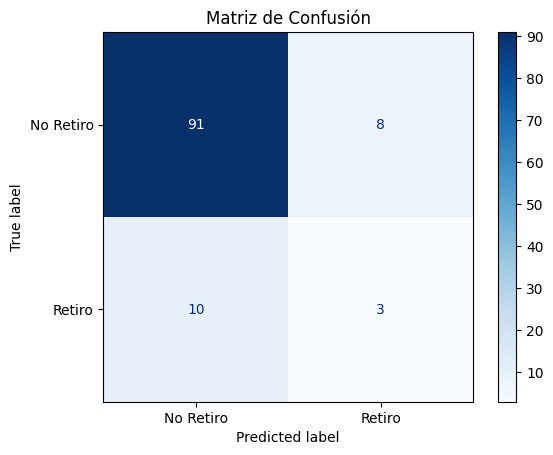

[Resultados Funcion : INFO]  El ratio de negativos / positivos es 6.9714285714285715 
[Resultados Funcion : INFO]  
[Resumen] Métricas de evaluación del modelo en test:

{'0': {'f1-score': 0.91,
       'precision': 0.900990099009901,
       'recall': 0.9191919191919192,
       'support': 99.0},
 '1': {'f1-score': 0.25,
       'precision': 0.2727272727272727,
       'recall': 0.23076923076923078,
       'support': 13.0},
 'accuracy': 0.8392857142857143,
 'macro avg': {'f1-score': 0.5800000000000001,
               'precision': 0.5868586858685869,
               'recall': 0.574980574980575,
               'support': 112.0},
 'weighted avg': {'f1-score': 0.8333928571428572,
                  'precision': 0.828066735244953,
                  'recall': 0.8392857142857143,
                  'support': 112.0}}
[Resultados Funcion : INFO]  AUC: 0.7707847707847708
[Resultados Funcion : INFO]             Metricas_Generales
Accuracy             0.839286
Precision            0.586859
Recall       

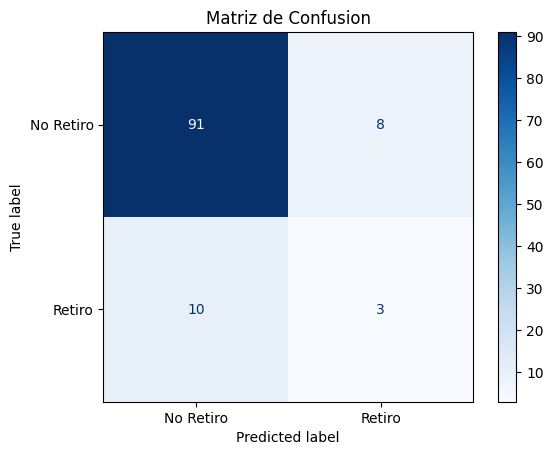

[Resultados Funcion : INFO]  El ratio de negativos / positivos es 6.9714285714285715 
[Resultados Funcion : INFO]  
[RF] Metricas de evaluacion del modelo en test:

{'0': {'f1-score': 0.91,
       'precision': 0.900990099009901,
       'recall': 0.9191919191919192,
       'support': 99.0},
 '1': {'f1-score': 0.25,
       'precision': 0.2727272727272727,
       'recall': 0.23076923076923078,
       'support': 13.0},
 'accuracy': 0.8392857142857143,
 'macro avg': {'f1-score': 0.5800000000000001,
               'precision': 0.5868586858685869,
               'recall': 0.574980574980575,
               'support': 112.0},
 'weighted avg': {'f1-score': 0.8333928571428572,
                  'precision': 0.828066735244953,
                  'recall': 0.8392857142857143,
                  'support': 112.0}}
[Resultados Funcion : INFO]  AUC: 0.7758352758352758
[Resultados Funcion : INFO]             Metricas_Generales
Accuracy             0.839286
Precision            0.586859
Recall            

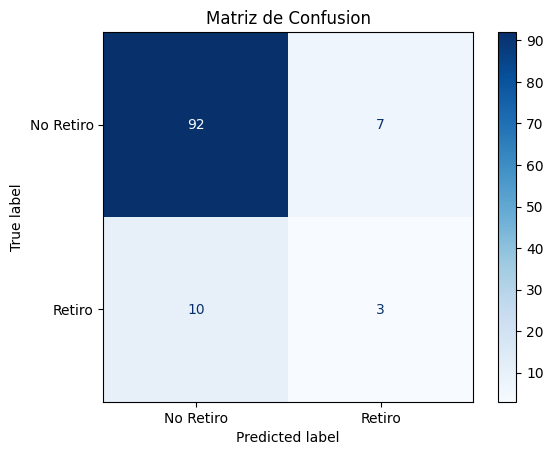

[Resultados Funcion : INFO]  El ratio de negativos / positivos es 6.9714285714285715 
[Resultados Funcion : INFO]  
[CAT] Metricas de evaluacion del modelo en test:

{'0': {'f1-score': 0.9154228855721394,
       'precision': 0.9019607843137255,
       'recall': 0.9292929292929293,
       'support': 99.0},
 '1': {'f1-score': 0.2608695652173913,
       'precision': 0.3,
       'recall': 0.23076923076923078,
       'support': 13.0},
 'accuracy': 0.8482142857142857,
 'macro avg': {'f1-score': 0.5881462253947654,
               'precision': 0.6009803921568627,
               'recall': 0.5800310800310801,
               'support': 112.0},
 'weighted avg': {'f1-score': 0.8394479466023919,
                  'precision': 0.8320903361344538,
                  'recall': 0.8482142857142857,
                  'support': 112.0}}
[Resultados Funcion : INFO]  AUC: 0.7762237762237763
[Resultados Funcion : INFO]             Metricas_Generales
Accuracy             0.848214
Precision            0.600980
R

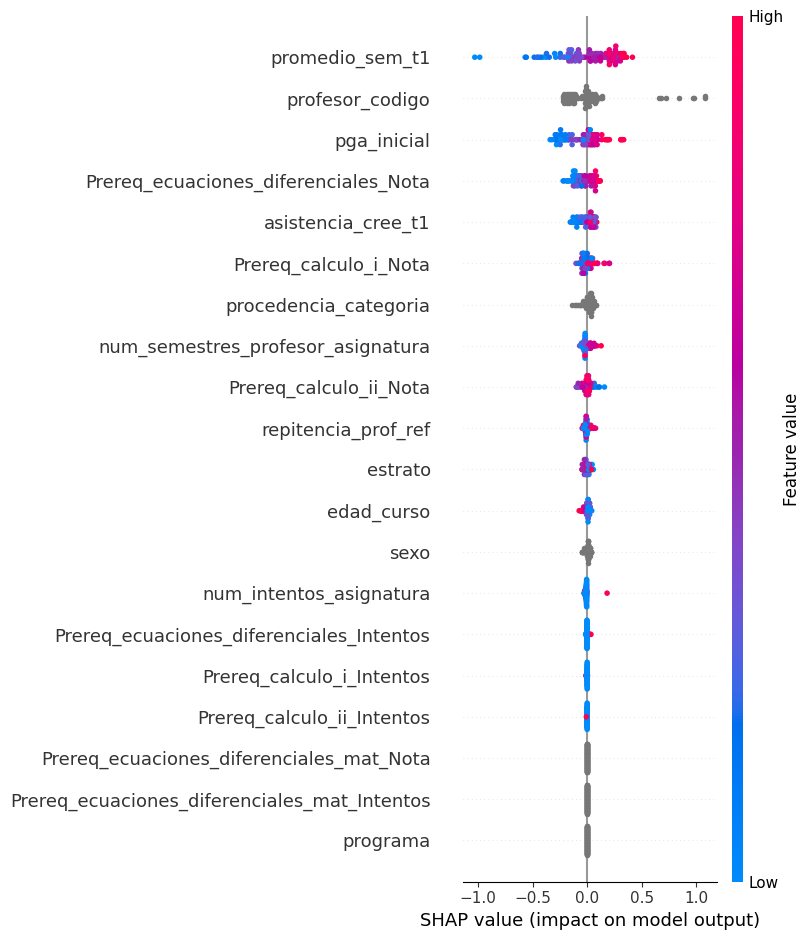

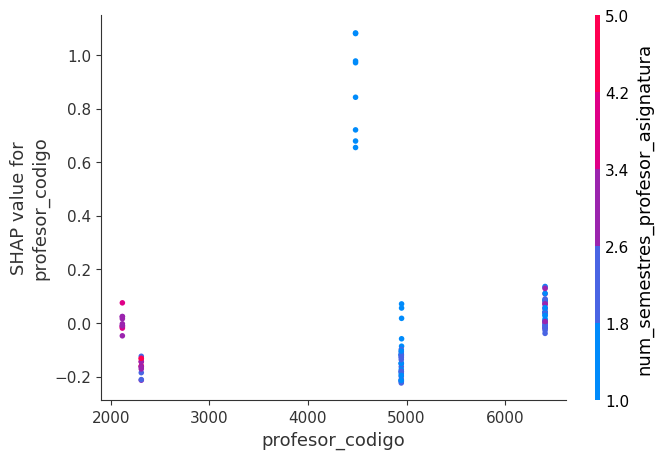

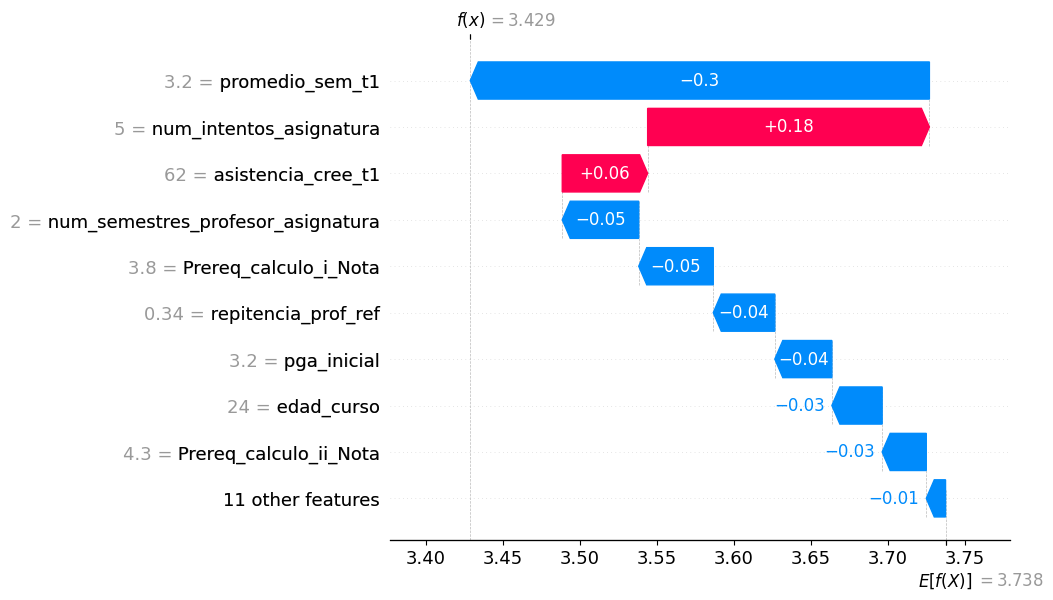

[Resultados Funcion : INFO]  
[Resumen] Métricas de evaluación del modelo en test:

[Resultados Funcion : INFO]         Valores
RMSE  0.432528
MAE   0.339698
R^2   0.590836
[Resultados Funcion : INFO]  
[Resumen] Validacion Cruzada Fast (promedio ± std):

[Resultados Funcion : INFO]                       mean       std
RMSE (CV)        0.475418  0.038602
MAE (CV)         0.371381  0.033620
R^2 (CV)         0.595197  0.045174
Recall±0.3 (CV)  0.503913  0.048136
[Resultados Funcion : INFO]  
[Resumen] Metricas sobre predicciones OOF:

[Resultados Funcion : INFO]  RMSE_OOF          0.476803
MAE_OOF           0.371239
R^2_OOF           0.597536
Recall±0.3_OOF    0.504098
dtype: float64
[Resultados Funcion : INFO]  Columna no encontrada: Tipo_colegio
[Resultados Funcion : INFO]  Columna no encontrada: Tipo_calendario
[Resultados Funcion : INFO]  Columna no encontrada: interpretacion_general_xgb
[Resultados Funcion : INFO]  Columna no encontrada: interpretacion_registro_xgb
[Resultados Funci

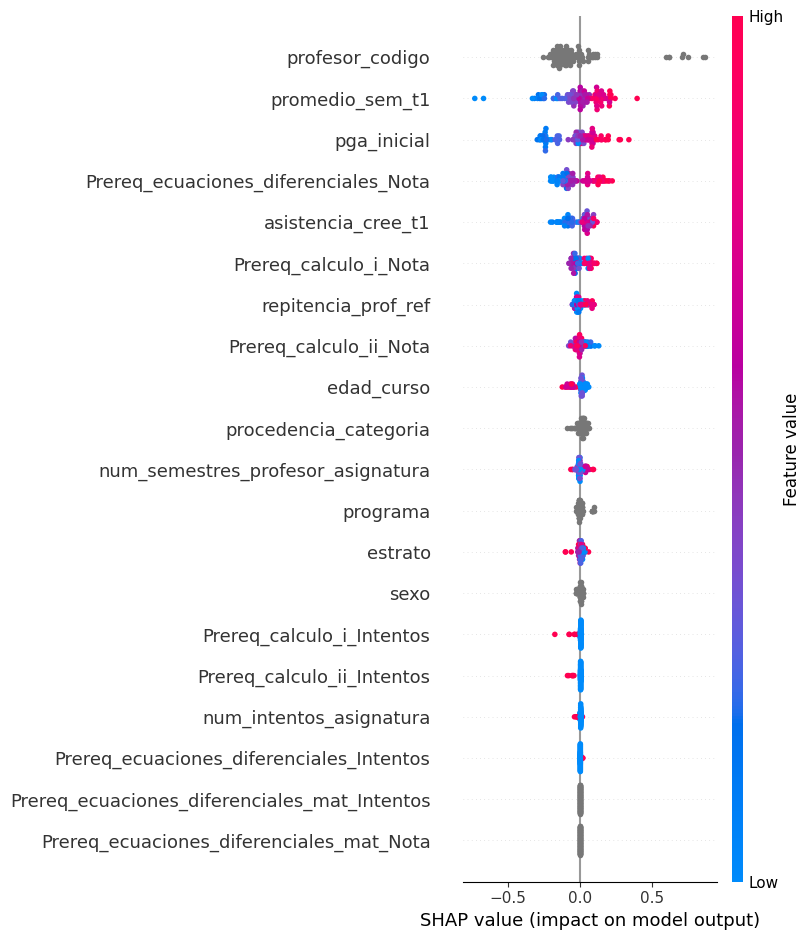

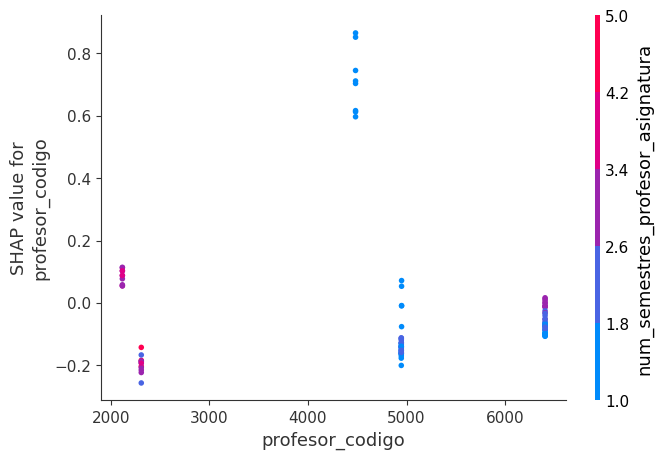

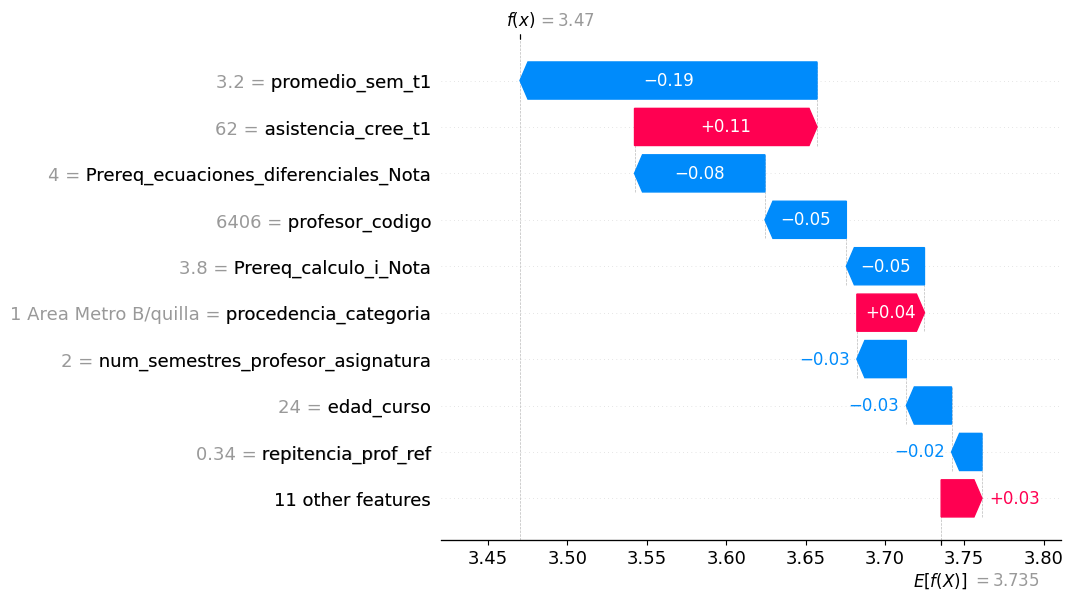

[Resultados Funcion : INFO]  [CAT] Metricas de evaluacion del modelo en test:
[Resultados Funcion : INFO]         Valores
RMSE  0.421982
MAE   0.330990
R^2   0.610546
[Resultados Funcion : INFO]   Validacin Cruzada CatBoost (promedio  std):
[Resultados Funcion : INFO]                 mean       std
RMSE (CV)  0.464799  0.035364
MAE (CV)   0.364192  0.024782
R^2 (CV)   0.612580  0.044129
[Resultados Funcion : INFO]  Columna no encontrada: Tipo_colegio
[Resultados Funcion : INFO]  Columna no encontrada: Tipo_calendario
[Resultados Funcion : INFO]  Columna no encontrada: interpretacion_general_cat
[Resultados Funcion : INFO]  Columna no encontrada: interpretacion_registro_cat
[Resultados Funcion : INFO]  programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
dtype: object
[Resultados Funcion : INFO]  [Aviso] Insertando interpretaciones SHAP (CAT) en el dataframe de predicciones:
[Resultados Funcion : INFO]  [

In [25]:
# Ejecucion rutina 1: correr_modelos_multi_por_asignatura
variant_generar = 'main'



df_resultados_final_multi, df_resultados_stats_multi, df_resultados_class_retiro_stats_multi = (
    correr_modelos_multi_por_asignatura(df_usar, df_historial_asignaturas_nombres, variant_generar)
)

print("[Resultados Funcion : correr_modelos_multi_por_asignatura] Ejecucion finalizada")


### Preparacion antes de Rutina 2 (Modelos guardados XG+CAT)


In [26]:
# CARGAR ARCHIVO PARA RUTINA 2
print("[Resultados Funcion : CARGA_INICIAL] Reivsar asignaturas. Carga Archivo Maestro.")

#Flag para usar parquet o csv. El parquet fue creado del CSV original importando desde el otro metodo que genera el documento.
parquet_use= True

# Solicitar archivo de historial
while True:
    try:
        if parquet_use:
            ruta_historial = hitorial_parqet
            df_historial = pd.read_parquet(ruta_historial)
        else:
            ruta_historial = historial
            df_historial = pd.read_csv(ruta_historial, sep=';')
        print(f"[Resultados Funcion : CARGA_INICIAL] Archivo de historial cargado: {len(df_historial)} registros") 
        break
    except Exception as e:
        print(f"[Resultados Funcion : CARGA_INICIAL] Error al cargar historial: {e}")
        print("[Resultados Funcion : CARGA_INICIAL] Intente nuevamente.")


# Limpieza inicial de datos
df_historial, resumen_limpieza_inicial = limpiar_datos_iniciales(df_historial)
df_historial_asignaturas_nombres = crear_df_asignaturas(df_historial)

print(f"[Limpieza Inicial] Registros luego de limpieza: {len(df_historial)}")


[Resultados Funcion : CARGA_INICIAL] Reivsar asignaturas. Carga Archivo Maestro.
[Resultados Funcion : CARGA_INICIAL] Archivo de historial cargado: 689792 registros
[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Division ajustado: 383
[Resultados Funcion : INFO]  [Limpieza Inicial] Registros eliminados por Descripcion_Materia: 89672
[Resultados Funcion : INFO]  [Limpieza Inicial] Registros eliminados por DPTO Asignatura: 52414
[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Programa unificado Lenguas: 17438
[Resultados Funcion : INFO]  [Limpieza Inicial] Nombre_Programa ajustado Licenciatura: 1632
[Resultados Funcion : INFO]  [Limpieza Inicial] Sexo homologado a -99: 344
[Resultados Funcion : INFO]  [Limpieza Inicial] Tipo_Colegio ajustado: 66051
[Resultados Funcion : INFO]  [Limpieza Inicial] Tipo_Calendario ajustado: 67061
[Resultados Funcion : INFO]  [Limpieza Inicial] Asistencia CREE t_1 nulos rellenados con 0: 90773
[Resultados Funcion : INFO]  [Limpieza Inicial] Ul

In [27]:
#Limpiar y cargar DataFrame para correr modelos por asignatura usando modelos guardados
## Preparar datos para usar guardados modelos por asignatura



periodo_a_evaluar=202530
ruta_modelos_guardados = get_model_dir('xgboost', 'main', 'prediccion_nota')
asignaturas_mod_guardados=check_asignaturas_en_carpeta(ruta_modelos_guardados)

cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#["FIS1023","MAT1111","FIS1033"]  Prueba donde tenia errores antes -> # ['FRA1010','MAT1121','IST4360','PSI1160']  # ['CMN7190'] 
asig_a_usar= asignaturas_mod_guardados#["FIS1023"]#,"MAT1111","FIS1033"]#["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]
#asig_a_usar = ["FIS1023","MAT1111","FIS1033"]  #asignaturas_mod_guardados[:10]
#asig_a_usar=["ECO2011"]

df_usar = df_historial[
    ((df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (df_historial["Observacion_Prerrequisito"] == "No tiene pre requisito")
      ) &
    (df_historial["Cod materia curso"].isin(asig_a_usar) )
].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar, True, eliminar_filas_durante_limpieza=False)

if "Periodo" in df_usar.columns:
    df_usar = df_usar[df_usar["Periodo"]==periodo_a_evaluar]
else:
    print("[Resultados Funcion : INFO] ", "[Aviso] La columna 'Periodo' no existe despues de limpiar_dataframe; se omite el filtro por periodo.")

col_dpto_src = "_ Matricula detalle para analisis.DPTO Asignatura"
if col_dpto_src in df_usar.columns:
    df_usar["DPTO Asignatura"]=df_usar[col_dpto_src]


[Resultados Funcion : INFO]  [Info] Asignaturas detectadas en la carpeta de modelos: C:\Users\Rubiel\OneDrive - Universidad del Norte\Maestria\Proyecto de grado\Prereq\Resultados v6\Multiples Asignaturas\modelos_guardados_v2_1\xgboost\main\prediccion_nota


,asignatura
0,IME4070


[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: Nombre_Programa
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Prof_Codigo
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Sexo
[Resultados Funcion : INFO]  [Comas→Puntos] Columna excluida: _ Matricula detalle para analisis.Procedencia Categoria
[Resultados Funcion : INFO]  === Iniciando limpieza del DataFrame ===
[Resultados Funcion : INFO]  [Imputación] Columna '_ Matricula detalle para analisis.repitencia profesor referencia': 249 vacíos reemplazados por 0.0
[Resultados Funcion : INFO]  [Imputación] Columna '_ Matricula detalle para analisis.repitencia profesor referencia 1ano': 250 vacíos reemplazados por 0.0
[Resultados Funcion : INFO]  [Imputación] Columna '_ Matricula detalle para analisis.Procedencia Categoria': 1 valores '6 No registra' reemplazados por NaN
[Resultados Funcion : INFO]  [Imputación] Columna '_ Matricula d

### Rutina 2: usar_modelos_guardados_xg_cat_por_asignatura


In [28]:
# Ejecucion rutina 2: usar_modelos_guardados_xg_cat_por_asignatura

df_resultados_final_xg_cat, df_errores_xg_cat, df_pred_cat = usar_modelos_guardados_xg_cat_por_asignatura(df_usar, df_historial_asignaturas_nombres)

print("[Resultados Funcion : usar_modelos_guardados_xg_cat_por_asignatura] Ejecucion finalizada")


[Resultados Funcion : INFO]  
----------------------------------------------------------------------
[Resultados Funcion : INFO]  INICIANDO PROCESO POR ASIGNATURA
[Resultados Funcion : INFO]  ----------------------------------------------------------------------
[Resultados Funcion : INFO]  
 == Resultados para programa:  IME4070 - MECANICA DE FLUIDOS == 

[Resultados Funcion : INFO]  -------------- Preparando columnas / prerequisitos --------------
[Resultados Funcion : INFO]  [Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Resultados Funcion : INFO]  [Incluido] Prereq_2_Nota y Prereq_2_Intentos → 95.45% válidos → nuevas columnas creadas.
[Resultados Funcion : INFO]  [Incluido] Prereq_3_Nota y Prereq_3_Intentos → 90.91% válidos → nuevas columnas creadas.
[Resultados Funcion : INFO]  
Resumen final:
[Resultados Funcion : INFO]  Columnas nuevas seleccionadas: ['Prereq_ecuaciones_diferenciales_Intentos', 'Prereq_ecuaciones_diferenciales_Nota', '